# Swing & Signal

Racket-sports time series + ECG: EDA, classical ML, and PyTorch (course lab).

In [2]:
# download libraries
!python3 -m pip install --upgrade pip
%pip install numpy
%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install sklearn
%pip install sktime
%pip install scipy
%pip install xgboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an

In [3]:
# import libraries
import json
import numpy as np
import pandas as pd
from sktime.datasets import load_from_arff_to_dataframe
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectPercentile, VarianceThreshold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

/usr/local/lib/python3.10/dist-packages/sktime/__init__.py:45: PackageDeprecationWarning: 
The sktime PyPI package is deprecated.
The sktime project split into two projects.

To find out how to install the new packages, please go to:

* https://github.com/aeon-toolkit/aeon
* https://github.com/sktime/sktime

Here is what you can do when installing sktime via pip (e.g. using `pip install ...` or a requirement file like `requirements.txt`, `setup.py`, `setup.cfg`):

* continue using the package without receiving any updates (ignoring the deprecation warning or avoiding it by pinning the version: `sktime==0.18.0`),
* replace sktime with one of the new projects,
* if the sktime package is used by one of your dependencies, it would be great if you take some time to track which package uses sktime and report to their issue tracker that sktime is deprecated.

More information is available at:
https://github.com/mloning/sktime-deprecation/discussions/2

If the previous advice does not support 

In [4]:
# read datasets

# sports
X_sports_train, y_sports_train = load_from_arff_to_dataframe("RacketSports/RacketSports_TRAIN.arff")
X_sports_train.columns = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

X_sports_test, y_sports_test = load_from_arff_to_dataframe("RacketSports/RacketSports_TEST.arff")
X_sports_test.columns = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]


# mitbih
df_mitbih_train = pd.read_csv("ECG/mitbih_train.csv")
df_mitbih_test = pd.read_csv("ECG/mitbih_test.csv")
df_mitbih_test.columns = df_mitbih_train.columns
df_mitbih = pd.concat([df_mitbih_train, df_mitbih_test])

X_mitbih_train = df_mitbih_train.iloc[:, :-1]
y_mitbih_train = df_mitbih_train.iloc[:, -1]

X_mitbih_test = df_mitbih_test.iloc[:, :-1]
y_mitbih_test = df_mitbih_test.iloc[:, -1]


# ptbdb
df_ptb_normal = pd.read_csv("ECG/ptbdb_normal.csv")
df_ptb_abnormal = pd.read_csv("ECG/ptbdb_abnormal.csv")
df_ptb_abnormal.columns = df_ptb_normal.columns
df_ptb = pd.concat([df_ptb_normal, df_ptb_abnormal])

X_ptb = df_ptb.iloc[:, :-1]
y_ptb = df_ptb.iloc[:, -1]
X_ptb_train, X_ptb_test, y_ptb_train, y_ptb_test = train_test_split(X_ptb, y_ptb, test_size=0.3, random_state=42)

## 3.1 Exploratory Data Analysis

### 1. label plots

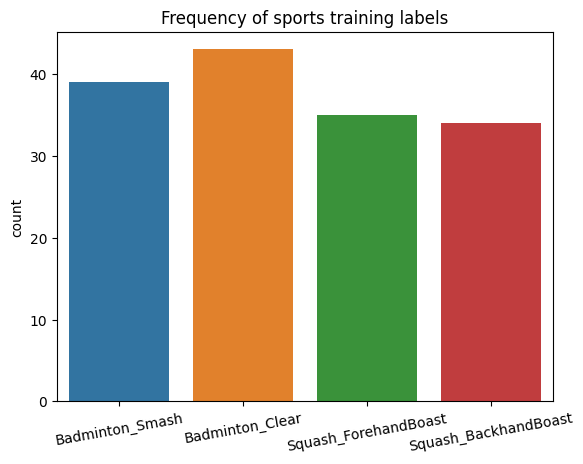

---------------------------------------------------------------------


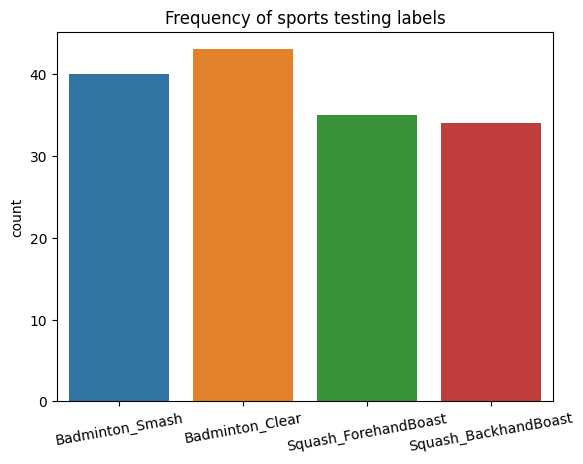

---------------------------------------------------------------------


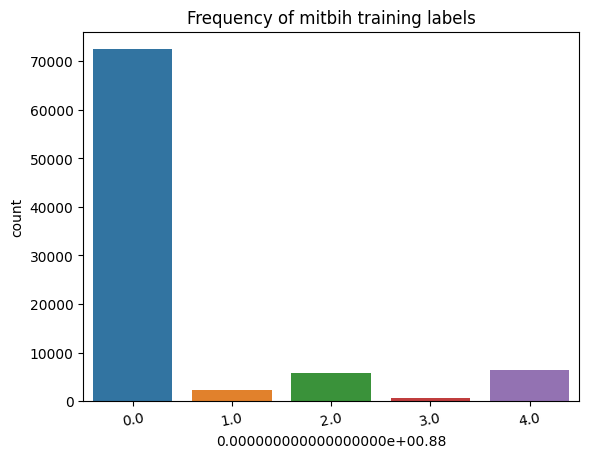

---------------------------------------------------------------------


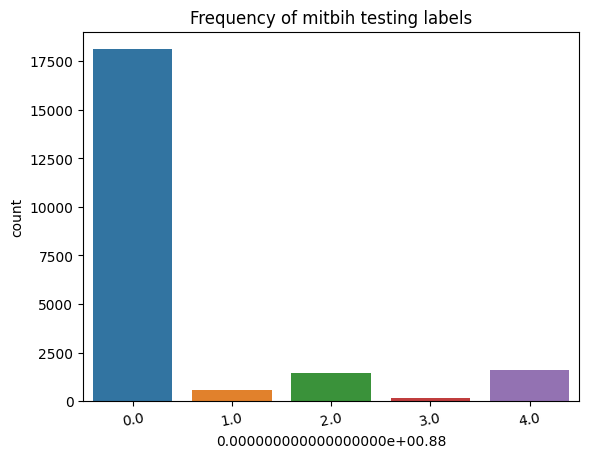

---------------------------------------------------------------------


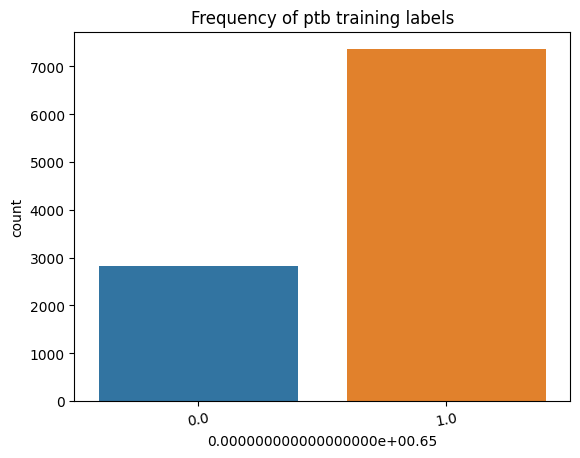

---------------------------------------------------------------------


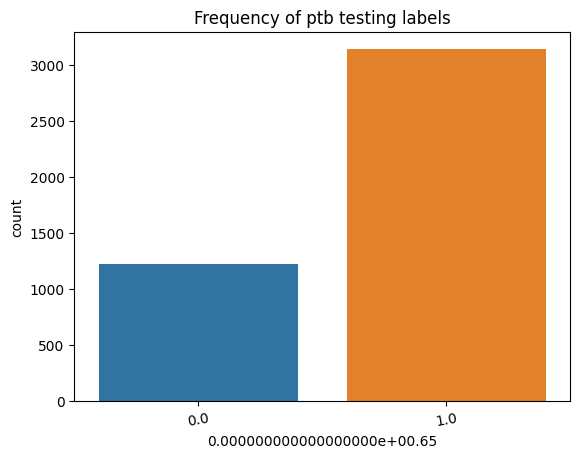

---------------------------------------------------------------------


In [ ]:
# sports train
sns.countplot(x=y_sports_train)
plt.xticks(rotation=10)
plt.title('Frequency of sports training labels')
plt.show()
print("---------------------------------------------------------------------")

# sports test
sns.countplot(x=y_sports_test)
plt.xticks(rotation=10)
plt.title('Frequency of sports testing labels')
plt.show()
print("---------------------------------------------------------------------")

# mitbih train
sns.countplot(x=y_mitbih_train)
plt.xticks(rotation=10)
plt.title('Frequency of mitbih training labels')
plt.show()
print("---------------------------------------------------------------------")

# mitbih test
sns.countplot(x=y_mitbih_test)
plt.xticks(rotation=10)
plt.title('Frequency of mitbih testing labels')
plt.show()
print("---------------------------------------------------------------------")

# ptb train
sns.countplot(x=y_ptb_train)
plt.xticks(rotation=10)
plt.title('Frequency of ptb training labels')
plt.show()
print("---------------------------------------------------------------------")

# ptb test
sns.countplot(x=y_ptb_test)
plt.xticks(rotation=10)
plt.title('Frequency of ptb testing labels')
plt.show()
print("---------------------------------------------------------------------")


### 2. time series

#### 1) sports - example of time series for each label 

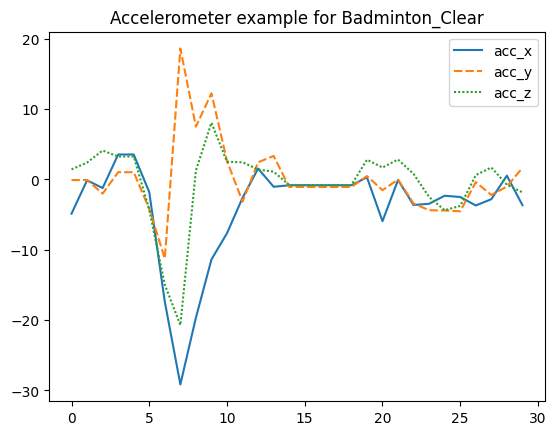

------------------------------------------------------------------


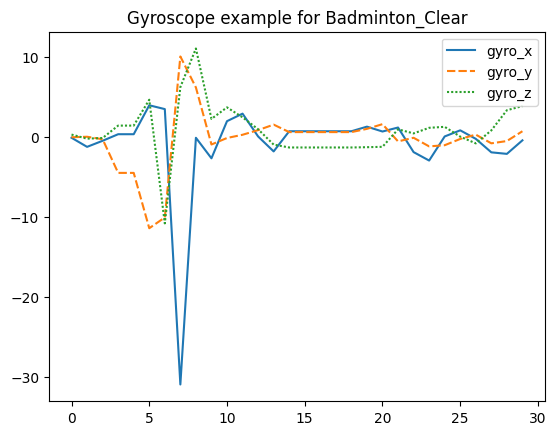

------------------------------------------------------------------


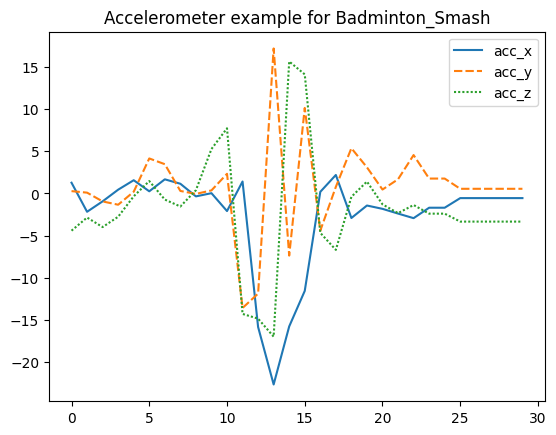

------------------------------------------------------------------


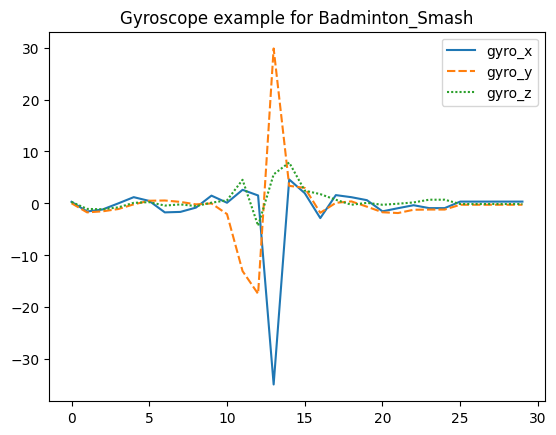

------------------------------------------------------------------


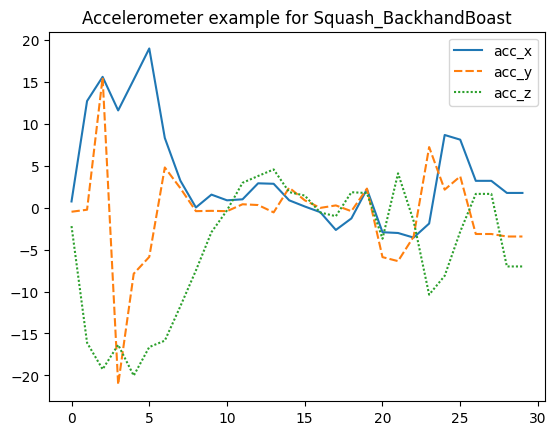

------------------------------------------------------------------


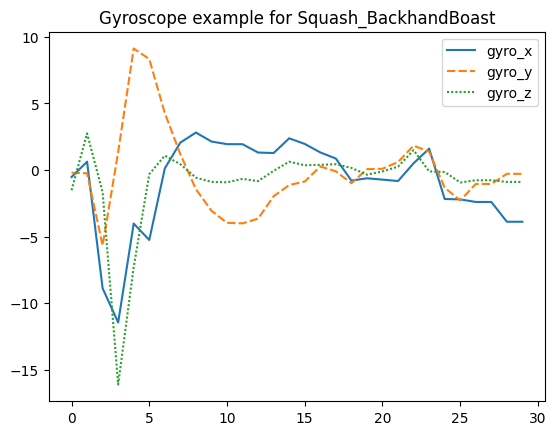

------------------------------------------------------------------


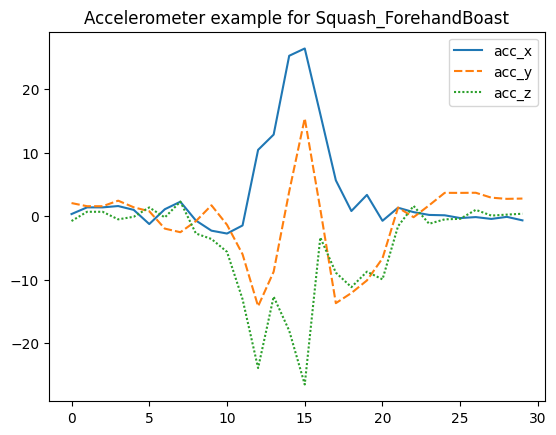

------------------------------------------------------------------


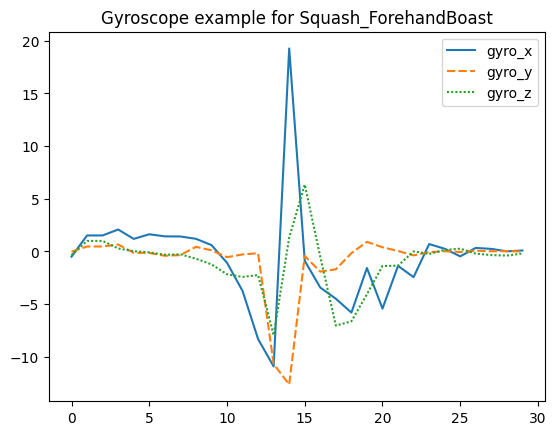

------------------------------------------------------------------


In [ ]:
sports_labels = np.unique(y_sports_train)
for label in sports_labels:
    index = np.where(y_sports_train == label)[0][0]

    acc_x = X_sports_train['acc_x'][index]
    acc_y = X_sports_train['acc_y'][index]
    acc_z = X_sports_train['acc_z'][index]
    df_acc = pd.DataFrame({'acc_x': acc_x, 'acc_y': acc_y, 'acc_z': acc_z})

    sns.lineplot(data=df_acc)
    plt.title(f'Accelerometer example for {label}')
    plt.show()
    print("------------------------------------------------------------------")

    gyro_x = X_sports_train['gyro_x'][index]
    gyro_y = X_sports_train['gyro_y'][index]
    gyro_z = X_sports_train['gyro_z'][index]
    df_gyro = pd.DataFrame({'gyro_x': gyro_x, 'gyro_y': gyro_y, 'gyro_z': gyro_z})

    sns.lineplot(data=df_gyro)
    plt.title(f'Gyroscope example for {label}')
    plt.show()
    print("------------------------------------------------------------------")

#### 2) mitbih & ptb - example of time series for each label

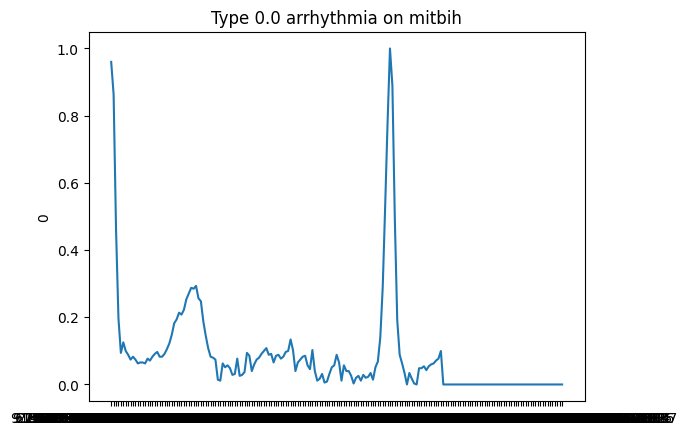

----------------------------------------------------------------------------------


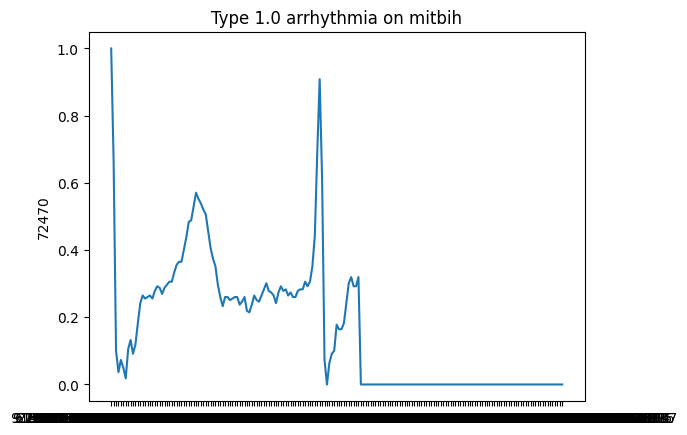

----------------------------------------------------------------------------------


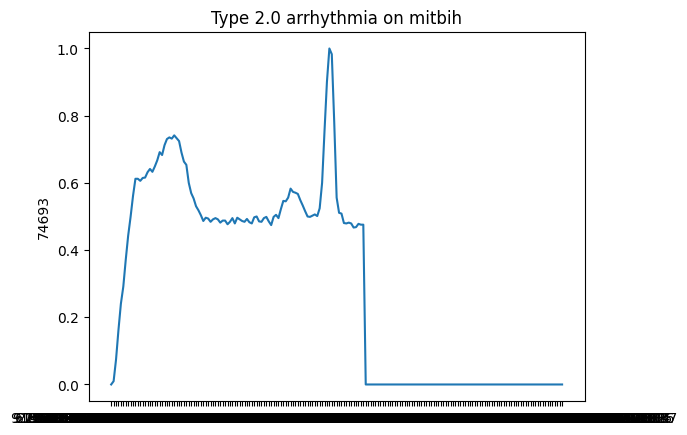

----------------------------------------------------------------------------------


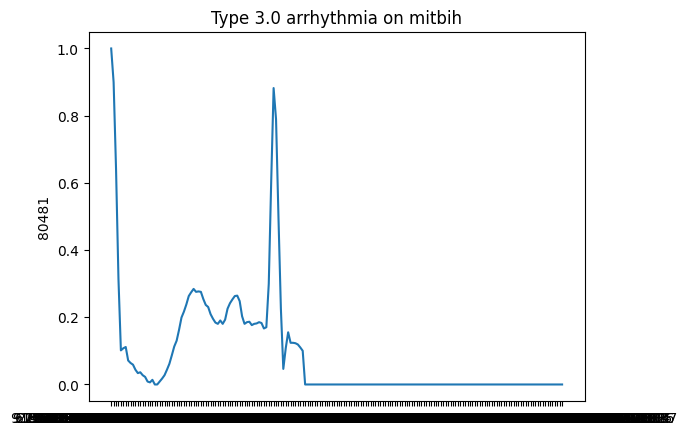

----------------------------------------------------------------------------------


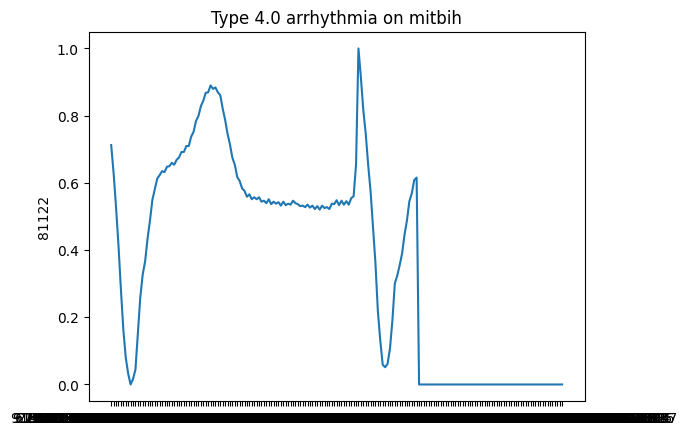

----------------------------------------------------------------------------------


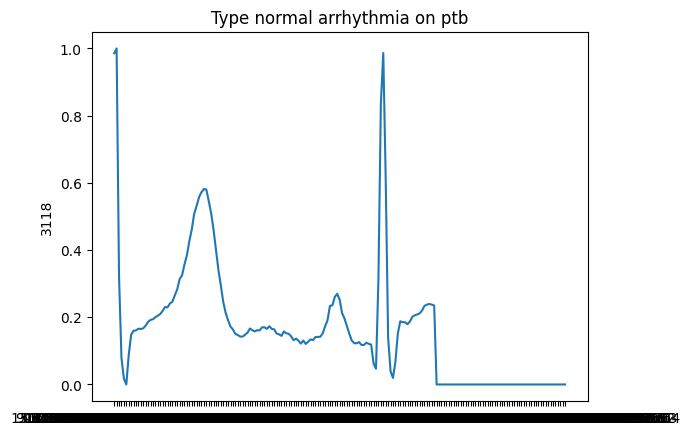

----------------------------------------------------------------------------------


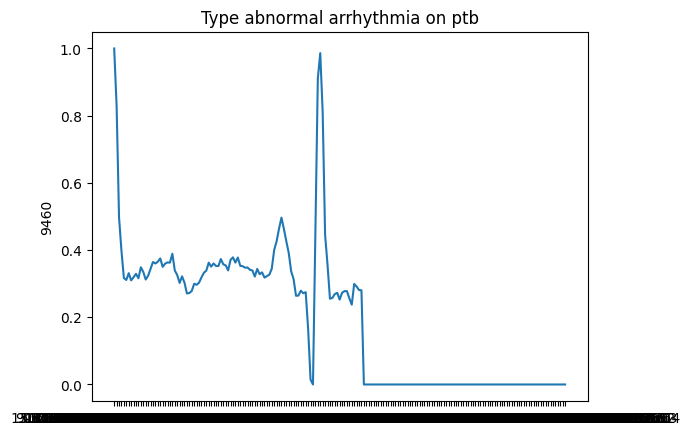

----------------------------------------------------------------------------------


In [ ]:
# mitbih
mitbih_labels = np.unique(y_mitbih_train)
for label in mitbih_labels:
    index = np.where(y_mitbih_train == label)[0][0]
    sns.lineplot(data=X_mitbih_train.iloc[index].T)
    plt.title(f'Type {label} arrhythmia on mitbih')
    plt.show()
    print("----------------------------------------------------------------------------------")

# ptb
ptb_labels = np.unique(y_ptb_train)
for label in ptb_labels:
    index = np.where(y_ptb_train == label)[0][0]
    sns.lineplot(data=X_ptb_train.iloc[index].T)
    plt.title(f'Type {"normal" if label == 0.0 else "abnormal"} arrhythmia on ptb')
    plt.show()
    print("----------------------------------------------------------------------------------")

#### 3) mean and std per each type of arrhythmia

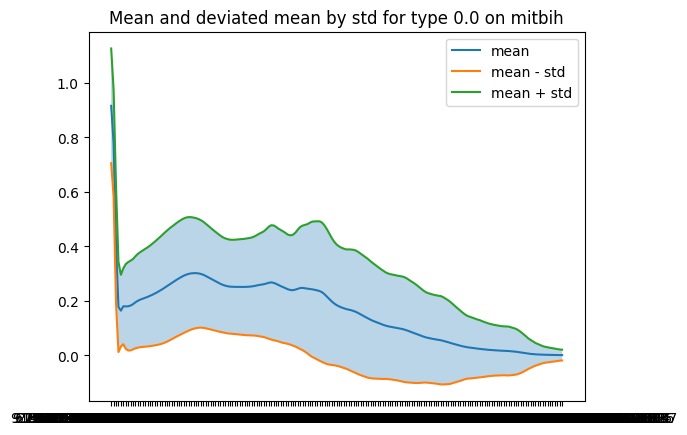

----------------------------------------------------------------------------------


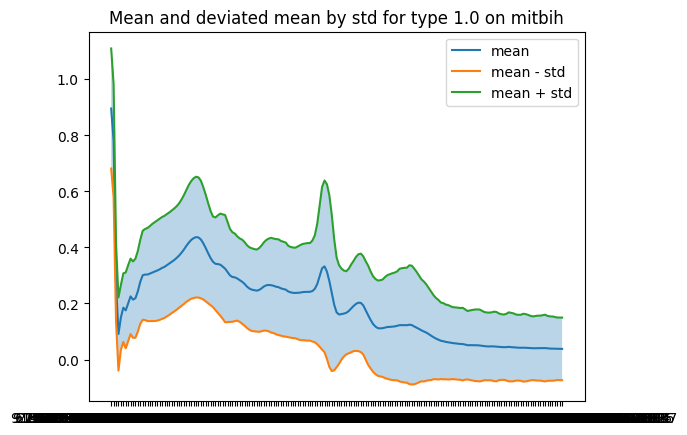

----------------------------------------------------------------------------------


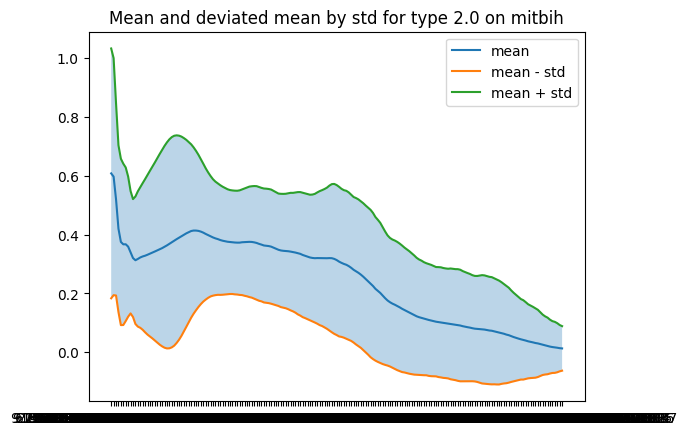

----------------------------------------------------------------------------------


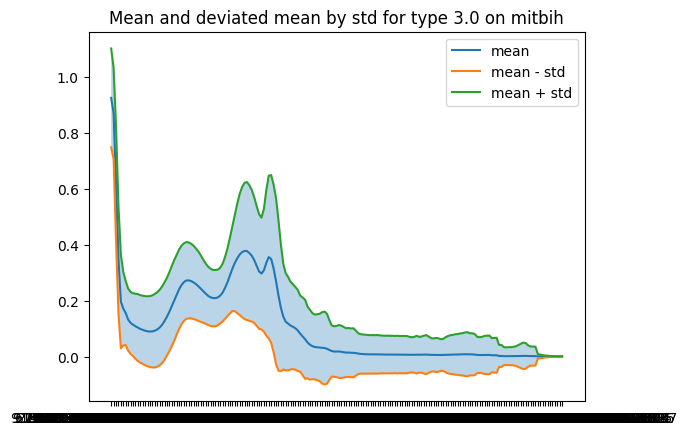

----------------------------------------------------------------------------------


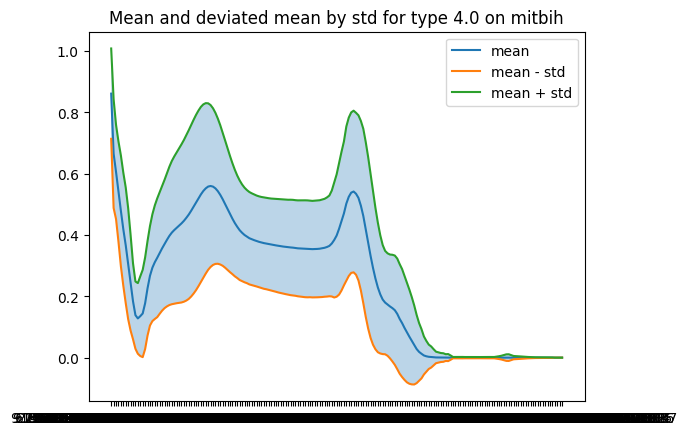

----------------------------------------------------------------------------------


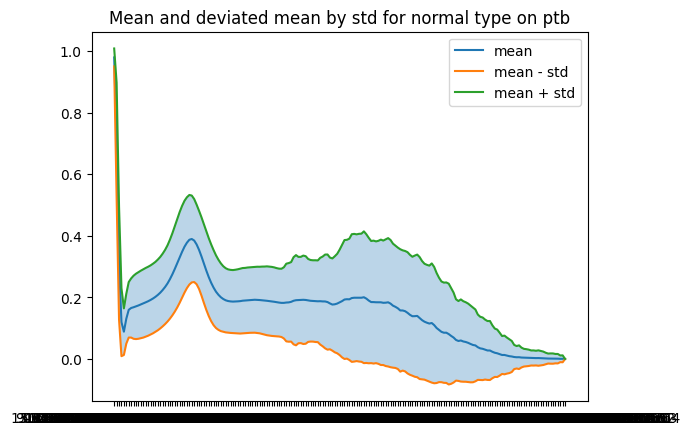

----------------------------------------------------------------------------------


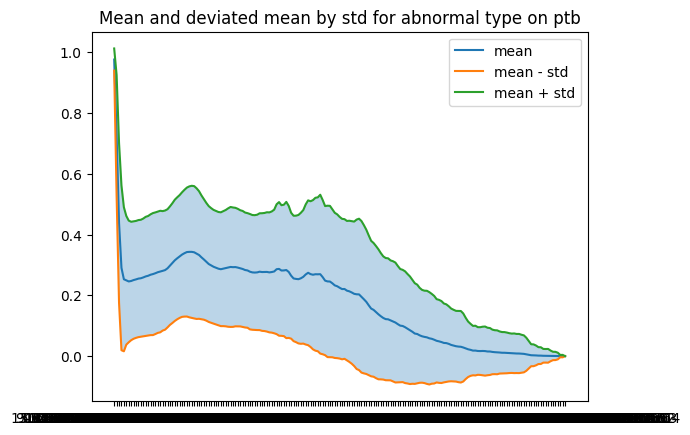

----------------------------------------------------------------------------------


In [ ]:
# mitbih
for label in mitbih_labels:
    X_mitbih_with_label = df_mitbih[df_mitbih.iloc[:, -1] == label].iloc[:, :-1]
    X_mitbih_with_label_mean = X_mitbih_with_label.mean()
    X_mitbih_with_label_std = X_mitbih_with_label.std()
    sns.lineplot(data=X_mitbih_with_label_mean, label="mean")
    sns.lineplot(data=X_mitbih_with_label_mean - X_mitbih_with_label_std, label="mean - std")
    sns.lineplot(data=X_mitbih_with_label_mean + X_mitbih_with_label_std, label="mean + std")
    plt.fill_between(X_mitbih_with_label_mean.index, X_mitbih_with_label_mean - X_mitbih_with_label_std, X_mitbih_with_label_mean + X_mitbih_with_label_std, alpha=0.3)
    plt.title(f'Mean and deviated mean by std for type {label} on mitbih')
    plt.show()
    print("----------------------------------------------------------------------------------")

# ptb
X_ptb_normal = df_ptb_normal.iloc[:, :-1]
X_ptb_normal_mean = X_ptb_normal.mean()
X_ptb_normal_std = X_ptb_normal.std()
sns.lineplot(data=X_ptb_normal_mean, label="mean")
sns.lineplot(data=X_ptb_normal_mean - X_ptb_normal_std, label="mean - std")
sns.lineplot(data=X_ptb_normal_mean + X_ptb_normal_std, label="mean + std")
plt.fill_between(X_ptb_normal_mean.index, X_ptb_normal_mean - X_ptb_normal_std, X_ptb_normal_mean + X_ptb_normal_std, alpha=0.3)
plt.title('Mean and deviated mean by std for normal type on ptb')
plt.show()
print("----------------------------------------------------------------------------------")

X_ptb_abnormal = df_ptb_abnormal.iloc[:, :-1]
X_ptb_abnormal_mean = X_ptb_abnormal.mean()
X_ptb_abnormal_std = X_ptb_abnormal.std()
sns.lineplot(data=X_ptb_abnormal_mean, label="mean")
sns.lineplot(data=X_ptb_abnormal_mean - X_ptb_abnormal_std, label="mean - std")
sns.lineplot(data=X_ptb_abnormal_mean + X_ptb_abnormal_std, label="mean + std")
plt.fill_between(X_ptb_abnormal_mean.index, X_ptb_abnormal_mean - X_ptb_abnormal_std, X_ptb_abnormal_mean + X_ptb_abnormal_std, alpha=0.3)
plt.title('Mean and deviated mean by std for abnormal type on ptb')
plt.show()
print("----------------------------------------------------------------------------------")

#### 4) distribution values per each type of gesture on each axes

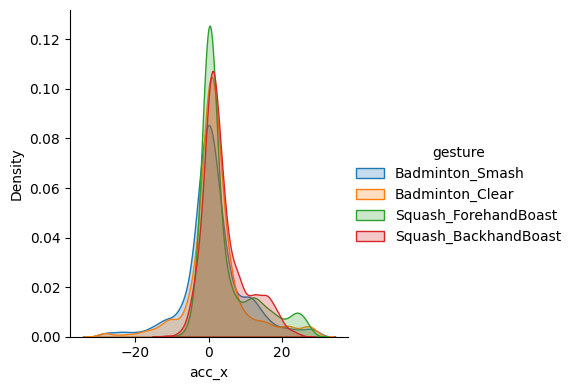

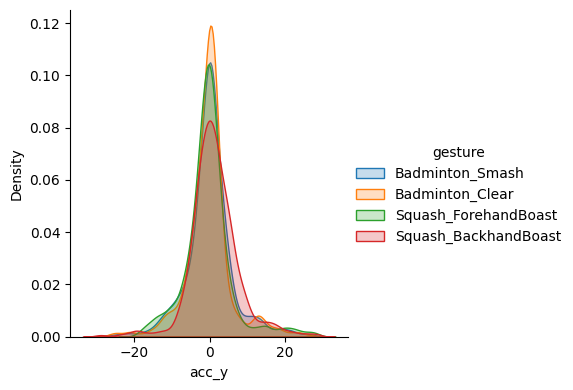

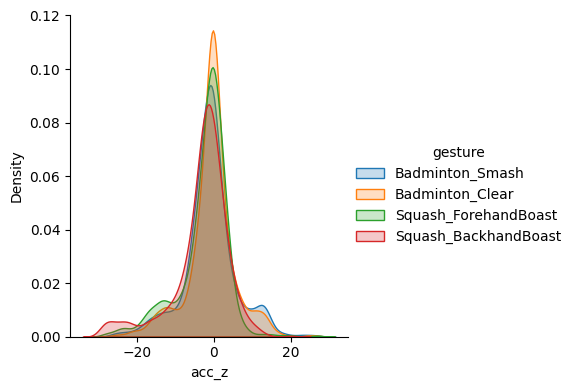

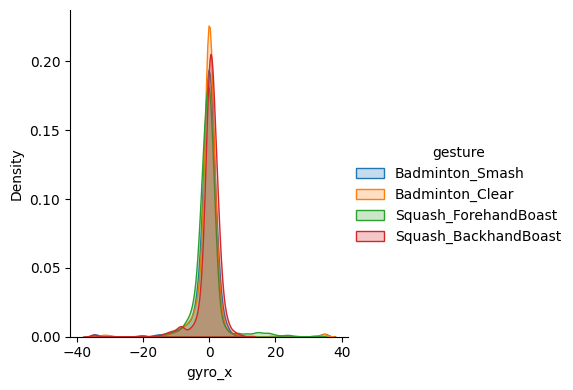

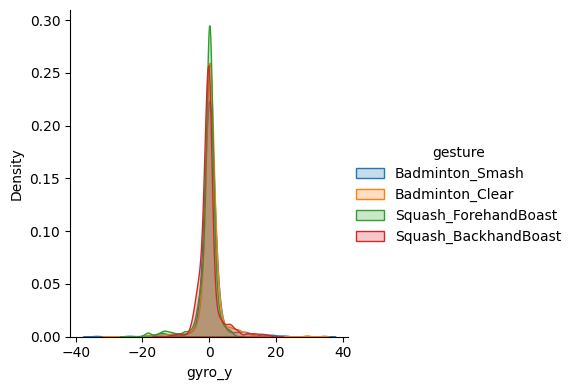

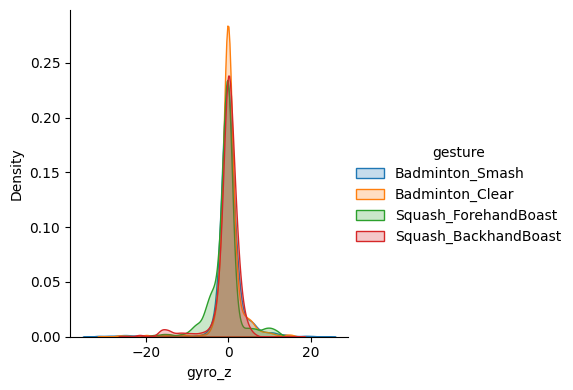

In [ ]:
X_sports = pd.concat([X_sports_train, X_sports_test])
y_sports = np.concatenate([y_sports_train, y_sports_test])
df_sports = pd.concat([pd.DataFrame(X_sports).reset_index(drop=True), pd.DataFrame(y_sports, columns=['gesture'])], axis=1)

df_sports_flatten = pd.DataFrame(columns=['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'gesture'])

for index, row in df_sports.iterrows():
    df_sports_flatten = pd.concat([df_sports_flatten, pd.DataFrame({
        'acc_x': row['acc_x'],
        'acc_y': row['acc_y'],
        'acc_z': row['acc_z'],
        'gyro_x': row['gyro_x'],
        'gyro_y': row['gyro_y'],
        'gyro_z': row['gyro_z'],
        'gesture': row['gesture']
    })])

sns.FacetGrid(df_sports_flatten, hue="gesture", height=4).map(sns.kdeplot, "acc_x", fill=True).add_legend()
sns.FacetGrid(df_sports_flatten, hue="gesture", height=4).map(sns.kdeplot, "acc_y", fill=True).add_legend()
sns.FacetGrid(df_sports_flatten, hue="gesture", height=4).map(sns.kdeplot, "acc_z", fill=True).add_legend()
sns.FacetGrid(df_sports_flatten, hue="gesture", height=4).map(sns.kdeplot, "gyro_x", fill=True).add_legend()
sns.FacetGrid(df_sports_flatten, hue="gesture", height=4).map(sns.kdeplot, "gyro_y", fill=True).add_legend()
sns.FacetGrid(df_sports_flatten, hue="gesture", height=4).map(sns.kdeplot, "gyro_z", fill=True).add_legend()


## 3.2 Attribute extraction and classic ML algorithms


### Generic grid search for Random Forest, Gradient Boosting, Support Vector Machine

In [ ]:
# Compute score function for each metric
def compute_scorings(labels, use_only_accuracy=True):
    accuracy_scoring = make_scorer(accuracy_score)

    precision_scoring = {}
    for label in labels:
        precision_scoring[f'{label}'] = make_scorer(precision_score, average=None, labels=[label], zero_division=1)
    precision_scoring['mean'] = make_scorer(precision_score, average='macro', zero_division=1)

    recall_scoring = {}
    for label in labels:
        recall_scoring[f'{label}'] = make_scorer(recall_score, average=None, labels=[label], zero_division=1)
    recall_scoring['mean'] = make_scorer(recall_score, average='macro', zero_division=1)

    f1_scoring = {}
    for label in labels:
        f1_scoring[f'{label}'] = make_scorer(f1_score, average=None, labels=[label], zero_division=1)
    f1_scoring['mean'] = make_scorer(f1_score, average='macro', zero_division=1)

    if use_only_accuracy:
        scorings = {
            'accuracy': accuracy_scoring
        }
    else:
        scorings = {
            'accuracy': accuracy_scoring,
            'precision': precision_scoring,
            'recall': recall_scoring,
            'f1': f1_scoring
        }

    return scorings

In [ ]:
def perform_grid_search(model, parameters, X_train, y_train, X_test, y_test, labels, scorings):
    reports_dfs = {}

    # Perform grid search with cross-validation for each scoring metric
    for metric, scoring in scorings.items():
        refit = True if metric == 'accuracy' else 'mean'

        # Define the grid search
        grid_search = GridSearchCV(model, parameters, cv=3, scoring=scoring, refit=refit)

        # Fit the grid search
        grid_search.fit(X_train, y_train)

        # Save report for each metric
        cv_results = grid_search.cv_results_
        report_list = []

        if metric == 'accuracy':
            for mean_score, std_score, params in zip(cv_results['mean_test_score'], cv_results['std_test_score'], cv_results['params']):
                row = {
                    'hyperparams': json.dumps(params),
                    f'{metric}': f"{mean_score:.3f} +/- {std_score:.3f}"
                }
                report_list.append(row)
        else:
            for mean_score_0, std_score_0, mean_score_1, std_score_1, mean_score_2, std_score_2, mean_score_3, std_score_3, params in zip(cv_results[f'mean_test_{labels[0]}'], cv_results[f'std_test_{labels[0]}'], cv_results[f'mean_test_{labels[1]}'], cv_results[f'std_test_{labels[1]}'], cv_results[f'mean_test_{labels[2]}'], cv_results[f'std_test_{labels[2]}'], cv_results[f'mean_test_{labels[3]}'], cv_results[f'std_test_{labels[3]}'], cv_results['params']):
                row = {
                    'hyperparams': json.dumps(params),
                    f'{metric}_{labels[0]}': f"{mean_score_0:.3f} +/- {std_score_0:.3f}",
                    f'{metric}_{labels[1]}': f"{mean_score_1:.3f} +/- {std_score_1:.3f}",
                    f'{metric}_{labels[2]}': f"{mean_score_2:.3f} +/- {std_score_2:.3f}",
                    f'{metric}_{labels[3]}': f"{mean_score_3:.3f} +/- {std_score_3:.3f}"
                }
                report_list.append(row)

        reports_dfs[metric] = pd.DataFrame(report_list)

        # Save best model for each metric
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average=None, labels=labels)
        recall = recall_score(y_test, y_pred, average=None, labels=labels)
        f1 = f1_score(y_test, y_pred, average=None, labels=labels)

        print(f"Best model for {metric} metric:", f"Accuracy: {accuracy:.3f}", f"Precision: {precision}", f"Recall: {recall}", f"F1: {f1}", sep='\n')
        print(f"Best hyperparameters: {grid_search.best_params_}", end='\n\n')

    # Merge reports into one dataframe
    reports_df = pd.DataFrame(columns=['hyperparams'])
    for metric_name in scorings.keys():
        reports_df = reports_df.merge(reports_dfs[metric_name], on='hyperparams', how='outer')

    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    return reports_df, cm

### Racket Sports dataset

In [ ]:
X_sports_train.head()

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,0 1.266676 1 -2.180751 2 -0.94334...,0 0.268223 1 0.088596 2 -0.95314...,0 -4.421537 1 -2.864239 2 -3.99280...,0 0.303624 1 -1.555410 2 -1.16389...,0 0.031960 1 -1.725865 2 -1.52344...,0 0.287644 1 -1.054696 2 -1.134597 3...
1,0 0.464568 1 7.017253 2 0.40154...,0 0.281542 1 -1.483576 2 -5.08311...,0 0.466525 1 0.654392 2 0.13575...,0 -0.420813 1 0.897557 2 1.53942...,0 -0.237040 1 0.551318 2 0.58860...,0 -0.170456 1 -1.174547 2 -2.39703...
2,0 0.094274 1 1.185966 2 3.73064...,0 -0.257740 1 2.160782 2 1.39045...,0 0.470250 1 0.588830 2 0.32505...,0 -0.031960 1 -0.071911 2 0.74308...,0 -0.085228 1 -0.902883 2 -0.42880...,0 0.007990 1 -0.615239 2 -0.89223...
3,0 -1.239790 1 -1.217200 2 -0.21568...,0 -0.151634 1 0.168659 2 -0.07567...,0 -0.124296 1 -2.021917 2 -2.97035...,0 0.335585 1 -0.657853 2 -0.32493...,0 -0.114525 1 -2.223916 2 -1.98154...,0 0.098545 1 -1.672598 2 -1.34500...
4,0 -0.108107 1 4.973278 2 1.18115...,0 0.799450 1 -2.803670 2 -3.09371...,0 0.772173 1 -3.346607 2 -6.99526...,0 -0.013317 1 1.592697 2 1.438221 3...,0 -0.053267 1 0.378199 2 -0.03462...,0 -0.287644 1 -0.945497 2 -0.92685...


#### Dataset preprocessing for training

In [ ]:
# create new sports dataframe to a new dataframe with 180 columns (each column is a time series)
def create_flatten_df(df: pd.DataFrame):
    flatten_df = pd.DataFrame(columns=[f'{col}_{i+1}' for i in range(len(df.iloc[0, 0])) for col in df.columns ])
    for index, row in df.iterrows():
        flatten_row = pd.DataFrame(row.to_list()).T.values.flatten()
        flatten_df.loc[index] = flatten_row
    return flatten_df

X_sports_flatten_train = create_flatten_df(X_sports_train)
X_sports_flatten_test = create_flatten_df(X_sports_test)

#### Attributes extraction

In [ ]:
# create statistical dataframe from racket sports
def create_racket_statistical_df(df: pd.DataFrame):
    statistical_df = pd.DataFrame()
    for col in df.columns:
        statistical_df[f'{col}_mean'] = df[col].apply(lambda x: x.mean())
        statistical_df[f'{col}_std'] = df[col].apply(lambda x: x.std())
        statistical_df[f'{col}_aad'] = df[col].apply(lambda x: (x - x.mean()).abs().mean())
        statistical_df[f'{col}_min'] = df[col].apply(lambda x: x.min())
        statistical_df[f'{col}_max'] = df[col].apply(lambda x: x.max())
        statistical_df[f'{col}_maxmin_diff'] = df[col].apply(lambda x: x.max() - x.min())
        statistical_df[f'{col}_median'] = df[col].apply(lambda x: x.median())
        statistical_df[f'{col}_mad'] = df[col].apply(lambda x: (x - x.median()).abs().median())
        statistical_df[f'{col}_iqr'] = df[col].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
        statistical_df[f'{col}_neg_count'] = df[col].apply(lambda x: (x < 0).sum())
        statistical_df[f'{col}_pos_count'] = df[col].apply(lambda x: (x > 0).sum())
        statistical_df[f'{col}_above_mean'] = df[col].apply(lambda x: (x > x.mean()).sum())
        statistical_df[f'{col}_peak_count'] = df[col].apply(lambda x: len(find_peaks(x)[0]))
        statistical_df[f'{col}_energy'] = df[col].apply(lambda x: np.sum(x**2).mean())
        statistical_df[f'{col}_skewness'] = df[col].apply(lambda x: x.skew())
        statistical_df[f'{col}_kurtosis'] = df[col].apply(lambda x: x.kurtosis())

    for col in ["acc", "gyro"]:
        statistical_df[f'{col}_avg_result_accl'] = (df[f'{col}_x']**2 + df[f'{col}_y']**2 + df[f'{col}_z']**2).apply(lambda x: x.mean())
        statistical_df[f'{col}_sma']  = df[f'{col}_x'].apply(lambda x: np.mean(np.sum(abs(x)))) \
                                      + df[f'{col}_y'].apply(lambda x: np.mean(np.sum(abs(x)))) \
                                      + df[f'{col}_z'].apply(lambda x: np.mean(np.sum(abs(x))))

    return statistical_df


In [ ]:
X_sports_statistical_train = create_racket_statistical_df(X_sports_train)
X_sports_statistical_test = create_racket_statistical_df(X_sports_test)

X_sports_statistical_train
X_sports_statistical_test

,acc_x_mean,acc_x_std,acc_x_aad,acc_x_min,acc_x_max,acc_x_maxmin_diff,acc_x_median,acc_x_mad,acc_x_iqr,acc_x_neg_count,...,gyro_z_pos_count,gyro_z_above_mean,gyro_z_peak_count,gyro_z_energy,gyro_z_skewness,gyro_z_kurtosis,acc_avg_result_accl,acc_sma,gyro_avg_result_accl,gyro_sma
0,4.289960,6.397177,4.262143,-3.327036,23.352537,26.679573,2.965018,2.598700,4.842685,6,...,16,21,7,465.849984,-2.773865,8.644480,155.187305,440.903085,88.991033,233.678985
1,3.510931,7.320028,5.843832,-6.281627,28.546246,34.827873,2.625706,5.151337,10.026965,13,...,7,23,6,880.620619,-5.086774,27.172955,144.368137,441.679088,49.884957,154.174653
2,-2.002441,5.858016,3.942344,-20.403858,2.777798,23.181656,-0.024416,1.670127,3.582492,15,...,10,5,3,396.320252,2.316595,5.769835,126.940340,320.201080,128.757746,215.251109
3,2.073937,8.405148,6.476915,-11.956543,22.308480,34.265023,-0.218073,3.850621,7.232718,17,...,15,9,6,470.693618,3.774908,16.773114,182.709811,486.348334,71.947308,190.316618
4,-3.508742,7.281325,5.400279,-23.527256,3.364554,26.891810,-1.183501,3.095683,7.603136,16,...,13,10,5,168.115187,1.249974,1.263249,153.229063,382.259389,34.743922,174.440254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,3.433661,5.492798,4.147073,-1.555985,19.366808,20.922793,0.987644,1.106861,4.239408,6,...,14,24,7,511.732038,-3.000610,9.929572,121.442384,326.719124,62.327378,175.353791
148,3.158927,5.609538,4.156326,-1.344732,19.401636,20.746368,1.025769,0.845434,1.593946,6,...,17,21,6,265.093108,-2.536629,7.842961,119.626152,367.873863,28.216470,156.861984
149,5.087595,6.870857,5.026048,-1.745824,22.138820,23.884644,2.739470,2.235883,4.296936,4,...,11,23,7,425.452503,-2.879440,8.454480,188.189549,415.908274,104.780840,214.513352
150,4.477552,6.104628,4.674668,-0.458050,20.331760,20.789810,1.432064,1.377309,4.602616,5,...,14,24,5,544.071355,-2.457155,8.020941,126.599291,359.412536,70.682644,177.274077


In [ ]:
# concatenate flatten and statistical dataframes
X_sports_full_train = pd.concat([X_sports_flatten_train, X_sports_statistical_train], axis=1)
X_sports_full_test = pd.concat([X_sports_flatten_test, X_sports_statistical_test], axis=1)

#### Standardization, encoding and percentile selecting

In [ ]:
# Prepare racket sports data for training
X_train = X_sports_full_train
y_train = y_sports_train

X_test = X_sports_full_test
y_test = y_sports_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels, False)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  280
Number of selected features for training:  224


#### Random Forest Classifier

Best model for accuracy metric:
Accuracy: 0.901
Precision: [0.76923077 0.90625    1.         1.        ]
Recall: [0.93023256 0.725      0.97058824 1.        ]
F1: [0.84210526 0.80555556 0.98507463 1.        ]
Best hyperparameters: {'max_depth': 7, 'max_samples': 0.9, 'n_estimators': 200}

Best model for precision metric:
Accuracy: 0.901
Precision: [0.76923077 0.90625    1.         1.        ]
Recall: [0.93023256 0.725      0.97058824 1.        ]
F1: [0.84210526 0.80555556 0.98507463 1.        ]
Best hyperparameters: {'max_depth': 7, 'max_samples': 0.9, 'n_estimators': 200}

Best model for recall metric:
Accuracy: 0.901
Precision: [0.76923077 0.90625    1.         1.        ]
Recall: [0.93023256 0.725      0.97058824 1.        ]
F1: [0.84210526 0.80555556 0.98507463 1.        ]
Best hyperparameters: {'max_depth': 7, 'max_samples': 0.9, 'n_estimators': 200}

Best model for f1 metric:
Accuracy: 0.908
Precision: [0.77358491 0.93548387 1.         1.        ]
Recall: [0.95348837 0.725      0

,hyperparams,accuracy,precision_0,precision_1,precision_2,precision_3,recall_0,recall_1,recall_2,recall_3,f1_0,f1_1,f1_2,f1_3
0,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.841 +/- 0.043,0.748 +/- 0.081,0.731 +/- 0.055,1.000 +/- 0.000,0.944 +/- 0.039,0.724 +/- 0.088,0.769 +/- 0.126,0.970 +/- 0.043,0.944 +/- 0.039,0.730 +/- 0.062,0.746 +/- 0.081,0.984 +/- 0.022,0.943 +/- 0.019
1,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.867 +/- 0.034,0.747 +/- 0.088,0.817 +/- 0.072,1.000 +/- 0.000,0.972 +/- 0.039,0.840 +/- 0.081,0.718 +/- 0.181,0.970 +/- 0.043,0.972 +/- 0.039,0.784 +/- 0.046,0.755 +/- 0.133,0.984 +/- 0.022,0.971 +/- 0.020
2,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.881 +/- 0.029,0.754 +/- 0.079,0.875 +/- 0.093,1.000 +/- 0.000,0.972 +/- 0.039,0.886 +/- 0.084,0.692 +/- 0.126,1.000 +/- 0.000,0.972 +/- 0.039,0.809 +/- 0.042,0.767 +/- 0.093,1.000 +/- 0.000,0.971 +/- 0.020
3,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.894 +/- 0.025,0.779 +/- 0.081,0.921 +/- 0.063,1.000 +/- 0.000,0.972 +/- 0.039,0.910 +/- 0.083,0.718 +/- 0.181,1.000 +/- 0.000,0.972 +/- 0.039,0.831 +/- 0.027,0.786 +/- 0.110,1.000 +/- 0.000,0.971 +/- 0.020
4,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.874 +/- 0.034,0.814 +/- 0.093,0.771 +/- 0.076,1.000 +/- 0.000,1.000 +/- 0.000,0.795 +/- 0.141,0.795 +/- 0.131,0.970 +/- 0.043,0.972 +/- 0.039,0.788 +/- 0.056,0.772 +/- 0.061,0.984 +/- 0.022,0.986 +/- 0.020


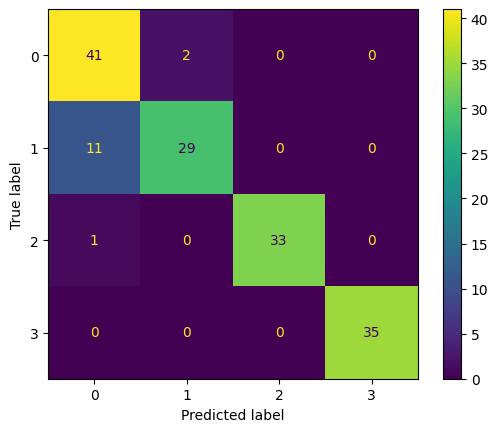

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 7, 9, 11],
    'max_samples': [0.5, 0.7, 0.9]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

#### Support Vector Machine Classifier

Best model for accuracy metric:
Accuracy: 0.855
Precision: [0.71428571 0.76470588 1.         1.        ]
Recall: [0.81395349 0.65       1.         1.        ]
F1: [0.76086957 0.7027027  1.         1.        ]
Best hyperparameters: {'C': 1, 'kernel': 'rbf'}

Best model for precision metric:
Accuracy: 0.855
Precision: [0.71428571 0.76470588 1.         1.        ]
Recall: [0.81395349 0.65       1.         1.        ]
F1: [0.76086957 0.7027027  1.         1.        ]
Best hyperparameters: {'C': 1, 'kernel': 'rbf'}

Best model for recall metric:
Accuracy: 0.855
Precision: [0.71428571 0.76470588 1.         1.        ]
Recall: [0.81395349 0.65       1.         1.        ]
F1: [0.76086957 0.7027027  1.         1.        ]
Best hyperparameters: {'C': 1, 'kernel': 'rbf'}

Best model for f1 metric:
Accuracy: 0.855
Precision: [0.71428571 0.76470588 1.         1.        ]
Recall: [0.81395349 0.65       1.         1.        ]
F1: [0.76086957 0.7027027  1.         1.        ]
Best hyperparameters: {'

,hyperparams,accuracy,precision_0,precision_1,precision_2,precision_3,recall_0,recall_1,recall_2,recall_3,f1_0,f1_1,f1_2,f1_3
0,"{""C"": 0.1, ""kernel"": ""linear""}",0.887 +/- 0.009,0.826 +/- 0.073,0.860 +/- 0.109,0.972 +/- 0.039,0.972 +/- 0.039,0.911 +/- 0.126,0.744 +/- 0.145,0.970 +/- 0.043,0.944 +/- 0.079,0.856 +/- 0.036,0.777 +/- 0.060,0.970 +/- 0.022,0.955 +/- 0.037
1,"{""C"": 0.1, ""kernel"": ""poly""}",0.285 +/- 0.007,0.285 +/- 0.007,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.443 +/- 0.008,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000
2,"{""C"": 0.1, ""kernel"": ""rbf""}",0.285 +/- 0.007,0.285 +/- 0.007,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000,0.443 +/- 0.008,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000
3,"{""C"": 0.1, ""kernel"": ""sigmoid""}",0.305 +/- 0.011,0.290 +/- 0.004,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,0.000 +/- 0.000,0.091 +/- 0.074,0.000 +/- 0.000,0.450 +/- 0.004,0.000 +/- 0.000,0.158 +/- 0.126,0.000 +/- 0.000
4,"{""C"": 1, ""kernel"": ""linear""}",0.887 +/- 0.009,0.826 +/- 0.073,0.860 +/- 0.109,0.972 +/- 0.039,0.972 +/- 0.039,0.911 +/- 0.126,0.744 +/- 0.145,0.970 +/- 0.043,0.944 +/- 0.079,0.856 +/- 0.036,0.777 +/- 0.060,0.970 +/- 0.022,0.955 +/- 0.037


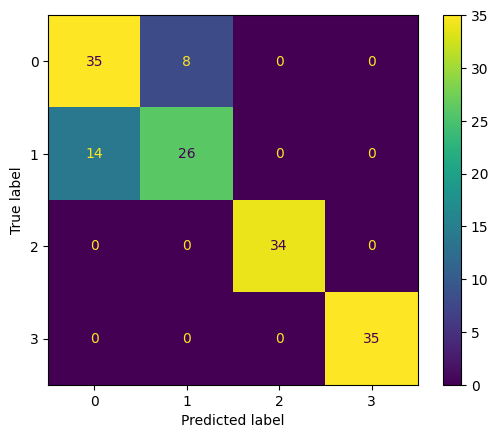

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

#### XGBoost Classifier

Best model for accuracy metric:
Accuracy: 0.875
Precision: [0.83783784 0.77272727 0.97058824 0.94594595]
Recall: [0.72093023 0.85       0.97058824 1.        ]
F1: [0.775      0.80952381 0.97058824 0.97222222]
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}

Best model for precision metric:
Accuracy: 0.875
Precision: [0.83783784 0.77272727 0.97058824 0.94594595]
Recall: [0.72093023 0.85       0.97058824 1.        ]
F1: [0.775      0.80952381 0.97058824 0.97222222]
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}

Best model for recall metric:
Accuracy: 0.875
Precision: [0.83783784 0.77272727 0.97058824 0.94594595]
Recall: [0.72093023 0.85       0.97058824 1.        ]
F1: [0.775      0.80952381 0.97058824 0.97222222]
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}

Best model for f1 metric:
Accuracy: 0.875
Precision: [0.83783784 0.77272727 0.97058824 0.94594595]
Recall: [0.72093023 0.85  

,hyperparams,accuracy,precision_0,precision_1,precision_2,precision_3,recall_0,recall_1,recall_2,recall_3,f1_0,f1_1,f1_2,f1_3
0,"{""learning_rate"": 0.01, ""max_depth"": 5, ""n_est...",0.702 +/- 0.060,0.582 +/- 0.068,0.715 +/- 0.035,0.826 +/- 0.060,0.729 +/- 0.125,0.675 +/- 0.088,0.564 +/- 0.073,0.823 +/- 0.075,0.778 +/- 0.258,0.622 +/- 0.063,0.626 +/- 0.040,0.822 +/- 0.045,0.745 +/- 0.190
1,"{""learning_rate"": 0.01, ""max_depth"": 5, ""n_est...",0.735 +/- 0.043,0.633 +/- 0.027,0.738 +/- 0.089,0.878 +/- 0.087,0.729 +/- 0.125,0.678 +/- 0.134,0.641 +/- 0.131,0.879 +/- 0.113,0.778 +/- 0.258,0.647 +/- 0.058,0.669 +/- 0.057,0.877 +/- 0.097,0.746 +/- 0.193
2,"{""learning_rate"": 0.01, ""max_depth"": 5, ""n_est...",0.735 +/- 0.059,0.629 +/- 0.053,0.802 +/- 0.140,0.878 +/- 0.087,0.693 +/- 0.144,0.700 +/- 0.112,0.641 +/- 0.131,0.879 +/- 0.113,0.750 +/- 0.297,0.657 +/- 0.053,0.688 +/- 0.045,0.877 +/- 0.097,0.710 +/- 0.223
3,"{""learning_rate"": 0.01, ""max_depth"": 5, ""n_est...",0.767 +/- 0.091,0.686 +/- 0.119,0.853 +/- 0.117,0.878 +/- 0.087,0.711 +/- 0.151,0.768 +/- 0.119,0.692 +/- 0.166,0.879 +/- 0.113,0.750 +/- 0.297,0.717 +/- 0.083,0.739 +/- 0.088,0.877 +/- 0.097,0.721 +/- 0.229
4,"{""learning_rate"": 0.01, ""max_depth"": 7, ""n_est...",0.702 +/- 0.060,0.582 +/- 0.068,0.715 +/- 0.035,0.826 +/- 0.060,0.729 +/- 0.125,0.675 +/- 0.088,0.564 +/- 0.073,0.823 +/- 0.075,0.778 +/- 0.258,0.622 +/- 0.063,0.626 +/- 0.040,0.822 +/- 0.045,0.745 +/- 0.190


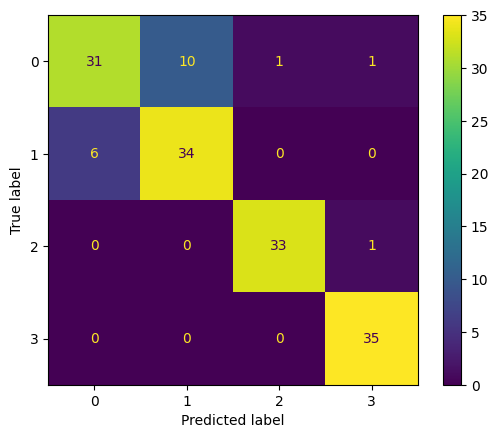

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 7, 9, 11],
    'learning_rate': [0.01, 0.1, 1, 10]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

### MITBIH dataset

#### Unbalanced

##### Standardization, encoding and percentile selecting

In [ ]:
# Prepare mitbih data for training
X_train = X_mitbih_train
y_train = y_mitbih_train

X_test = X_mitbih_test
y_test = y_mitbih_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  187
Number of selected features for training:  149


##### Random Forest Classifier

Best model for accuracy metric:
Accuracy: 0.946
Precision: [0.9393452  0.98222222 0.99199199 0.         0.99354376]
Recall: [0.99928244 0.39748201 0.68439227 0.         0.86131841]
F1: [0.96838727 0.5659411  0.80997139 0.         0.92271819]
Best hyperparameters: {'max_depth': 7, 'max_samples': 0.7, 'n_estimators': 100}



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,hyperparams,accuracy
0,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.934 +/- 0.000
1,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.933 +/- 0.001
2,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.933 +/- 0.001
3,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.933 +/- 0.000
4,"{""max_depth"": 7, ""max_samples"": 0.5, ""n_estima...",0.945 +/- 0.001


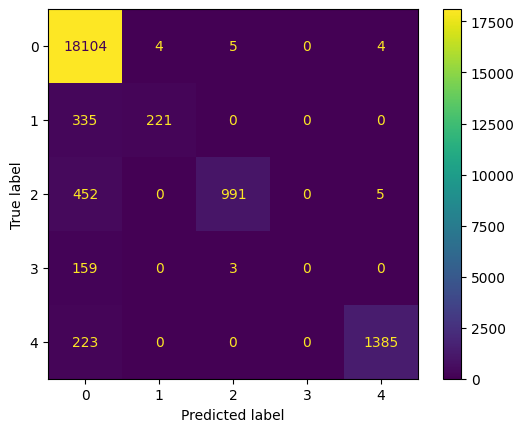

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
rfc_reports_df_unbalanced_mitbih = rfc_reports_df
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

##### Support Vector Machine Classifier

Best model for accuracy metric:
Accuracy: 0.974
Precision: [0.97567568 0.94182825 0.95544193 0.76377953 0.99478488]
Recall: [0.99630182 0.61151079 0.90331492 0.59876543 0.94900498]
F1: [0.98588088 0.74154853 0.9286475  0.67128028 0.97135582]
Best hyperparameters: {'C': 10, 'kernel': 'poly'}



,hyperparams,accuracy
0,"{""C"": 1, ""kernel"": ""linear""}",0.917 +/- 0.001
1,"{""C"": 1, ""kernel"": ""poly""}",0.965 +/- 0.000
2,"{""C"": 10, ""kernel"": ""linear""}",0.918 +/- 0.001
3,"{""C"": 10, ""kernel"": ""poly""}",0.973 +/- 0.000


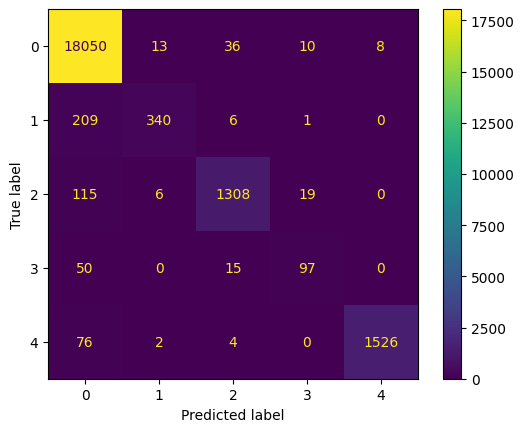

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [1, 10],
    'kernel': ['linear', 'poly']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
svc_reports_df_unbalanced_mitbih = svc_reports_df
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

##### XGBoost Classifier

[22:54:05] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[22:54:41] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[22:55:18] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[22:55:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[22:57:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[22:58:20] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp

,hyperparams,accuracy
0,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.978 +/- 0.001
1,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.980 +/- 0.000
2,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.978 +/- 0.001
3,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.980 +/- 0.000
4,"{""max_depth"": 7, ""max_samples"": 0.5, ""n_estima...",0.979 +/- 0.000


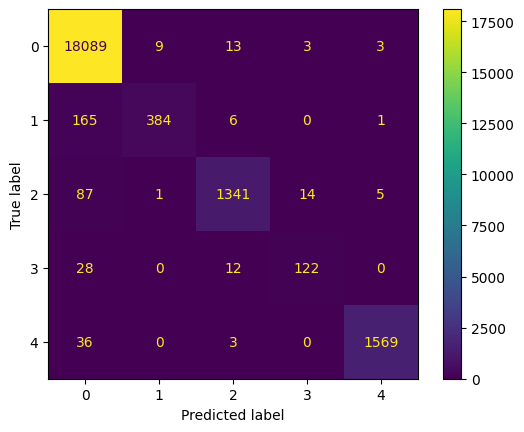

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
xgb_reports_df_unbalanced_mitbih = xgb_reports_df
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

#### Balanced

In [ ]:
# Separate majority and minority classes
df_mitbih_train_0 = df_mitbih_train[df_mitbih_train.iloc[:, -1] == 0]
df_mitbih_train_1 = df_mitbih_train[df_mitbih_train.iloc[:, -1] == 1]
df_mitbih_train_2 = df_mitbih_train[df_mitbih_train.iloc[:, -1] == 2]
df_mitbih_train_3 = df_mitbih_train[df_mitbih_train.iloc[:, -1] == 3]
df_mitbih_train_4 = df_mitbih_train[df_mitbih_train.iloc[:, -1] == 4]

# Upsample minority classes
df_mitbih_train_1_upsampled = resample(
    df_mitbih_train_1, 
    replace=True,                               # sample with replacement
    n_samples=df_mitbih_train_0.shape[0],       # to match majority class
    random_state=123
) # reproducible results

df_mitbih_train_2_upsampled = resample(
    df_mitbih_train_2, 
    replace=True,                               # sample with replacement
    n_samples=df_mitbih_train_0.shape[0],       # to match majority class
    random_state=123
) # reproducible results

df_mitbih_train_3_upsampled = resample(
    df_mitbih_train_3, 
    replace=True,                               # sample with replacement
    n_samples=df_mitbih_train_0.shape[0],       # to match majority class
    random_state=123
) # reproducible results

df_mitbih_train_4_upsampled = resample(
    df_mitbih_train_4, 
    replace=True,                               # sample with replacement
    n_samples=df_mitbih_train_0.shape[0],       # to match majority class
    random_state=123
) # reproducible results

# Combine majority class with upsampled minority class
df_mitbih_train_upsampled = pd.concat([df_mitbih_train_0, df_mitbih_train_1_upsampled, df_mitbih_train_2_upsampled, df_mitbih_train_3_upsampled, df_mitbih_train_4_upsampled])

# Display new class counts
df_mitbih_train_upsampled.iloc[:, -1].value_counts()

0.0    72470
1.0    72470
2.0    72470
3.0    72470
4.0    72470
Name: 0.000000000000000000e+00.88, dtype: int64

##### Dataset preprocessing for training

In [ ]:
X_mitbih_upsampled_train = df_mitbih_train_upsampled.iloc[:, :-1]
y_mitbih_upsampled_train = df_mitbih_train_upsampled.iloc[:, -1]

# Prepare mitbih data for training
X_train = X_mitbih_upsampled_train
y_train = y_mitbih_upsampled_train

X_test = X_mitbih_test
y_test = y_mitbih_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  187
Number of selected features for training:  149


##### Random Forest Classifier

Best model for accuracy metric:
Accuracy: 0.876
Precision: [0.97830096 0.37947725 0.80551905 0.10851545 0.86674325]
Recall: [0.8784567  0.70503597 0.84668508 0.88888889 0.93843284]
F1: [0.92569434 0.49339207 0.82558923 0.1934184  0.90116453]
Best hyperparameters: {'max_depth': 7, 'max_samples': 0.7, 'n_estimators': 100}



,hyperparams,accuracy
0,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.811 +/- 0.002
1,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.812 +/- 0.003
2,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.811 +/- 0.002
3,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.812 +/- 0.002
4,"{""max_depth"": 7, ""max_samples"": 0.5, ""n_estima...",0.881 +/- 0.001


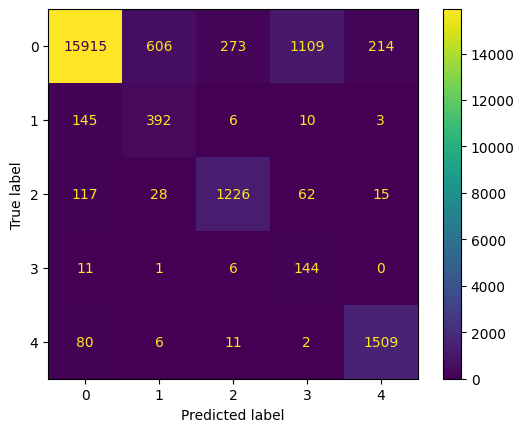

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
rfc_reports_df_balanced_mitbih = rfc_reports_df
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

##### Support Vector Machine Classifier

Best model for accuracy metric:
Accuracy: 0.952
Precision: [0.99021683 0.52528736 0.92155525 0.30508475 0.98067332]
Recall: [0.95534581 0.82194245 0.93301105 0.88888889 0.97823383]
F1: [0.97246882 0.64095372 0.92724777 0.45425868 0.97945205]
Best hyperparameters: {'C': 10, 'kernel': 'poly'}



,hyperparams,accuracy
0,"{""C"": 1, ""kernel"": ""linear""}",0.814 +/- 0.001
1,"{""C"": 1, ""kernel"": ""poly""}",0.957 +/- 0.000
2,"{""C"": 10, ""kernel"": ""linear""}",0.819 +/- 0.001
3,"{""C"": 10, ""kernel"": ""poly""}",0.983 +/- 0.000


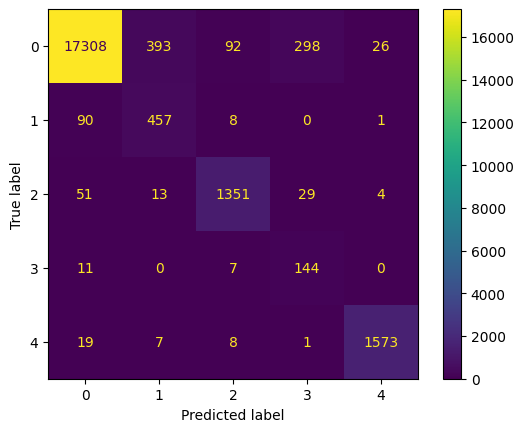

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [1, 10],
    'kernel': ['linear', 'poly']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
svc_reports_df_balanced_mitbih = svc_reports_df
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

##### XGBoost Classifier

[23:54:55] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[23:56:33] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[23:58:08] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[23:59:42] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[00:02:56] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "max_samples" } are not used.

[00:06:03] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp

,hyperparams,accuracy
0,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.995 +/- 0.000
1,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.998 +/- 0.000
2,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.995 +/- 0.000
3,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.998 +/- 0.000
4,"{""max_depth"": 7, ""max_samples"": 0.5, ""n_estima...",0.998 +/- 0.000


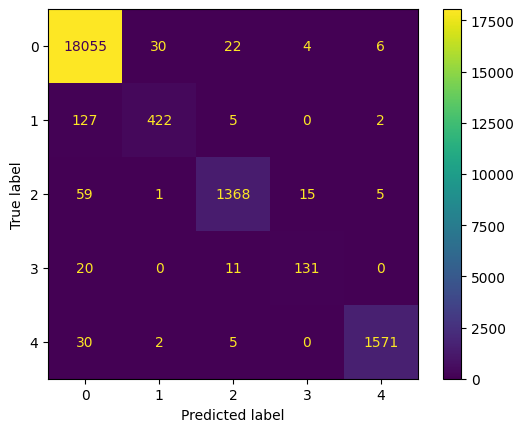

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
xgb_reports_df_balanced_mitbih = xgb_reports_df
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

####  Balanced with Attributes extraction

##### Attributes extraction

In [ ]:
# create statistical dataframe from racket sports
def create_arrhythmia_statistical_df(df: pd.DataFrame):
    statistical_df = pd.DataFrame()
    statistical_df['mean'] = df.apply(lambda x: x.mean(), axis=1)
    statistical_df[f'std'] = df.apply(lambda x: x.std(), axis=1)
    statistical_df[f'aad'] = df.apply(lambda x: (x - x.mean()).abs().mean(), axis=1)
    statistical_df[f'min'] = df.apply(lambda x: x.min(), axis=1)
    statistical_df[f'max'] = df.apply(lambda x: x.max(), axis=1)
    statistical_df[f'maxmin_diff'] = df.apply(lambda x: x.max() - x.min(), axis=1)
    statistical_df[f'median'] = df.apply(lambda x: x.median(), axis=1)
    statistical_df[f'mad'] = df.apply(lambda x: (x - x.median()).abs().median(), axis=1)
    statistical_df[f'iqr'] = df.apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25), axis=1)
    statistical_df[f'neg_count'] = df.apply(lambda x: (x < 0).sum(), axis=1)
    statistical_df[f'pos_count'] = df.apply(lambda x: (x > 0).sum(), axis=1)
    statistical_df[f'above_mean'] = df.apply(lambda x: (x > x.mean()).sum(), axis=1)
    statistical_df[f'peak_count'] = df.apply(lambda x: len(find_peaks(x)[0]), axis=1)
    statistical_df[f'energy'] = df.apply(lambda x: np.sum(x**2).mean(), axis=1)
    statistical_df[f'skewness'] = df.apply(lambda x: x.skew(), axis=1)
    statistical_df[f'kurtosis'] = df.apply(lambda x: x.kurtosis(), axis=1)

    return statistical_df


In [ ]:
X_mitbih_statistical_train = create_arrhythmia_statistical_df(X_mitbih_upsampled_train)
X_mitbih_statistical_test = create_arrhythmia_statistical_df(X_mitbih_test)

X_mitbih_statistical_train
X_mitbih_statistical_test

,mean,std,aad,min,max,maxmin_diff,median,mad,iqr,neg_count,pos_count,above_mean,peak_count,energy,skewness,kurtosis
0,0.196353,0.236600,0.204620,0.0,1.0,1.0,0.029304,0.029304,0.340659,0,99,86,16,17.621866,1.014114,0.386610
1,0.112063,0.137927,0.099205,0.0,1.0,1.0,0.101770,0.101770,0.185841,0,108,88,34,5.886796,2.529650,11.305646
2,0.161664,0.208151,0.158527,0.0,1.0,1.0,0.122917,0.122917,0.275000,0,104,79,13,12.946107,1.795731,3.983538
3,0.201629,0.206426,0.173879,0.0,1.0,1.0,0.231544,0.171141,0.338926,0,114,96,39,15.528174,0.972238,1.288681
4,0.089929,0.176790,0.093738,0.0,1.0,1.0,0.048346,0.048346,0.105598,0,104,60,26,7.325713,3.825211,15.464305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21886,0.330364,0.300187,0.269984,0.0,1.0,1.0,0.434483,0.317241,0.512069,0,120,101,11,37.170185,0.222835,-1.279024
21887,0.394955,0.330448,0.304676,0.0,1.0,1.0,0.562033,0.258595,0.642003,0,124,107,22,49.480339,-0.068627,-1.525081
21888,0.106412,0.149061,0.094338,0.0,1.0,1.0,0.091988,0.083086,0.148368,0,120,83,37,6.250280,3.169188,13.917826
21889,0.189882,0.191647,0.146175,0.0,1.0,1.0,0.214286,0.142857,0.265873,0,119,108,39,13.573854,1.261984,2.530023


In [ ]:
# concatenate balanced and statistical dataframes
X_mitbih_full_train = pd.concat([X_mitbih_upsampled_train, X_mitbih_statistical_train], axis=1)
X_mitbih_full_test = pd.concat([X_mitbih_test, X_mitbih_statistical_test], axis=1)

##### Dataset preprocessing for training

In [ ]:
# Prepare mitbih data for training
X_train = X_mitbih_full_train
y_train = y_mitbih_upsampled_train

X_test = X_mitbih_full_test
y_test = y_mitbih_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  203
Number of selected features for training:  162


/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [196] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


##### Random Forest Classifier

Best model for accuracy metric:
Accuracy: 0.875
Precision: [0.97784206 0.39112903 0.80357143 0.10859729 0.83296582]
Recall: [0.87691119 0.69784173 0.8390884  0.88888889 0.93967662]
F1: [0.92463043 0.50129199 0.82094595 0.19354839 0.88310929]
Best hyperparameters: {'max_depth': 7, 'max_samples': 0.7, 'n_estimators': 100}



,hyperparams,accuracy
0,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.809 +/- 0.001
1,"{""max_depth"": 5, ""max_samples"": 0.5, ""n_estima...",0.810 +/- 0.001
2,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.810 +/- 0.003
3,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.812 +/- 0.001
4,"{""max_depth"": 7, ""max_samples"": 0.5, ""n_estima...",0.882 +/- 0.002


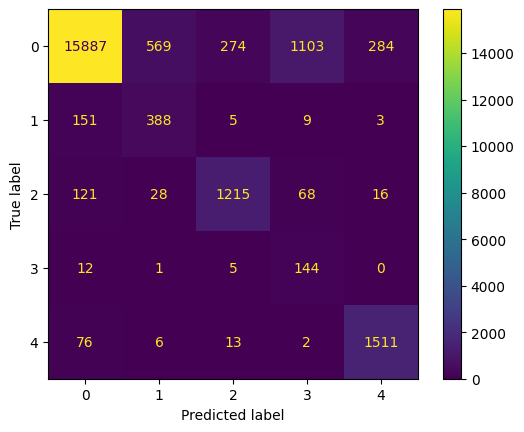

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
rfc_reports_df_balanced_attr_mitbih = rfc_reports_df
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

##### Support Vector Machine Classifier

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [1, 10],
    'kernel': ['linear', 'poly']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
svc_reports_df_balanced_attr_mitbih = svc_reports_df
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

##### XGBoost Classifier

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
xgb_reports_df_balanced_attr_mitbih = xgb_reports_df
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

### PTB dataset

#### Unbalanced

##### Standardization, encoding and percentile selecting

In [ ]:
# Prepare ptb data for training
X_train = X_ptb_train
y_train = y_ptb_train

X_test = X_ptb_test
y_test = y_ptb_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  187
Number of selected features for training:  149


/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


##### Random Forest Classifier

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best model for accuracy metric:
Accuracy: 0.934
Precision: [0.92779543 0.9869281  0.98969072 0.         0.98371577]
Recall: [0.99933764 0.27158273 0.59668508 0.         0.82649254]
F1: [0.96223858 0.42595205 0.74450668 0.         0.89827644]
Best hyperparameters: {'max_depth': 5, 'max_samples': 0.7, 'n_estimators': 100}



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best model for precision metric:
Accuracy: 0.934
Precision: [0.92779543 0.9869281  0.98969072 0.         0.98371577]
Recall: [0.99933764 0.27158273 0.59668508 0.         0.82649254]
F1: [0.96223858 0.42595205 0.74450668 0.         0.89827644]
Best hyperparameters: {'max_depth': 5, 'max_samples': 0.7, 'n_estimators': 100}



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Best model for recall metric:
Accuracy: 0.934
Precision: [0.92779543 0.9869281  0.98969072 0.         0.98371577]
Recall: [0.99933764 0.27158273 0.59668508 0.         0.82649254]
F1: [0.96223858 0.42595205 0.74450668 0.         0.89827644]
Best hyperparameters: {'max_depth': 5, 'max_samples': 0.7, 'n_estimators': 100}

Best model for f1 metric:
Accuracy: 0.934
Precision: [0.92779543 0.9869281  0.98969072 0.         0.98371577]
Recall: [0.99933764 0.27158273 0.59668508 0.         0.82649254]
F1: [0.96223858 0.42595205 0.74450668 0.         0.89827644]
Best hyperparameters: {'max_depth': 5, 'max_samples': 0.7, 'n_estimators': 100}



/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,hyperparams,accuracy,precision_0,precision_1,precision_2,precision_3,recall_0,recall_1,recall_2,recall_3,f1_0,f1_1,f1_2,f1_3
0,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.932 +/- 0.001,0.927 +/- 0.001,0.973 +/- 0.010,0.982 +/- 0.004,1.000 +/- 0.000,0.999 +/- 0.000,0.217 +/- 0.026,0.577 +/- 0.013,0.000 +/- 0.000,0.962 +/- 0.001,0.355 +/- 0.035,0.727 +/- 0.011,0.000 +/- 0.000
1,"{""max_depth"": 5, ""max_samples"": 0.7, ""n_estima...",0.933 +/- 0.001,0.927 +/- 0.001,0.980 +/- 0.007,0.984 +/- 0.006,1.000 +/- 0.000,0.999 +/- 0.000,0.248 +/- 0.026,0.575 +/- 0.015,0.000 +/- 0.000,0.962 +/- 0.001,0.396 +/- 0.033,0.726 +/- 0.013,0.000 +/- 0.000


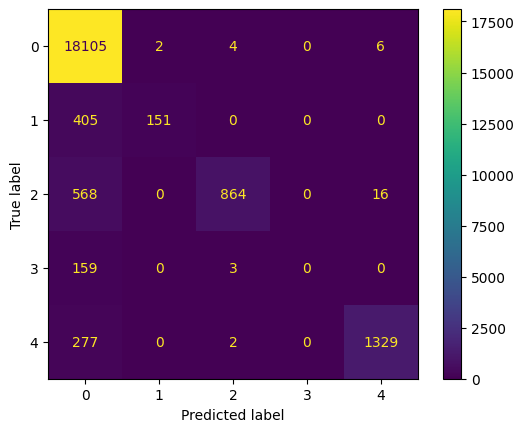

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
rfc_reports_df_unbalanced_ptb = rfc_reports_df
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

##### Support Vector Machine Classifier

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [1, 10],
    'kernel': ['linear', 'poly']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
svc_reports_df_unbalanced_ptb = svc_reports_df
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

##### XGBoost Classifier

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
xgb_reports_df_unbalanced_ptb = xgb_reports_df
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

#### Balanced

In [ ]:
df_ptb_train = pd.DataFrame(X_ptb_train)
df_ptb_train['target'] = y_ptb_train

# Separate majority and minority classes
df_ptb_train_0 = df_ptb_train[df_ptb_train.iloc[:, -1] == 0]
df_ptb_train_1 = df_ptb_train[df_ptb_train.iloc[:, -1] == 1]

# Upsample minority classes
df_ptb_train_0_upsampled = resample(
    df_ptb_train_0, 
    replace=True,                               # sample with replacement
    n_samples=df_ptb_train_1.shape[0],          # to match majority class
    random_state=123
) # reproducible results

# Combine majority class with upsampled minority class
df_ptb_train_upsampled = pd.concat([df_ptb_train_0_upsampled, df_ptb_train_1])

# Display new class counts
df_ptb_train_upsampled.iloc[:, -1].value_counts()

0.0    7362
1.0    7362
Name: target, dtype: int64

##### Dataset preprocessing for training

In [ ]:
X_ptb_upsampled_train = df_ptb_train_upsampled.iloc[:, :-1]
y_ptb_upsampled_train = df_ptb_train_upsampled.iloc[:, -1]

# Prepare mitbih data for training
X_train = X_ptb_upsampled_train
y_train = y_ptb_upsampled_train

X_test = X_ptb_test
y_test = y_ptb_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  187
Number of selected features for training:  149


/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


##### Random Forest Classifier

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
rfc_reports_df_balanced_ptb = rfc_reports_df
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

##### Support Vector Machine Classifier

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [1, 10],
    'kernel': ['linear', 'poly']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
svc_reports_df_balanced_ptb = svc_reports_df
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

##### XGBoost Classifier

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
xgb_reports_df_balanced_ptb = xgb_reports_df
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

####  Balanced with Attributes extraction

##### Attributes extraction

In [ ]:
# create statistical dataframe from racket sports
def create_arrhythmia_statistical_df(df: pd.DataFrame):
    statistical_df = pd.DataFrame()
    statistical_df['mean'] = df.apply(lambda x: x.mean(), axis=1)
    statistical_df[f'std'] = df.apply(lambda x: x.std(), axis=1)
    statistical_df[f'aad'] = df.apply(lambda x: (x - x.mean()).abs().mean(), axis=1)
    statistical_df[f'min'] = df.apply(lambda x: x.min(), axis=1)
    statistical_df[f'max'] = df.apply(lambda x: x.max(), axis=1)
    statistical_df[f'maxmin_diff'] = df.apply(lambda x: x.max() - x.min(), axis=1)
    statistical_df[f'median'] = df.apply(lambda x: x.median(), axis=1)
    statistical_df[f'mad'] = df.apply(lambda x: (x - x.median()).abs().median(), axis=1)
    statistical_df[f'iqr'] = df.apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25), axis=1)
    statistical_df[f'neg_count'] = df.apply(lambda x: (x < 0).sum(), axis=1)
    statistical_df[f'pos_count'] = df.apply(lambda x: (x > 0).sum(), axis=1)
    statistical_df[f'above_mean'] = df.apply(lambda x: (x > x.mean()).sum(), axis=1)
    statistical_df[f'peak_count'] = df.apply(lambda x: len(find_peaks(x)[0]), axis=1)
    statistical_df[f'energy'] = df.apply(lambda x: np.sum(x**2).mean(), axis=1)
    statistical_df[f'skewness'] = df.apply(lambda x: x.skew(), axis=1)
    statistical_df[f'kurtosis'] = df.apply(lambda x: x.kurtosis(), axis=1)

    return statistical_df


In [ ]:
X_ptb_statistical_train = create_arrhythmia_statistical_df(X_ptb_upsampled_train)
X_ptb_statistical_test = create_arrhythmia_statistical_df(X_ptb_test)

X_ptb_statistical_train
X_ptb_statistical_test

,mean,std,aad,min,max,maxmin_diff,median,mad,iqr,neg_count,pos_count,above_mean,peak_count,energy,skewness,kurtosis
2069,0.121087,0.156566,0.087535,0.0,1.0,1.0,0.099034,0.042271,0.133253,0,138,61,27,7.301231,3.410261,14.687767
2129,0.144990,0.156607,0.107397,0.0,1.0,1.0,0.180820,0.034643,0.203845,0,119,117,36,8.492943,2.505264,10.870415
5266,0.089728,0.136744,0.088645,0.0,1.0,1.0,0.066632,0.066632,0.164902,0,101,65,26,4.983585,3.694066,19.307111
1362,0.167757,0.183268,0.160906,0.0,1.0,1.0,0.191489,0.191489,0.302600,0,99,94,21,11.509844,1.093889,2.471782
4985,0.079938,0.152887,0.090536,0.0,1.0,1.0,0.000000,0.000000,0.110468,0,84,70,22,5.542594,3.795764,17.140996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3413,0.156701,0.159015,0.113564,0.0,1.0,1.0,0.191699,0.052805,0.212040,0,120,118,25,9.294942,2.024936,8.074043
1361,0.092245,0.161289,0.095821,0.0,1.0,1.0,0.048138,0.048138,0.107450,0,110,58,25,6.429838,3.482231,14.061415
906,0.164486,0.155603,0.096100,0.0,1.0,1.0,0.151618,0.051107,0.104983,0,147,67,25,9.562923,2.452619,9.438633
3814,0.160440,0.150543,0.097335,0.0,1.0,1.0,0.153085,0.054075,0.199543,0,138,86,33,9.028923,2.097136,7.982957


In [ ]:
# concatenate balanced and statistical dataframes
X_ptb_full_train = pd.concat([X_ptb_upsampled_train, X_ptb_statistical_train], axis=1)
X_ptb_full_test = pd.concat([X_ptb_test, X_ptb_statistical_test], axis=1)

##### Dataset preprocessing for training

In [ ]:
# Prepare mitbih data for training
X_train = X_ptb_full_train
y_train = y_ptb_upsampled_train

X_test = X_ptb_full_test
y_test = y_ptb_test

# Number of initial features
print("Number of initial features: ", X_train.shape[1])

# Encode the target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

labels = np.unique(y_train)
scorings = compute_scorings(labels)

# Calculate the score for each feature
selector = SelectPercentile(percentile=80)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Number of final features
print("Number of selected features for training: ", X_train.shape[1])

Number of initial features:  203
Number of selected features for training:  162


/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186 190 191 192 196] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/homebrew/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


##### Random Forest Classifier

In [ ]:
# Random Forest Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
rfc = RandomForestClassifier(random_state=0)

# Perform grid search
rfc_reports_df, rfc_cm = perform_grid_search(rfc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
rfc_reports_df_balanced_attr_ptb = rfc_reports_df
ConfusionMatrixDisplay(rfc_cm, display_labels=labels).plot()
rfc_reports_df.head()

##### Support Vector Machine Classifier

In [ ]:
# Support Vector Machine Classifier

# Define the hyperparameters to search
parameters = {
    'C': [1, 10],
    'kernel': ['linear', 'poly']
}

# Define the model
svc = SVC(random_state=0)

# Perform grid search
svc_reports_df, svc_cm = perform_grid_search(svc, parameters, X_train, y_train, X_test, y_test, labels, scorings)
svc_reports_df_balanced_attr_ptb = svc_reports_df
ConfusionMatrixDisplay(svc_cm, display_labels=labels).plot()
svc_reports_df.head()

##### XGBoost Classifier

In [ ]:
# XGBoost Classifier

# Define the hyperparameters to search
parameters = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'max_samples': [0.5, 0.7]
}

# Define the model
xgb = XGBClassifier(random_state=0)

# Perform grid search
xgb_reports_df, xgb_cm = perform_grid_search(xgb, parameters, X_train, y_train, X_test, y_test, labels, scorings)
xgb_reports_df_balanced_attr_ptb = xgb_reports_df
ConfusionMatrixDisplay(xgb_cm, display_labels=labels).plot()
xgb_reports_df.head()

## 3.3 Neural networks


### Generic training & testing & plotting functions

In [5]:
crossEntropy = nn.CrossEntropyLoss()

In [6]:
def train_nn(model, X_train, y_train, X_test, y_test, criterion, optimizer_type, num_epochs, batch_size, model_type="mlp"):
    # Encode the target variable
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    # Calculate the score for each feature
    selector = SelectPercentile(percentile=80)
    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)

    # Reshape dataset for CNN
    if model_type == "cnn":
        X_train = X_train.reshape(-1, 1, X_train.shape[1])
        X_test = X_test.reshape(-1, 1, X_test.shape[1])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    # Convert to tensors
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size, shuffle=True)

    if optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=10, momentum=0.9)
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=10, epochs=10, anneal_strategy='linear')

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()

        for inputs, labels in train_loader:
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Update the learning rate
        if optimizer_type == "sgd" and (epoch + 1) % 10 == 0:
            scheduler.step()

        # Set model to evaluation mode
        model.eval()

        # Validation on the training set
        with torch.no_grad():
            train_loss = 0.0
            train_predictions = []
            train_targets = []

            for inputs, labels in train_loader:
                train_outputs = model(inputs)
                train_loss += criterion(train_outputs, labels).item()
                train_predictions.extend(torch.argmax(train_outputs, dim=1).tolist())
                train_targets.extend(labels.tolist())

            train_loss /= len(train_loader)
            train_accuracy = accuracy_score(train_targets, train_predictions)

        # Validation on the test set
        with torch.no_grad():
            test_loss = 0.0
            test_predictions = []
            test_targets = []

            for inputs, labels in test_loader:
                test_outputs = model(inputs)
                test_loss += criterion(test_outputs, labels).item()
                test_predictions.extend(torch.argmax(test_outputs, dim=1).tolist())
                test_targets.extend(labels.tolist())

            test_loss /= len(test_loader)
            test_accuracy = accuracy_score(test_targets, test_predictions)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        # Print epoch information
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"Train Loss: {train_loss}, Train Accuracy: {train_accuracy}")
            print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")
            print(f"------------------")

    return [train_losses, test_losses, test_loader]



In [7]:
def test_nn(model, criterion, test_loader):
    # Set model to evaluation mode
    model.eval()

    eval_predictions = []
    eval_targets = []
    # Validation on the test set
    with torch.no_grad():
        for inputs, labels in test_loader:
            test_outputs = model(inputs)
            eval_predictions.extend(torch.argmax(test_outputs, dim=1).tolist())
            eval_targets.extend(labels.tolist())

    # Compute accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(eval_targets, eval_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(eval_targets, eval_predictions, average=None)
    cm = confusion_matrix(eval_targets, eval_predictions)

    print("Metrics")
    print(f"Accuracy: {accuracy:.3f}", f"Precision: {precision}", f"Recall: {recall}", f"F1: {f1}", sep='\n')
    ConfusionMatrixDisplay(cm).plot()

In [8]:
def plot_losses(num_epochs, train_losses, test_losses):
    # Define the labels and line styles/colors for each model
    models = ['Adam (batch_size=64)', 'Adam (batch_size=128)', 'SGD (batch_size=64)', 'SGD (batch_size=128)']
    line_styles = ['-', '--', '-.', ':']
    colors = ['blue', 'red', 'green', 'purple']

    # Plot train and test losses for each model
    plt.figure(figsize=(10, 8))
    for i in range(len(models)):
        plt.plot(range(1, num_epochs+1), train_losses[i], label=models[i] + ' (Train Loss)', linestyle=line_styles[i], color=colors[i])
        plt.plot(range(1, num_epochs+1), test_losses[i], label=models[i] + ' (Test Loss)', linestyle=line_styles[i], color=colors[i], alpha=0.7)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train and Test Losses for Different Models')
    plt.legend()
    plt.grid(True)
    plt.show()

### MLP

#### Architecture

In [8]:
class MLP3(nn.Module):
    def __init__(self,  output_size):
        super(MLP3, self).__init__()
        # 187 (initial) * 80 // 100 (feature selection) = 149
        self.fc1 = nn.Linear(149, 512)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.dropout1(self.relu(self.fc1(x)))
        out = self.dropout2(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

class MLP4(nn.Module):
    def __init__(self, output_size):
        super(MLP4, self).__init__()
        # 189 (initial) * 80 // 100 (feature selection) = 149
        self.fc1 = nn.Linear(149, 81)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(81, 27)
        self.dropout2 = nn.Dropout(0.25)
        self.fc3 = nn.Linear(27, 9)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(9, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.dropout1(self.relu(self.fc1(x)))
        out = self.dropout2(self.relu(self.fc2(out)))
        out = self.dropout3(self.relu(self.fc3(out)))
        out = self.fc4(out)
        return out

#### MITBIH dataset

##### 3 layers

Epoch 10/100
Train Loss: 0.07915291446584048, Train Accuracy: 0.9749523145980149
Test Loss: 0.1015320950053339, Test Accuracy: 0.9722260289616738
------------------
Epoch 20/100
Train Loss: 0.05695409199748035, Train Accuracy: 0.9818509931127432
Test Loss: 0.08645014796316428, Test Accuracy: 0.9775706911516148
------------------
Epoch 30/100
Train Loss: 0.0472299442773118, Train Accuracy: 0.984969104428175
Test Loss: 0.08387740377782038, Test Accuracy: 0.9791695217212553
------------------
Epoch 40/100
Train Loss: 0.0401875410206688, Train Accuracy: 0.9866709307505168
Test Loss: 0.08256644330227764, Test Accuracy: 0.9799004156959481
------------------
Epoch 50/100
Train Loss: 0.037002994828409165, Train Accuracy: 0.9873790732470618
Test Loss: 0.08095887451943108, Test Accuracy: 0.9805399479238043
------------------
Epoch 60/100
Train Loss: 0.03238433809831726, Train Accuracy: 0.988978104690873
Test Loss: 0.07989741964721458, Test Accuracy: 0.9813165227719154
------------------
Epoch 70

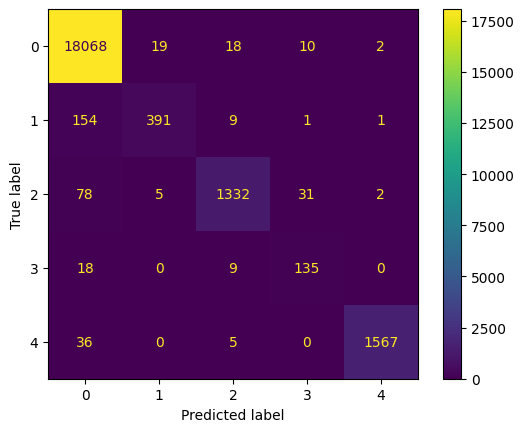

In [32]:
mlp3_mitbih_adam_64 = MLP3(5)
[mlp3_mitbih_adam_64_train_losses, mlp3_mitbih_adam_64_test_losses, mlp3_mitbih_adam_64_test_loader] = train_nn(mlp3_mitbih_adam_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 64)
test_nn(mlp3_mitbih_adam_64, crossEntropy, mlp3_mitbih_adam_64_test_loader)

Epoch 10/100
Train Loss: 0.076871202330795, Train Accuracy: 0.9775678731739632
Test Loss: 0.09222564950780293, Test Accuracy: 0.974555753506007
------------------
Epoch 20/100
Train Loss: 0.05900580197518324, Train Accuracy: 0.9819880529507841
Test Loss: 0.08460127671677646, Test Accuracy: 0.9761089032022292
------------------
Epoch 30/100
Train Loss: 0.04486803179130937, Train Accuracy: 0.9855287654335089
Test Loss: 0.07703315659472178, Test Accuracy: 0.9804029053035495
------------------
Epoch 40/100
Train Loss: 0.03942733007017629, Train Accuracy: 0.9865110276061357
Test Loss: 0.07632182294307926, Test Accuracy: 0.9809053949111507
------------------
Epoch 50/100
Train Loss: 0.03331897401996127, Train Accuracy: 0.9886240334426005
Test Loss: 0.0755970998598482, Test Accuracy: 0.9824128637339546
------------------
Epoch 60/100
Train Loss: 0.03191343580005541, Train Accuracy: 0.9890009479972132
Test Loss: 0.0859135650896987, Test Accuracy: 0.980951075784569
------------------
Epoch 70/1

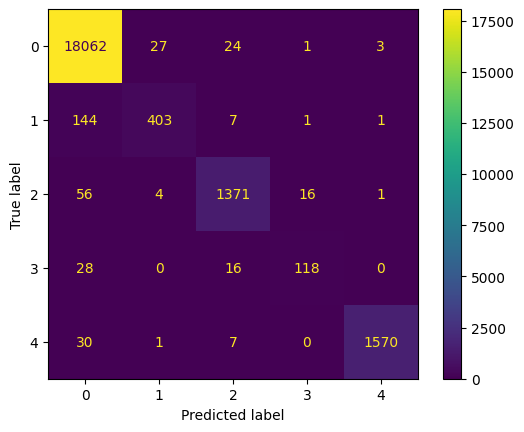

In [33]:
mlp3_mitbih_adam_128 = MLP3(5)
[mlp3_mitbih_adam_128_train_losses, mlp3_mitbih_adam_128_test_losses, mlp3_mitbih_adam_128_test_loader] = train_nn(mlp3_mitbih_adam_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 128)
test_nn(mlp3_mitbih_adam_128, crossEntropy, mlp3_mitbih_adam_128_test_loader)

Epoch 10/100
Train Loss: 0.10283093185026615, Train Accuracy: 0.9696526675270979
Test Loss: 0.11505208529108381, Test Accuracy: 0.9675665798730072
------------------
Epoch 20/100
Train Loss: 0.07194730123258007, Train Accuracy: 0.9787899900631617
Test Loss: 0.08936463870815274, Test Accuracy: 0.9758804988351377
------------------
Epoch 30/100
Train Loss: 0.0574415622459666, Train Accuracy: 0.9820565828698046
Test Loss: 0.07849679055705845, Test Accuracy: 0.9779361381389612
------------------
Epoch 40/100
Train Loss: 0.0522268048971229, Train Accuracy: 0.9837926741516567
Test Loss: 0.07971962697738809, Test Accuracy: 0.9785756703668174
------------------
Epoch 50/100
Train Loss: 0.04572422191046738, Train Accuracy: 0.9855972953525294
Test Loss: 0.07528009349358086, Test Accuracy: 0.9802658626832945
------------------
Epoch 60/100
Train Loss: 0.041334044491417074, Train Accuracy: 0.9865909791783263
Test Loss: 0.07471372876431706, Test Accuracy: 0.9803572244301311
------------------
Epoch

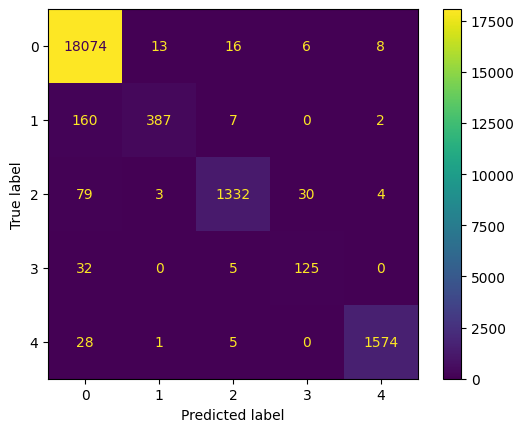

In [34]:
mlp3_mitbih_sgd_64 = MLP3(5)
[mlp3_mitbih_sgd_64_train_losses, mlp3_mitbih_sgd_64_test_losses, mlp3_mitbih_sgd_64_test_loader] = train_nn(mlp3_mitbih_sgd_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 64)
test_nn(mlp3_mitbih_sgd_64, crossEntropy, mlp3_mitbih_sgd_64_test_loader)

Epoch 10/100
Train Loss: 0.12846014926237237, Train Accuracy: 0.9647870432766439
Test Loss: 0.13992546226959243, Test Accuracy: 0.962358960303321
------------------
Epoch 20/100
Train Loss: 0.08666274711654529, Train Accuracy: 0.9749980012106952
Test Loss: 0.10172025543139425, Test Accuracy: 0.9721803480882555
------------------
Epoch 30/100
Train Loss: 0.07977908468825648, Train Accuracy: 0.9781960640983176
Test Loss: 0.0938861136051263, Test Accuracy: 0.9738248595313143
------------------
Epoch 40/100
Train Loss: 0.060551887767025726, Train Accuracy: 0.9817710415405526
Test Loss: 0.0823212088456108, Test Accuracy: 0.9772052441642685
------------------
Epoch 50/100
Train Loss: 0.05524747725644142, Train Accuracy: 0.9827190387536692
Test Loss: 0.08215337646258779, Test Accuracy: 0.9778447763921246
------------------
Epoch 60/100
Train Loss: 0.05150743477780671, Train Accuracy: 0.984409443422841
Test Loss: 0.07847756228063169, Test Accuracy: 0.978804074733909
------------------
Epoch 70

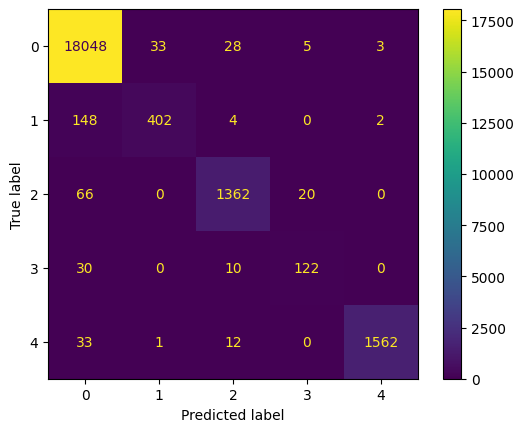

In [35]:
mlp3_mitbih_sgd_128 = MLP3(5)
[mlp3_mitbih_sgd_128_train_losses, mlp3_mitbih_sgd_128_test_losses, mlp3_mitbih_sgd_128_test_loader] = train_nn(mlp3_mitbih_sgd_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 128)
test_nn(mlp3_mitbih_sgd_128, crossEntropy, mlp3_mitbih_sgd_128_test_loader)

##### Plotting

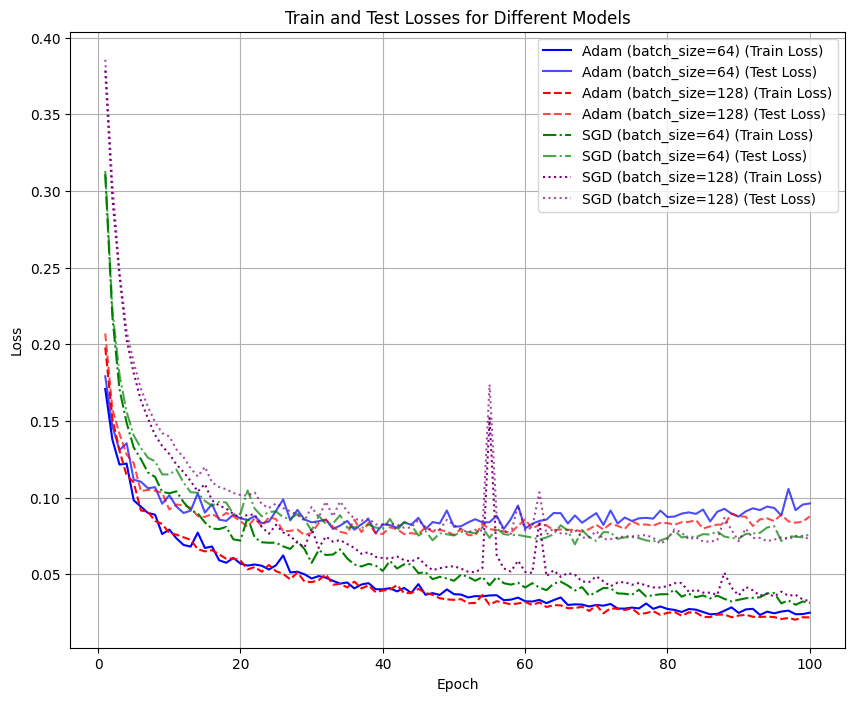

In [36]:
mlp3_mitbih_train_losses = [mlp3_mitbih_adam_64_train_losses, mlp3_mitbih_adam_128_train_losses, mlp3_mitbih_sgd_64_train_losses, mlp3_mitbih_sgd_128_train_losses]
mlp3_mitbih_test_losses = [mlp3_mitbih_adam_64_test_losses, mlp3_mitbih_adam_128_test_losses, mlp3_mitbih_sgd_64_test_losses, mlp3_mitbih_sgd_128_test_losses]
plot_losses(100, mlp3_mitbih_train_losses, mlp3_mitbih_test_losses)

##### 4 layers

Epoch 10/100
Train Loss: 0.12587582886863943, Train Accuracy: 0.964672826744943
Test Loss: 0.13725726494332097, Test Accuracy: 0.9624046411767393
------------------
Epoch 20/100
Train Loss: 0.1092347769778279, Train Accuracy: 0.9706235080465546
Test Loss: 0.12047391063628757, Test Accuracy: 0.967840665113517
------------------
Epoch 30/100
Train Loss: 0.09910208619471131, Train Accuracy: 0.9737416193619864
Test Loss: 0.11435832345957322, Test Accuracy: 0.9706271983920333
------------------
Epoch 40/100
Train Loss: 0.09133439957265592, Train Accuracy: 0.9752378559272669
Test Loss: 0.10886623297408006, Test Accuracy: 0.971951943721164
------------------
Epoch 50/100
Train Loss: 0.09010040520797868, Train Accuracy: 0.9749980012106952
Test Loss: 0.10788250482456525, Test Accuracy: 0.9713580923667261
------------------
Epoch 60/100
Train Loss: 0.08519005164717663, Train Accuracy: 0.9764713944696355
Test Loss: 0.10429774102844494, Test Accuracy: 0.9722260289616738
------------------
Epoch 70

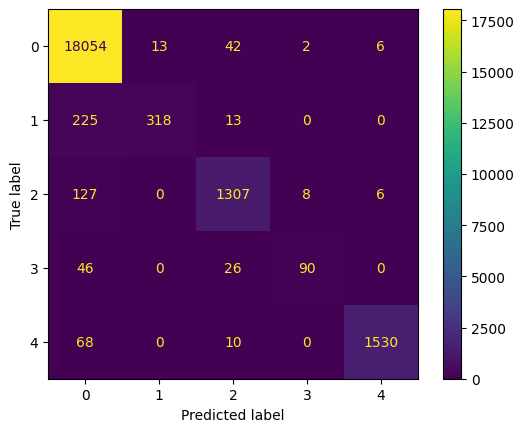

In [37]:
mlp4_mitbih_adam_64 = MLP4(5)
[mlp4_mitbih_adam_64_train_losses, mlp4_mitbih_adam_64_test_losses, mlp4_mitbih_adam_64_test_loader] = train_nn(mlp4_mitbih_adam_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 64)
test_nn(mlp4_mitbih_adam_64, crossEntropy, mlp4_mitbih_adam_64_test_loader)

Epoch 10/100
Train Loss: 0.15408269578087938, Train Accuracy: 0.9605724532568845
Test Loss: 0.1624236258050037, Test Accuracy: 0.9593440226577132
------------------
Epoch 20/100
Train Loss: 0.11997124612141047, Train Accuracy: 0.9659177869404818
Test Loss: 0.1325694254456023, Test Accuracy: 0.9629984925311772
------------------
Epoch 30/100
Train Loss: 0.1088985871985881, Train Accuracy: 0.9669914223384692
Test Loss: 0.12398144262193074, Test Accuracy: 0.9640491526197981
------------------
Epoch 40/100
Train Loss: 0.09607758301507383, Train Accuracy: 0.972530924125958
Test Loss: 0.11213267792752662, Test Accuracy: 0.9683888355945366
------------------
Epoch 50/100
Train Loss: 0.09586098484714502, Train Accuracy: 0.9730677418249517
Test Loss: 0.1206222853276792, Test Accuracy: 0.9685258782147914
------------------
Epoch 60/100
Train Loss: 0.08813014250838395, Train Accuracy: 0.9752835425399472
Test Loss: 0.11066417608323485, Test Accuracy: 0.9718605819743273
------------------
Epoch 70/

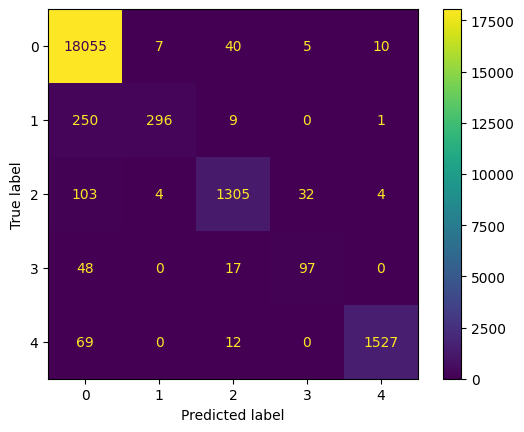

In [38]:
mlp4_mitbih_adam_128 = MLP4(5)
[mlp4_mitbih_adam_128_train_losses, mlp4_mitbih_adam_128_test_losses, mlp4_mitbih_adam_128_test_loader] = train_nn(mlp4_mitbih_adam_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 128)
test_nn(mlp4_mitbih_adam_128, crossEntropy, mlp4_mitbih_adam_128_test_loader)

Epoch 10/100
Train Loss: 0.19653992580659443, Train Accuracy: 0.9448905234543648
Test Loss: 0.20360599521753914, Test Accuracy: 0.9435384404549815
------------------
Epoch 20/100
Train Loss: 0.15099994446592468, Train Accuracy: 0.9603211768871427
Test Loss: 0.15761048426042493, Test Accuracy: 0.9596637887716413
------------------
Epoch 30/100
Train Loss: 0.12633647663325584, Train Accuracy: 0.9647984649298139
Test Loss: 0.13854830821503616, Test Accuracy: 0.9624046411767393
------------------
Epoch 40/100
Train Loss: 0.11826269692993724, Train Accuracy: 0.9635763480406154
Test Loss: 0.13253032124218458, Test Accuracy: 0.9620848750628112
------------------
Epoch 50/100
Train Loss: 0.10921901149418099, Train Accuracy: 0.9680079494706064
Test Loss: 0.12435250167270617, Test Accuracy: 0.9650084509615824
------------------
Epoch 60/100
Train Loss: 0.1123185167535335, Train Accuracy: 0.96566651057074
Test Loss: 0.12764899636504753, Test Accuracy: 0.9635009821387784
------------------
Epoch 7

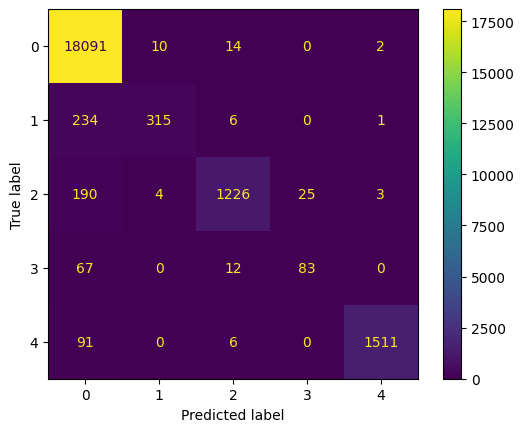

In [39]:
mlp4_mitbih_sgd_64 = MLP4(5)
[mlp4_mitbih_sgd_64_train_losses, mlp4_mitbih_sgd_64_test_losses, mlp4_mitbih_sgd_64_test_loader] = train_nn(mlp4_mitbih_sgd_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 64)
test_nn(mlp4_mitbih_sgd_64, crossEntropy, mlp4_mitbih_sgd_64_test_loader)

Epoch 10/100
Train Loss: 0.24289705106159196, Train Accuracy: 0.9420122668555047
Test Loss: 0.2489405207141021, Test Accuracy: 0.9417568863916678
------------------
Epoch 20/100
Train Loss: 0.1587371496660431, Train Accuracy: 0.959658721003278
Test Loss: 0.16651175726681602, Test Accuracy: 0.9571970216070531
------------------
Epoch 30/100
Train Loss: 0.13451806149669807, Train Accuracy: 0.9651639578312565
Test Loss: 0.14425372847810733, Test Accuracy: 0.9622219176830661
------------------
Epoch 40/100
Train Loss: 0.11611500139191855, Train Accuracy: 0.9686247187417907
Test Loss: 0.12667718863244667, Test Accuracy: 0.9652368553286739
------------------
Epoch 50/100
Train Loss: 0.6566431308314749, Train Accuracy: 0.8277386268888559
Test Loss: 0.6555288707794145, Test Accuracy: 0.8275547028459184
------------------
Epoch 60/100
Train Loss: 0.6562892420883596, Train Accuracy: 0.8277728918483661
Test Loss: 0.6551670226766619, Test Accuracy: 0.8277374263395916
------------------
Epoch 70/10

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Metrics
Accuracy: 0.828
Precision: [0.82763032 0.         0.5        0.         0.        ]
Recall: [9.99944803e-01 0.00000000e+00 6.90607735e-04 0.00000000e+00
 0.00000000e+00]
F1: [0.90566415 0.         0.00137931 0.         0.        ]


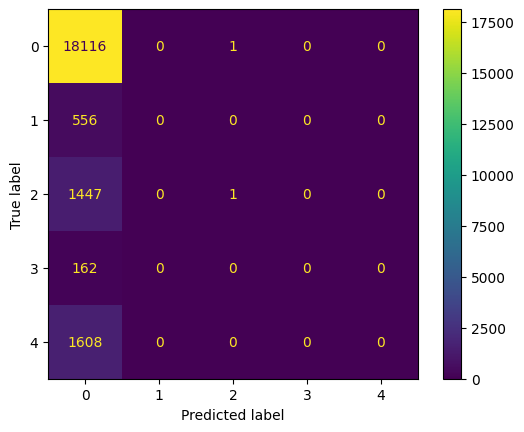

In [40]:
mlp4_mitbih_sgd_128 = MLP4(5)
[mlp4_mitbih_sgd_128_train_losses, mlp4_mitbih_sgd_128_test_losses, mlp4_mitbih_sgd_128_test_loader] = train_nn(mlp4_mitbih_sgd_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 128)
test_nn(mlp4_mitbih_sgd_128, crossEntropy, mlp4_mitbih_sgd_128_test_loader)

##### Plotting

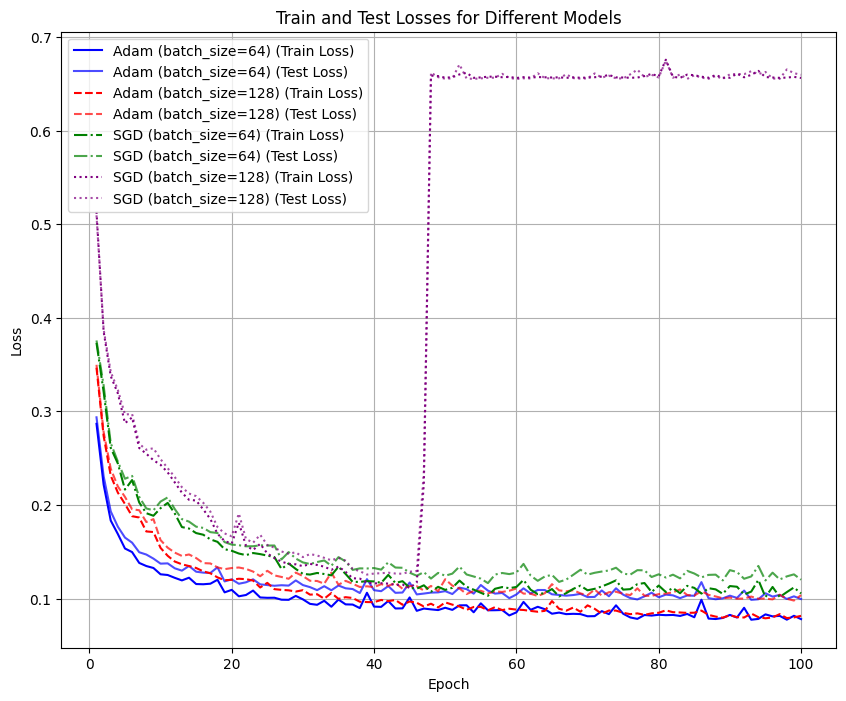

In [41]:
mlp4_mitbih_train_losses = [mlp4_mitbih_adam_64_train_losses, mlp4_mitbih_adam_128_train_losses, mlp4_mitbih_sgd_64_train_losses, mlp4_mitbih_sgd_128_train_losses]
mlp4_mitbih_test_losses = [mlp4_mitbih_adam_64_test_losses, mlp4_mitbih_adam_128_test_losses, mlp4_mitbih_sgd_64_test_losses, mlp4_mitbih_sgd_128_test_losses]
plot_losses(100, mlp4_mitbih_train_losses, mlp4_mitbih_test_losses)

#### PTB dataset

##### 3 layers

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.17924367845989764, Train Accuracy: 0.9266568483063329
Test Loss: 0.2057774306639381, Test Accuracy: 0.9182130584192439
------------------
Epoch 20/100
Train Loss: 0.11302454085671343, Train Accuracy: 0.9573883161512028
Test Loss: 0.1670867295368858, Test Accuracy: 0.9367697594501718
------------------
Epoch 30/100
Train Loss: 0.07426273874007165, Train Accuracy: 0.9709376534118802
Test Loss: 0.14547925045970234, Test Accuracy: 0.9514318442153493
------------------
Epoch 40/100
Train Loss: 0.052487499808194116, Train Accuracy: 0.9837015218458517
Test Loss: 0.1236696392601437, Test Accuracy: 0.9567010309278351
------------------
Epoch 50/100
Train Loss: 0.03696659658598946, Train Accuracy: 0.987432498772705
Test Loss: 0.13792278012935666, Test Accuracy: 0.9631156930126002
------------------
Epoch 60/100
Train Loss: 0.026186883894843048, Train Accuracy: 0.9914580265095729
Test Loss: 0.11892157799793758, Test Accuracy: 0.9676975945017182
------------------
Epoch 

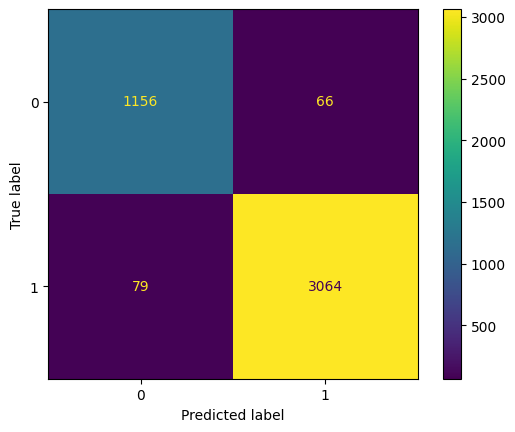

In [10]:
mlp3_ptb_adam_64 = MLP3(2)
[mlp3_ptb_adam_64_train_losses, mlp3_ptb_adam_64_test_losses, mlp3_ptb_adam_64_test_loader] = train_nn(mlp3_ptb_adam_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 64)
test_nn(mlp3_ptb_adam_64, crossEntropy, mlp3_ptb_adam_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.17434031823650004, Train Accuracy: 0.9343151693667158
Test Loss: 0.19403261031423297, Test Accuracy: 0.92737686139748
------------------
Epoch 20/100
Train Loss: 0.09608178716152907, Train Accuracy: 0.9671084928816888
Test Loss: 0.14581174914325987, Test Accuracy: 0.9489117983963344
------------------
Epoch 30/100
Train Loss: 0.06755740633234382, Train Accuracy: 0.9786941580756013
Test Loss: 0.13719450400343963, Test Accuracy: 0.9562428407789233
------------------
Epoch 40/100
Train Loss: 0.05140660863835365, Train Accuracy: 0.9825233186057928
Test Loss: 0.1282239066702979, Test Accuracy: 0.9594501718213059
------------------
Epoch 50/100
Train Loss: 0.030543424806091936, Train Accuracy: 0.9909671084928817
Test Loss: 0.11739748695066997, Test Accuracy: 0.96815578465063
------------------
Epoch 60/100
Train Loss: 0.031084037956316025, Train Accuracy: 0.9903780068728523
Test Loss: 0.12719815570328916, Test Accuracy: 0.9686139747995418
------------------
Epoch 7

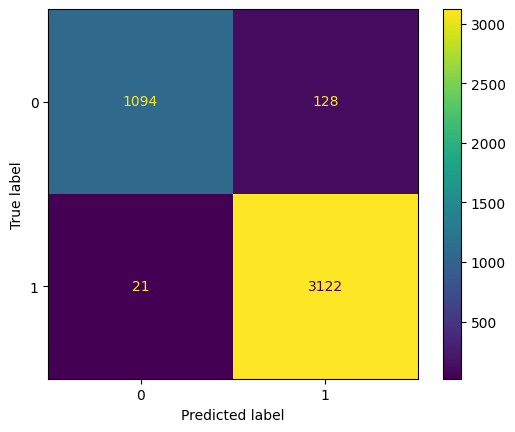

In [11]:
mlp3_ptb_adam_128 = MLP3(2)
[mlp3_ptb_adam_128_train_losses, mlp3_ptb_adam_128_test_losses, mlp3_ptb_adam_128_test_loader] = train_nn(mlp3_ptb_adam_128, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 128)
test_nn(mlp3_ptb_adam_128, crossEntropy, mlp3_ptb_adam_128_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.29133473746478555, Train Accuracy: 0.8864997545409916
Test Loss: 0.2935102346582689, Test Accuracy: 0.8822451317296678
------------------
Epoch 20/100
Train Loss: 0.1851722316350788, Train Accuracy: 0.9309769268532155
Test Loss: 0.2066168573455534, Test Accuracy: 0.9223367697594502
------------------
Epoch 30/100
Train Loss: 0.1791910097002983, Train Accuracy: 0.9284241531664212
Test Loss: 0.2053204504907995, Test Accuracy: 0.9108820160366552
------------------
Epoch 40/100
Train Loss: 0.16953787207603455, Train Accuracy: 0.9228276877761414
Test Loss: 0.2049281657066034, Test Accuracy: 0.913631156930126
------------------
Epoch 50/100
Train Loss: 0.10665624549146742, Train Accuracy: 0.9641629847815415
Test Loss: 0.14622829454964487, Test Accuracy: 0.9486827033218785
------------------
Epoch 60/100
Train Loss: 0.09045402343617752, Train Accuracy: 0.9661266568483063
Test Loss: 0.13760798446078232, Test Accuracy: 0.9523482245131729
------------------
Epoch 70/10

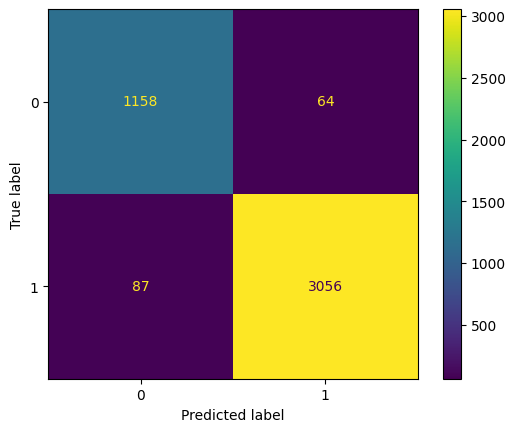

In [12]:
mlp3_ptb_sgd_64 = MLP3(2)
[mlp3_ptb_sgd_64_train_losses, mlp3_ptb_sgd_64_test_losses, mlp3_ptb_sgd_64_test_loader] = train_nn(mlp3_ptb_sgd_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "sgd", 100, 64)
test_nn(mlp3_ptb_sgd_64, crossEntropy, mlp3_ptb_sgd_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.3635598562657833, Train Accuracy: 0.8305351006381935
Test Loss: 0.3669854496206556, Test Accuracy: 0.8263459335624284
------------------
Epoch 20/100
Train Loss: 0.26142440661787986, Train Accuracy: 0.9009327442317133
Test Loss: 0.2670844307967595, Test Accuracy: 0.8964490263459336
------------------
Epoch 30/100
Train Loss: 0.18255409011617302, Train Accuracy: 0.9337260677466863
Test Loss: 0.20382604066814694, Test Accuracy: 0.9248568155784651
------------------
Epoch 40/100
Train Loss: 0.14718071399256588, Train Accuracy: 0.9431516936671576
Test Loss: 0.17823059495006288, Test Accuracy: 0.9310423825887744
------------------
Epoch 50/100
Train Loss: 0.12207633964717388, Train Accuracy: 0.9555228276877762
Test Loss: 0.15700446484344346, Test Accuracy: 0.9427262313860252
------------------
Epoch 60/100
Train Loss: 0.08556928890757262, Train Accuracy: 0.9742758959253804
Test Loss: 0.13271245371018137, Test Accuracy: 0.9544100801832761
------------------
Epoch 7

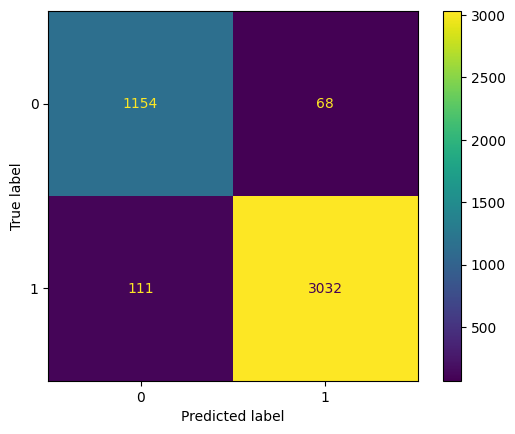

In [13]:
mlp3_ptb_sgd_128 = MLP3(2)
[mlp3_ptb_sgd_128_train_losses, mlp3_ptb_sgd_128_test_losses, mlp3_ptb_sgd_128_test_loader] = train_nn(mlp3_ptb_sgd_128, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "sgd", 100, 128)
test_nn(mlp3_ptb_sgd_128, crossEntropy, mlp3_ptb_sgd_128_test_loader)

##### Plotting

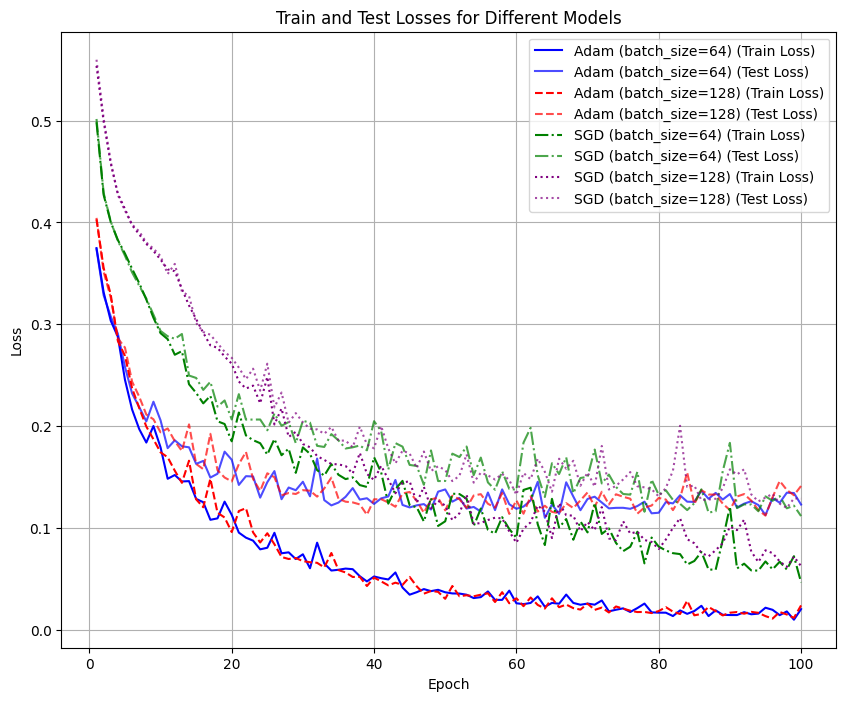

In [14]:
mlp3_ptb_train_losses = [mlp3_ptb_adam_64_train_losses, mlp3_ptb_adam_128_train_losses, mlp3_ptb_sgd_64_train_losses, mlp3_ptb_sgd_128_train_losses]
mlp3_ptb_test_losses = [mlp3_ptb_adam_64_test_losses, mlp3_ptb_adam_128_test_losses, mlp3_ptb_sgd_64_test_losses, mlp3_ptb_sgd_128_test_losses]
plot_losses(100, mlp3_ptb_train_losses, mlp3_ptb_test_losses)

##### 4 layers

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.24085124814882874, Train Accuracy: 0.9115365733922435
Test Loss: 0.2547570166812427, Test Accuracy: 0.8998854524627721
------------------
Epoch 20/100
Train Loss: 0.16278055587317794, Train Accuracy: 0.9421698576337751
Test Loss: 0.19321065320484881, Test Accuracy: 0.9282932416953036
------------------
Epoch 30/100
Train Loss: 0.13361924013588578, Train Accuracy: 0.9529700540009818
Test Loss: 0.17134912922114565, Test Accuracy: 0.9369988545246277
------------------
Epoch 40/100
Train Loss: 0.12494467198848724, Train Accuracy: 0.9573883161512028
Test Loss: 0.17621426991578462, Test Accuracy: 0.9374570446735395
------------------
Epoch 50/100
Train Loss: 0.10687642588745802, Train Accuracy: 0.9638684339715268
Test Loss: 0.1634264976542065, Test Accuracy: 0.940893470790378
------------------
Epoch 60/100
Train Loss: 0.09948029991937801, Train Accuracy: 0.9674030436917035
Test Loss: 0.1605668247717878, Test Accuracy: 0.9486827033218785
------------------
Epoch 70

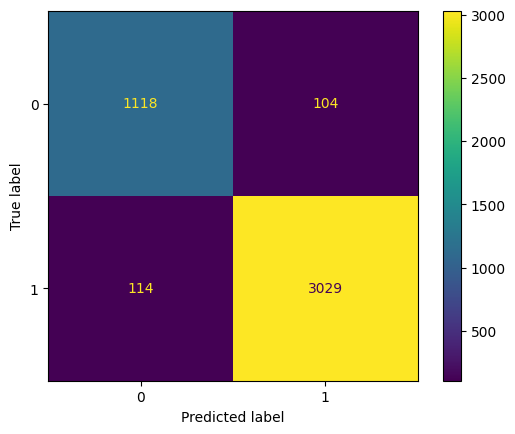

In [15]:
mlp4_ptb_adam_64 = MLP4(2)
[mlp4_ptb_adam_64_train_losses, mlp4_ptb_adam_64_test_losses, mlp4_ptb_adam_64_test_loader] = train_nn(mlp4_ptb_adam_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 64)
test_nn(mlp4_ptb_adam_64, crossEntropy, mlp4_ptb_adam_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.25779206305742264, Train Accuracy: 0.899165439371625
Test Loss: 0.25808125436306, Test Accuracy: 0.899165439371625
------------------
Epoch 20/100
Train Loss: 0.18397345980629326, Train Accuracy: 0.9332351497299951
Test Loss: 0.18368702735751868, Test Accuracy: 0.9332351497299951
------------------
Epoch 30/100
Train Loss: 0.15620931992307305, Train Accuracy: 0.9403043691703485
Test Loss: 0.15580027839168906, Test Accuracy: 0.9403043691703485
------------------
Epoch 40/100
Train Loss: 0.13463941644877195, Train Accuracy: 0.9513991163475699
Test Loss: 0.13428689879365266, Test Accuracy: 0.9513991163475699
------------------
Epoch 50/100
Train Loss: 0.11982226609252393, Train Accuracy: 0.9616102110947472
Test Loss: 0.11981965587474405, Test Accuracy: 0.9616102110947472
------------------
Epoch 60/100
Train Loss: 0.10696260160766542, Train Accuracy: 0.9664212076583211
Test Loss: 0.10598167274147272, Test Accuracy: 0.9664212076583211
------------------
Epoch 70/

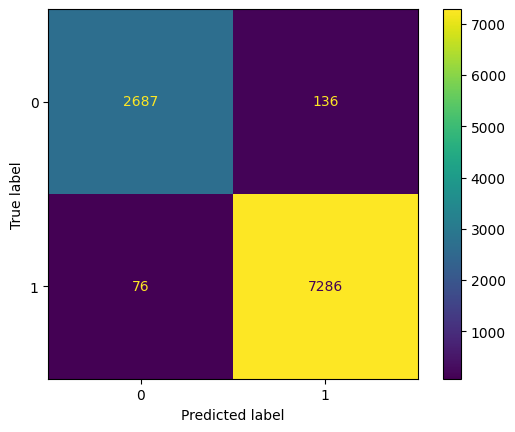

In [16]:
mlp4_ptb_adam_128 = MLP4(2)
[mlp4_ptb_adam_128_train_losses, mlp4_ptb_adam_128_test_losses, mlp4_ptb_adam_128_test_loader] = train_nn(mlp4_ptb_adam_128, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "adam", 100, 128)
test_nn(mlp4_ptb_adam_128, crossEntropy, mlp4_ptb_adam_128_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.3318306228145957, Train Accuracy: 0.8611683848797251
Test Loss: 0.3298786333296448, Test Accuracy: 0.8611683848797251
------------------
Epoch 20/100
Train Loss: 0.27019928973168134, Train Accuracy: 0.8809032891507118
Test Loss: 0.27063467968255284, Test Accuracy: 0.8809032891507118
------------------
Epoch 30/100
Train Loss: 0.22055560667067767, Train Accuracy: 0.9143838978890525
Test Loss: 0.22099508540704846, Test Accuracy: 0.9143838978890525
------------------
Epoch 40/100
Train Loss: 0.19401377458125352, Train Accuracy: 0.9201767304860088
Test Loss: 0.1947176772169769, Test Accuracy: 0.9201767304860088
------------------
Epoch 50/100
Train Loss: 0.17558546913787723, Train Accuracy: 0.9329405989199804
Test Loss: 0.17584159448742867, Test Accuracy: 0.9329405989199804
------------------
Epoch 60/100
Train Loss: 0.16061890446580945, Train Accuracy: 0.9405989199803633
Test Loss: 0.1597571613965556, Test Accuracy: 0.9405989199803633
------------------
Epoch 70

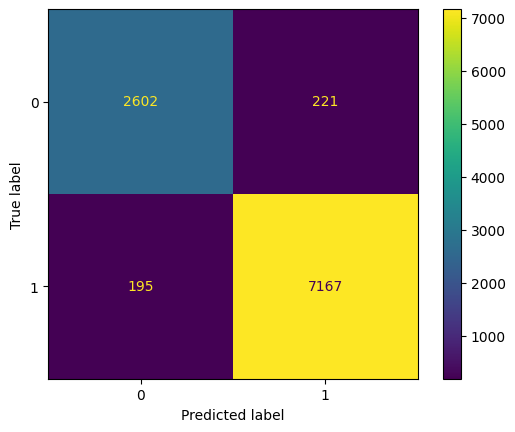

In [17]:
mlp4_ptb_sgd_64 = MLP4(2)
[mlp4_ptb_sgd_64_train_losses, mlp4_ptb_sgd_64_test_losses, mlp4_ptb_sgd_64_test_loader] = train_nn(mlp4_ptb_sgd_64, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "sgd", 100, 64)
test_nn(mlp4_ptb_sgd_64, crossEntropy, mlp4_ptb_sgd_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.38837948590517046, Train Accuracy: 0.8070692194403535
Test Loss: 0.3870881777256727, Test Accuracy: 0.8070692194403535
------------------
Epoch 20/100
Train Loss: 0.25417140424251555, Train Accuracy: 0.9128129602356406
Test Loss: 0.25383327826857566, Test Accuracy: 0.9128129602356406
------------------
Epoch 30/100
Train Loss: 0.25749803297221663, Train Accuracy: 0.8889543446244477
Test Loss: 0.2563698565587401, Test Accuracy: 0.8889543446244477
------------------
Epoch 40/100
Train Loss: 0.2400018310174346, Train Accuracy: 0.8907216494845361
Test Loss: 0.2397790662944317, Test Accuracy: 0.8907216494845361
------------------
Epoch 50/100
Train Loss: 0.25806743577122687, Train Accuracy: 0.8814923907707413
Test Loss: 0.2587791130878031, Test Accuracy: 0.8814923907707413
------------------
Epoch 60/100
Train Loss: 0.1833105650730431, Train Accuracy: 0.9297987236131566
Test Loss: 0.18333252305164932, Test Accuracy: 0.9297987236131566
------------------
Epoch 70/1

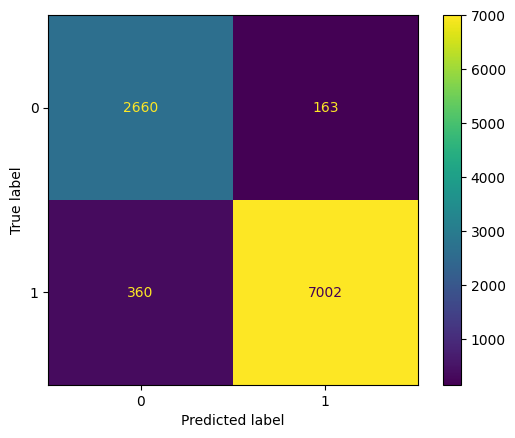

In [18]:
mlp4_ptb_sgd_128 = MLP4(2)
[mlp4_ptb_sgd_128_train_losses, mlp4_ptb_sgd_128_test_losses, mlp4_ptb_sgd_128_test_loader] = train_nn(mlp4_ptb_sgd_128, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "sgd", 100, 128)
test_nn(mlp4_ptb_sgd_128, crossEntropy, mlp4_ptb_sgd_128_test_loader)

##### Plotting

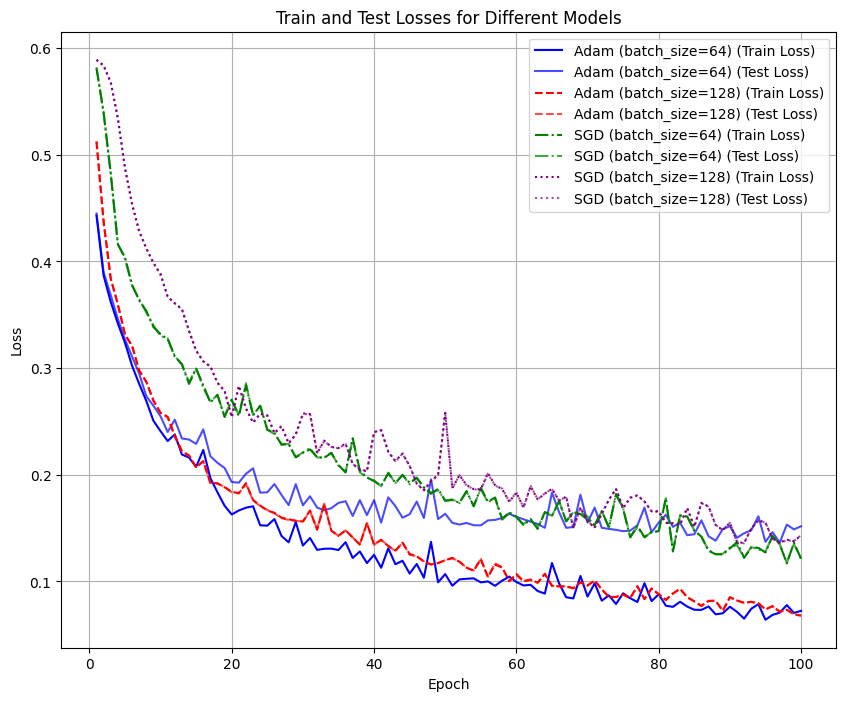

In [19]:
mlp4_ptb_train_losses = [mlp4_ptb_adam_64_train_losses, mlp4_ptb_adam_128_train_losses, mlp4_ptb_sgd_64_train_losses, mlp4_ptb_sgd_128_train_losses]
mlp4_ptb_test_losses = [mlp4_ptb_adam_64_test_losses, mlp4_ptb_adam_128_test_losses, mlp4_ptb_sgd_64_test_losses, mlp4_ptb_sgd_128_test_losses]
plot_losses(100, mlp4_ptb_train_losses, mlp4_ptb_test_losses)

### CNN

#### Architecture

In [9]:
class CNN33(nn.Module):
    def __init__(self,  output_size):
        super(CNN33, self).__init__()
        # 187 (initial) * 80 // 100 (feature selection) = 149
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=64, kernel_size=5, stride=2, padding=1)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 512)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.relu(self.conv2(out))
        out = self.relu(self.conv3(out))
        out = self.global_avg_pool(out).squeeze(2)
        out = self.dropout1(self.relu(self.fc1(out)))
        out = self.dropout2(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

class CNN44(nn.Module):
    def __init__(self, output_size):
        super(CNN44, self).__init__()
        # 189 (initial) * 80 // 100 (feature selection) = 149
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=2, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=2, padding=1)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(256, 81)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(81, 27)
        self.dropout2 = nn.Dropout(0.25)
        self.fc3 = nn.Linear(27, 9)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(9, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.conv1(x))
        out = self.relu(self.conv2(out))
        out = self.relu(self.conv3(out))
        out = self.relu(self.conv4(out))
        out = self.global_avg_pool(out).squeeze(2)
        out = self.dropout1(self.relu(self.fc1(out)))
        out = self.dropout2(self.relu(self.fc2(out)))
        out = self.dropout3(self.relu(self.fc3(out)))
        out = self.fc4(out)
        return out

In [ ]:
# PLAYGROUND

# X_train = X_mitbih_train.to_numpy()
# shape = X_train.shape
# X_train = X_train.reshape(-1, 1, shape[1])
# X_tensor = torch.tensor(X_train, dtype=torch.float32)

# conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=2)
# conv2 = nn.Conv1d(in_channels=16, out_channels=64, kernel_size=5, stride=2, padding=1)
# conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=2)
# global_avg_pool = nn.AdaptiveAvgPool1d(1)
# fc1 = nn.Linear(128, 512)

# print(X_tensor.shape)

# X_tensor = conv1(X_tensor)
# print(X_tensor.shape)

# X_tensor = conv2(X_tensor)
# print(X_tensor.shape)

# X_tensor = conv3(X_tensor)
# print(X_tensor.shape)

# X_tensor = global_avg_pool(X_tensor).squeeze(2)
# print(X_tensor.shape)

# X_tensor = fc1(X_tensor)
# print(X_tensor.shape)



#### MITBIH dataset

##### 3 layers

Epoch 10/100
Train Loss: 0.0705598447624243, Train Accuracy: 0.9804232864664831
Test Loss: 0.09189438956189608, Test Accuracy: 0.9756520944680462
------------------
Epoch 20/100
Train Loss: 0.04909585075829807, Train Accuracy: 0.9852889107169371
Test Loss: 0.0803360754317528, Test Accuracy: 0.9789411173541638
------------------
Epoch 30/100
Train Loss: 0.031215109661360284, Train Accuracy: 0.98998321016984
Test Loss: 0.07737606926990874, Test Accuracy: 0.9815449271390069
------------------
Epoch 40/100
Train Loss: 0.026377531507249214, Train Accuracy: 0.9906570877068747
Test Loss: 0.09011287867465279, Test Accuracy: 0.9822301402402814
------------------
Epoch 50/100
Train Loss: 0.018519407136442644, Train Accuracy: 0.9938094639818167
Test Loss: 0.09407872627853385, Test Accuracy: 0.9819560549997716
------------------
Epoch 60/100
Train Loss: 0.021143695803669874, Train Accuracy: 0.9926101903989584
Test Loss: 0.10479527912795022, Test Accuracy: 0.9805856287972226
------------------
Epoc

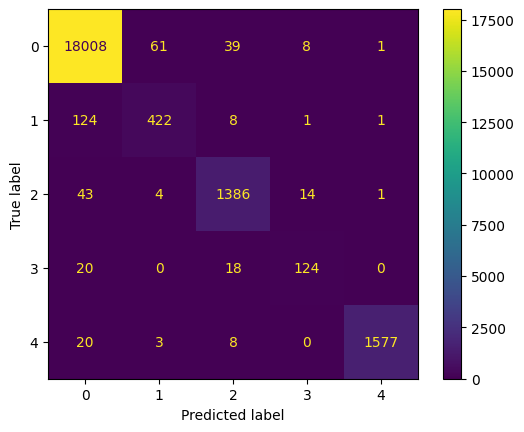

In [10]:
cnn33_mitbih_adam_64 = CNN33(5)
[cnn33_mitbih_adam_64_train_losses, cnn33_mitbih_adam_64_test_losses, cnn33_mitbih_adam_64_test_loader] = train_nn(cnn33_mitbih_adam_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 64, "cnn")
test_nn(cnn33_mitbih_adam_64, crossEntropy, cnn33_mitbih_adam_64_test_loader)

Epoch 10/100
Train Loss: 0.1039174594474535, Train Accuracy: 0.9702009068792617
Test Loss: 0.12506965996675887, Test Accuracy: 0.9661961536704582
------------------
Epoch 20/100
Train Loss: 0.0659396301577697, Train Accuracy: 0.9807545144084154
Test Loss: 0.08775308908234576, Test Accuracy: 0.9761545840756475
------------------
Epoch 30/100
Train Loss: 0.05574696444546533, Train Accuracy: 0.9822735942800361
Test Loss: 0.08763568803835876, Test Accuracy: 0.9777077337718697
------------------
Epoch 40/100
Train Loss: 0.03870151901790145, Train Accuracy: 0.9881785889689674
Test Loss: 0.07605801308311003, Test Accuracy: 0.9807226714174775
------------------
Epoch 50/100
Train Loss: 0.03169327823382904, Train Accuracy: 0.989697668840588
Test Loss: 0.07828565213428594, Test Accuracy: 0.9814992462655886
------------------
Epoch 60/100
Train Loss: 0.025855048895529604, Train Accuracy: 0.9909540506892968
Test Loss: 0.07897879361891239, Test Accuracy: 0.9833264812023206
------------------
Epoch 

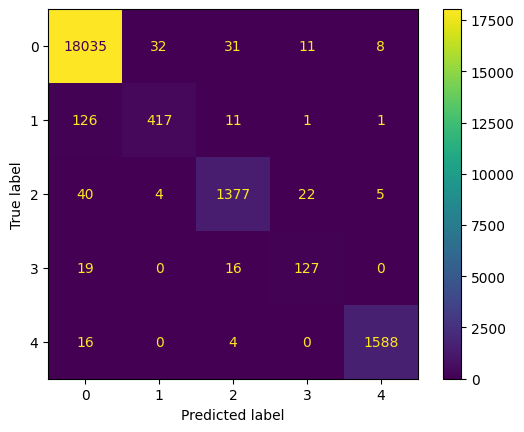

In [11]:
cnn33_mitbih_adam_128 = CNN33(5)
[cnn33_mitbih_adam_128_train_losses, cnn33_mitbih_adam_128_test_losses, cnn33_mitbih_adam_128_test_loader] = train_nn(cnn33_mitbih_adam_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 128, "cnn")
test_nn(cnn33_mitbih_adam_128, crossEntropy, cnn33_mitbih_adam_128_test_loader)

Epoch 10/100
Train Loss: 0.21782928676575075, Train Accuracy: 0.9408815231916667
Test Loss: 0.2258464901737934, Test Accuracy: 0.9390617148599881
------------------
Epoch 20/100
Train Loss: 0.09719228884375296, Train Accuracy: 0.9739472091190479
Test Loss: 0.10940195174762876, Test Accuracy: 0.9711296879996345
------------------
Epoch 30/100
Train Loss: 0.06610864647283166, Train Accuracy: 0.9808573092869461
Test Loss: 0.08799430870711694, Test Accuracy: 0.9766113928098306
------------------
Epoch 40/100
Train Loss: 0.047591830007156645, Train Accuracy: 0.9857229335374003
Test Loss: 0.07769955267926744, Test Accuracy: 0.980494267050386
------------------
Epoch 50/100
Train Loss: 0.0403113725791271, Train Accuracy: 0.9868650988544082
Test Loss: 0.07309791345132988, Test Accuracy: 0.9812251610250788
------------------
Epoch 60/100
Train Loss: 0.08950482456437384, Train Accuracy: 0.9678594679793954
Test Loss: 0.12817609180090814, Test Accuracy: 0.9604403636197524
------------------
Epoch 

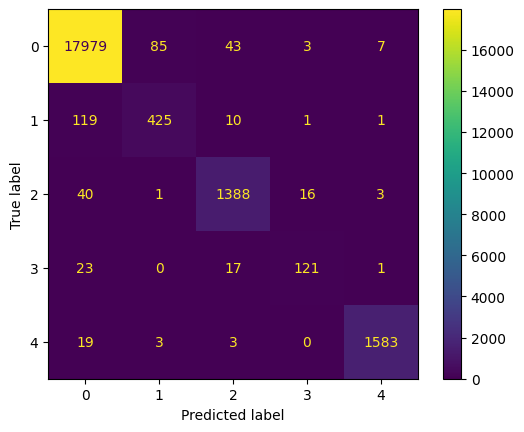

In [12]:
cnn33_mitbih_sgd_64 = CNN33(5)
[cnn33_mitbih_sgd_64_train_losses, cnn33_mitbih_sgd_64_test_losses, cnn33_mitbih_sgd_64_test_loader] = train_nn(cnn33_mitbih_sgd_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 64, "cnn")
test_nn(cnn33_mitbih_sgd_64, crossEntropy, cnn33_mitbih_sgd_64_test_loader)

Epoch 10/100
Train Loss: 0.33439350281536145, Train Accuracy: 0.9044921361917924
Test Loss: 0.3415627464608744, Test Accuracy: 0.9025626969987666
------------------
Epoch 20/100
Train Loss: 0.13421095583696652, Train Accuracy: 0.9636448779596358
Test Loss: 0.14702307239992457, Test Accuracy: 0.9615367045817916
------------------
Epoch 30/100
Train Loss: 0.0731679253769617, Train Accuracy: 0.9790070014733933
Test Loss: 0.0910417168606939, Test Accuracy: 0.9759718605819744
------------------
Epoch 40/100
Train Loss: 0.06181568852982681, Train Accuracy: 0.9814626569049604
Test Loss: 0.08491568486910141, Test Accuracy: 0.976976839797177
------------------
Epoch 50/100
Train Loss: 0.057383960200113375, Train Accuracy: 0.9828789418980504
Test Loss: 0.08778798338252547, Test Accuracy: 0.9784386277465625
------------------
Epoch 60/100
Train Loss: 0.04861201167758384, Train Accuracy: 0.9843751784633308
Test Loss: 0.08532517006063055, Test Accuracy: 0.9776163720250332
------------------
Epoch 7

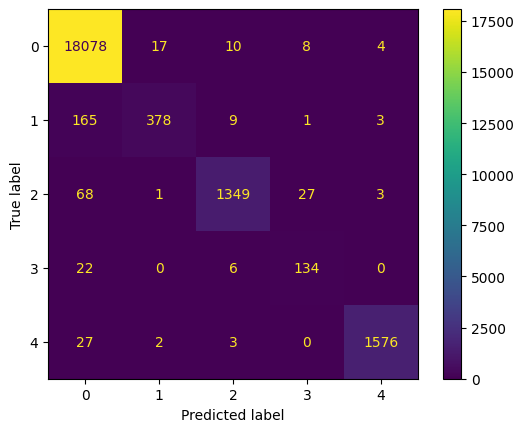

In [13]:
cnn33_mitbih_sgd_128 = CNN33(5)
[cnn33_mitbih_sgd_128_train_losses, cnn33_mitbih_sgd_128_test_losses, cnn33_mitbih_sgd_128_test_loader] = train_nn(cnn33_mitbih_sgd_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 128, "cnn")
test_nn(cnn33_mitbih_sgd_128, crossEntropy, cnn33_mitbih_sgd_128_test_loader)

##### Plotting

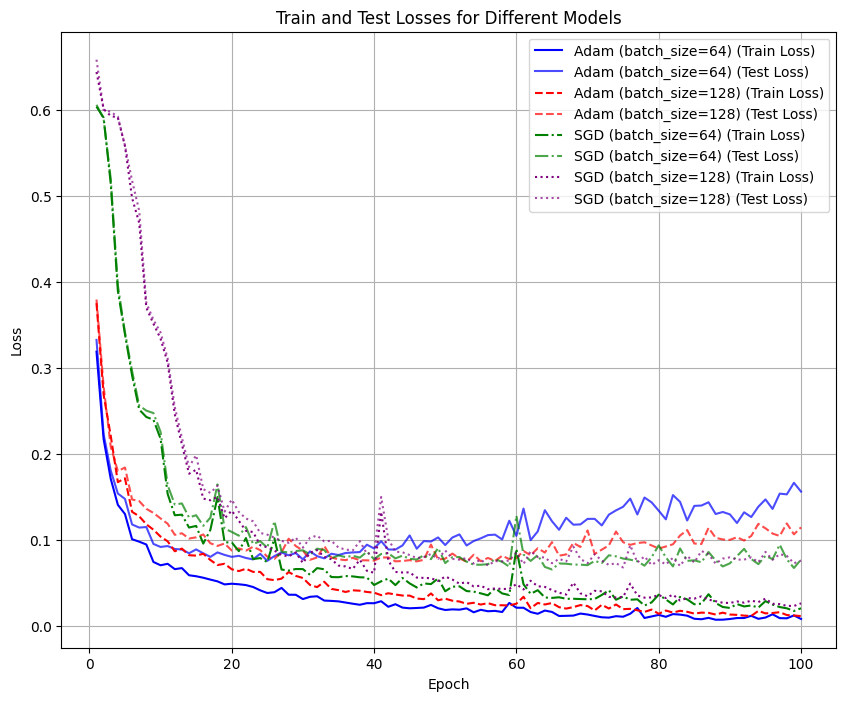

In [14]:
cnn33_mitbih_train_losses = [cnn33_mitbih_adam_64_train_losses, cnn33_mitbih_adam_128_train_losses, cnn33_mitbih_sgd_64_train_losses, cnn33_mitbih_sgd_128_train_losses]
cnn33_mitbih_test_losses = [cnn33_mitbih_adam_64_test_losses, cnn33_mitbih_adam_128_test_losses, cnn33_mitbih_sgd_64_test_losses, cnn33_mitbih_sgd_128_test_losses]
plot_losses(100, cnn33_mitbih_train_losses, cnn33_mitbih_test_losses)

##### 4 layers

Epoch 10/100
Train Loss: 0.1219071770999398, Train Accuracy: 0.9663175448014346
Test Loss: 0.14009955248988232, Test Accuracy: 0.9644602804805628
------------------
Epoch 20/100
Train Loss: 0.08244709530403094, Train Accuracy: 0.9802748049752721
Test Loss: 0.1102955182118249, Test Accuracy: 0.9747384769996802
------------------
Epoch 30/100
Train Loss: 0.06046446114628854, Train Accuracy: 0.9840896371340788
Test Loss: 0.09695254671781083, Test Accuracy: 0.9770682015440135
------------------
Epoch 40/100
Train Loss: 0.04441970437911385, Train Accuracy: 0.9880301074777563
Test Loss: 0.09068375632354213, Test Accuracy: 0.9790781599744187
------------------
Epoch 50/100
Train Loss: 0.0458644223177727, Train Accuracy: 0.98711637522415
Test Loss: 0.10516523957658429, Test Accuracy: 0.9779361381389612
------------------
Epoch 60/100
Train Loss: 0.030831391579921204, Train Accuracy: 0.9907484609322353
Test Loss: 0.09277340006755269, Test Accuracy: 0.9815449271390069
------------------
Epoch 70

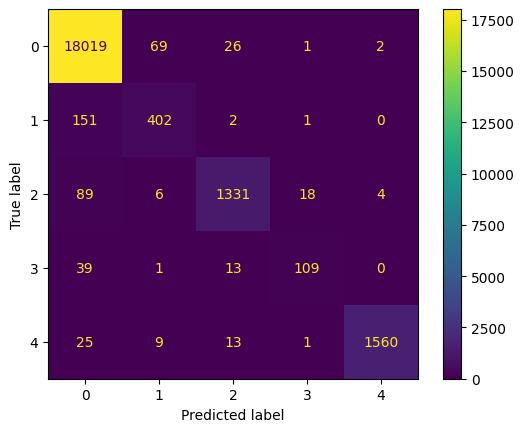

In [15]:
cnn44_mitbih_adam_64 = CNN44(5)
[cnn44_mitbih_adam_64_train_losses, cnn44_mitbih_adam_64_test_losses, cnn44_mitbih_adam_64_test_loader] = train_nn(cnn44_mitbih_adam_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 64, "cnn")
test_nn(cnn44_mitbih_adam_64, crossEntropy, cnn44_mitbih_adam_64_test_loader)

Epoch 10/100
Train Loss: 0.15052867557336813, Train Accuracy: 0.9522003814832158
Test Loss: 0.1648046545938827, Test Accuracy: 0.9507560184550728
------------------
Epoch 20/100
Train Loss: 0.1051278281712184, Train Accuracy: 0.9697097757929483
Test Loss: 0.1274680933552296, Test Accuracy: 0.9672011328856608
------------------
Epoch 30/100
Train Loss: 0.1265599034169, Train Accuracy: 0.966808675887748
Test Loss: 0.16156105963776543, Test Accuracy: 0.9629071307843406
------------------
Epoch 40/100
Train Loss: 0.08312191836751873, Train Accuracy: 0.9723938642879171
Test Loss: 0.12901495861127799, Test Accuracy: 0.9696679000502489
------------------
Epoch 50/100
Train Loss: 0.06211910543106768, Train Accuracy: 0.9797151439699382
Test Loss: 0.10606612182227552, Test Accuracy: 0.9736878169110593
------------------
Epoch 60/100
Train Loss: 0.05265948209405136, Train Accuracy: 0.9833814946375339
Test Loss: 0.12737658196047685, Test Accuracy: 0.9764743501895756
------------------
Epoch 70/100

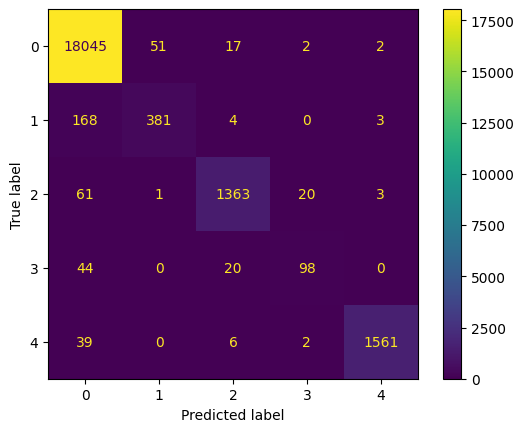

In [16]:
cnn44_mitbih_adam_128 = CNN44(5)
[cnn44_mitbih_adam_128_train_losses, cnn44_mitbih_adam_128_test_losses, cnn44_mitbih_adam_128_test_loader] = train_nn(cnn44_mitbih_adam_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 128, "cnn")
test_nn(cnn44_mitbih_adam_128, crossEntropy, cnn44_mitbih_adam_128_test_loader)

Epoch 10/100
Train Loss: 0.35654947480052124, Train Accuracy: 0.8967596769956484
Test Loss: 0.36105974963472465, Test Accuracy: 0.896532821707551
------------------
Epoch 20/100
Train Loss: 0.27861308011139957, Train Accuracy: 0.8974563978390232
Test Loss: 0.2871358794901444, Test Accuracy: 0.8967155452012242
------------------
Epoch 30/100
Train Loss: 0.12399044122827192, Train Accuracy: 0.9694927643827168
Test Loss: 0.1441125295399186, Test Accuracy: 0.96587638755653
------------------
Epoch 40/100
Train Loss: 0.11397497460227038, Train Accuracy: 0.9720055280801343
Test Loss: 0.12929664623214926, Test Accuracy: 0.9698049426705039
------------------
Epoch 50/100
Train Loss: 0.07782577852316479, Train Accuracy: 0.98139412698594
Test Loss: 0.09903115876095027, Test Accuracy: 0.977296605911105
------------------
Epoch 60/100
Train Loss: 0.07107370546552944, Train Accuracy: 0.9826048222219684
Test Loss: 0.09654273133203604, Test Accuracy: 0.9784386277465625
------------------
Epoch 70/100

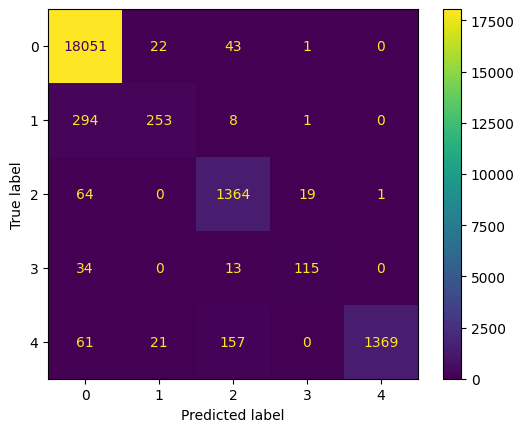

In [17]:
cnn44_mitbih_sgd_64 = CNN44(5)
[cnn44_mitbih_sgd_64_train_losses, cnn44_mitbih_sgd_64_test_losses, cnn44_mitbih_sgd_64_test_loader] = train_nn(cnn44_mitbih_sgd_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 64, "cnn")
test_nn(cnn44_mitbih_sgd_64, crossEntropy, cnn44_mitbih_sgd_64_test_loader)

Epoch 10/100
Train Loss: 0.6565178191792356, Train Accuracy: 0.8277272052356858
Test Loss: 0.6595642830050269, Test Accuracy: 0.8276003837193368
------------------
Epoch 20/100
Train Loss: 0.6564922789152521, Train Accuracy: 0.8277272052356858
Test Loss: 0.6597669070889783, Test Accuracy: 0.8276003837193368
------------------
Epoch 30/100
Train Loss: 0.371217494441645, Train Accuracy: 0.8942469132982308
Test Loss: 0.37765862662778343, Test Accuracy: 0.8928326709606688
------------------
Epoch 40/100
Train Loss: 0.18399210129014767, Train Accuracy: 0.9550101081630555
Test Loss: 0.19430906484769875, Test Accuracy: 0.954136403088027
------------------
Epoch 50/100
Train Loss: 0.11550957457753863, Train Accuracy: 0.9700752686943909
Test Loss: 0.13977584360318995, Test Accuracy: 0.9666529624046412
------------------
Epoch 60/100
Train Loss: 0.08578067620821896, Train Accuracy: 0.9799207337269996
Test Loss: 0.10310947708785534, Test Accuracy: 0.9756977753414645
------------------
Epoch 70/10

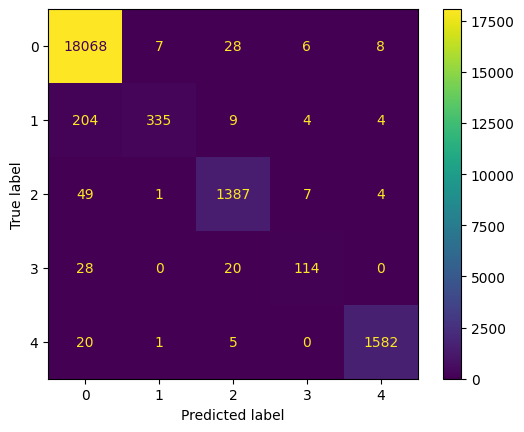

In [18]:
cnn44_mitbih_sgd_128 = CNN44(5)
[cnn44_mitbih_sgd_128_train_losses, cnn44_mitbih_sgd_128_test_losses, cnn44_mitbih_sgd_128_test_loader] = train_nn(cnn44_mitbih_sgd_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 128, "cnn")
test_nn(cnn44_mitbih_sgd_128, crossEntropy, cnn44_mitbih_sgd_128_test_loader)

##### Plotting

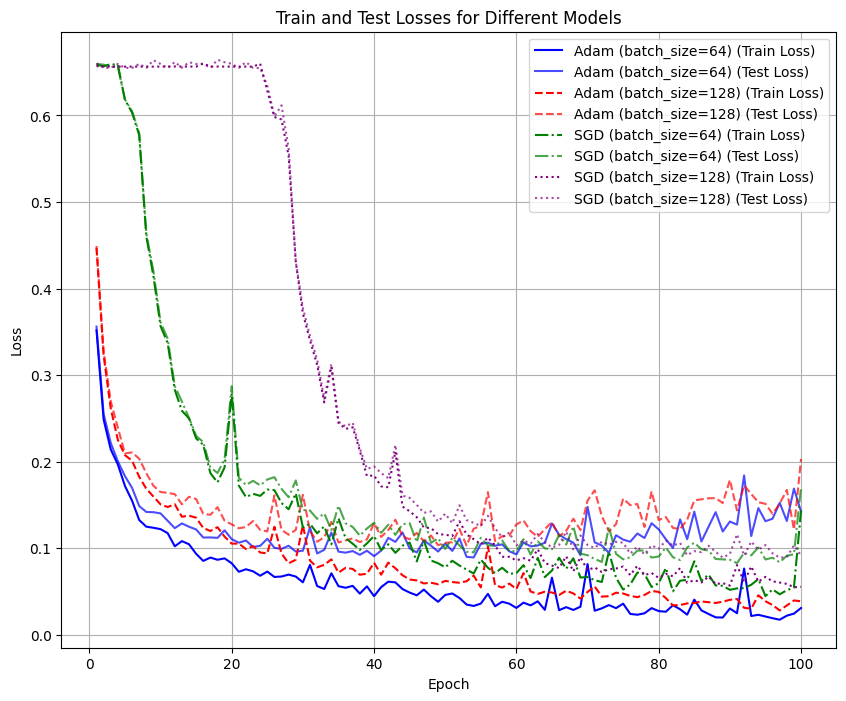

In [19]:
cnn44_mitbih_train_losses = [cnn44_mitbih_adam_64_train_losses, cnn44_mitbih_adam_128_train_losses, cnn44_mitbih_sgd_64_train_losses, cnn44_mitbih_sgd_128_train_losses]
cnn44_mitbih_test_losses = [cnn44_mitbih_adam_64_test_losses, cnn44_mitbih_adam_128_test_losses, cnn44_mitbih_sgd_64_test_losses, cnn44_mitbih_sgd_128_test_losses]
plot_losses(100, cnn44_mitbih_train_losses, cnn44_mitbih_test_losses)

#### PTB dataset

##### 3 layers

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.2630441126879305, Train Accuracy: 0.893078055964654
Test Loss: 0.2729016099719034, Test Accuracy: 0.8895761741122565
------------------
Epoch 20/100
Train Loss: 0.12690510462853127, Train Accuracy: 0.9518900343642611
Test Loss: 0.16814404558660329, Test Accuracy: 0.9333333333333333
------------------
Epoch 30/100
Train Loss: 0.06221143202856183, Train Accuracy: 0.9807560137457044
Test Loss: 0.1192773699598468, Test Accuracy: 0.9589919816723941
------------------
Epoch 40/100
Train Loss: 0.05425398618535837, Train Accuracy: 0.9811487481590574
Test Loss: 0.13651837577935363, Test Accuracy: 0.9621993127147767
------------------
Epoch 50/100
Train Loss: 0.0224475987131882, Train Accuracy: 0.9916543937162494
Test Loss: 0.10523565923390181, Test Accuracy: 0.9697594501718213
------------------
Epoch 60/100
Train Loss: 0.019608749137114502, Train Accuracy: 0.9937162493863525
Test Loss: 0.12051474003111133, Test Accuracy: 0.9718213058419244
------------------
Epoch 70

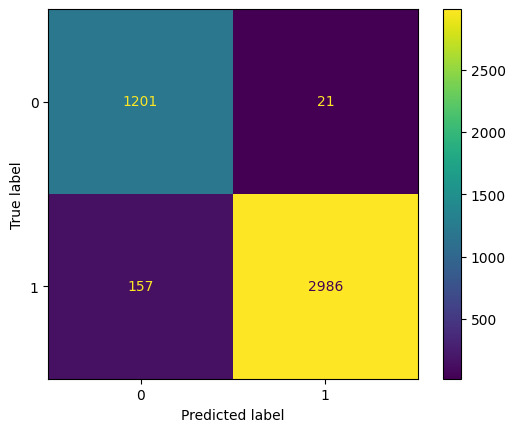

In [21]:
cnn33_ptb_adam_64 = CNN33(2)
[cnn33_ptb_adam_64_train_losses, cnn33_ptb_adam_64_test_losses, cnn33_ptb_adam_64_test_loader] = train_nn(cnn33_ptb_adam_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 64, "cnn")
test_nn(cnn33_ptb_adam_64, crossEntropy, cnn33_ptb_adam_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.3396134374663234, Train Accuracy: 0.8473244968090329
Test Loss: 0.3446426881211145, Test Accuracy: 0.8371134020618557
------------------
Epoch 20/100
Train Loss: 0.1604765602387488, Train Accuracy: 0.9377515954835542
Test Loss: 0.19951229648930685, Test Accuracy: 0.9166093928980527
------------------
Epoch 30/100
Train Loss: 0.12660453766584395, Train Accuracy: 0.9474717722140402
Test Loss: 0.1814691518300346, Test Accuracy: 0.9333333333333333
------------------
Epoch 40/100
Train Loss: 0.060542237712070346, Train Accuracy: 0.979381443298969
Test Loss: 0.1632444924541882, Test Accuracy: 0.9493699885452462
------------------
Epoch 50/100
Train Loss: 0.044881905743386595, Train Accuracy: 0.984585174275896
Test Loss: 0.13083304959748474, Test Accuracy: 0.9580756013745705
------------------
Epoch 60/100
Train Loss: 0.0183803316031117, Train Accuracy: 0.9945999018163967
Test Loss: 0.11830505122031484, Test Accuracy: 0.9647193585337915
------------------
Epoch 70/1

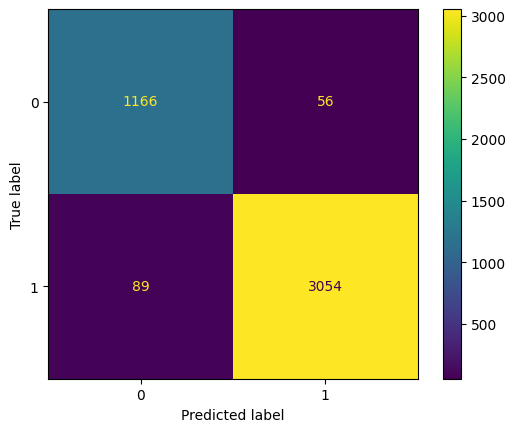

In [22]:
cnn33_ptb_adam_128 = CNN33(2)
[cnn33_ptb_adam_128_train_losses, cnn33_ptb_adam_128_test_losses, cnn33_ptb_adam_128_test_loader] = train_nn(cnn33_ptb_adam_128, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 128, "cnn")
test_nn(cnn33_ptb_adam_128, crossEntropy, cnn33_ptb_adam_128_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.556652945280075, Train Accuracy: 0.7228276877761414
Test Loss: 0.5611798875573752, Test Accuracy: 0.7200458190148912
------------------
Epoch 20/100
Train Loss: 0.4677623093128204, Train Accuracy: 0.7621993127147766
Test Loss: 0.4690563903338667, Test Accuracy: 0.7672394043528065
------------------
Epoch 30/100
Train Loss: 0.4562457540072501, Train Accuracy: 0.7674030436917035
Test Loss: 0.4681623185026473, Test Accuracy: 0.7720504009163803
------------------
Epoch 40/100
Train Loss: 0.28548091938719156, Train Accuracy: 0.8832596956308296
Test Loss: 0.2929023186797681, Test Accuracy: 0.8808705612829324
------------------
Epoch 50/100
Train Loss: 0.2739799778908491, Train Accuracy: 0.8913107511045656
Test Loss: 0.2834363957678062, Test Accuracy: 0.888430698739977
------------------
Epoch 60/100
Train Loss: 0.14217109975870698, Train Accuracy: 0.9460972017673048
Test Loss: 0.17325963787194612, Test Accuracy: 0.9376861397479954
------------------
Epoch 70/100
Tr

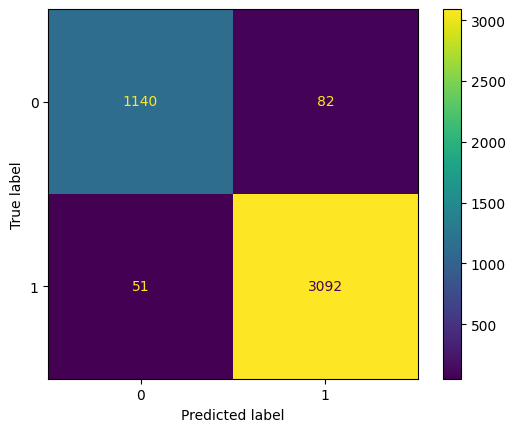

In [23]:
cnn33_ptb_sgd_64 = CNN33(2)
[cnn33_ptb_sgd_64_train_losses, cnn33_ptb_sgd_64_test_losses, cnn33_ptb_sgd_64_test_loader] = train_nn(cnn33_ptb_sgd_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "sgd", 100, 64, "cnn")
test_nn(cnn33_ptb_sgd_64, crossEntropy, cnn33_ptb_sgd_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5885987550020217, Train Accuracy: 0.7228276877761414
Test Loss: 0.5862499611718314, Test Accuracy: 0.7200458190148912
------------------
Epoch 20/100
Train Loss: 0.5048718731850386, Train Accuracy: 0.7228276877761414
Test Loss: 0.5095415260110583, Test Accuracy: 0.7200458190148912
------------------
Epoch 30/100
Train Loss: 0.49596353620290756, Train Accuracy: 0.7229258713794796
Test Loss: 0.5052112851824079, Test Accuracy: 0.7287514318442153
------------------
Epoch 40/100
Train Loss: 0.428544033691287, Train Accuracy: 0.7839960726558665
Test Loss: 0.4390793289457049, Test Accuracy: 0.7906071019473081
------------------
Epoch 50/100
Train Loss: 0.3450046231970191, Train Accuracy: 0.8585174275895925
Test Loss: 0.3432195356913975, Test Accuracy: 0.8611683848797251
------------------
Epoch 60/100
Train Loss: 0.3039501728489995, Train Accuracy: 0.8657830142366225
Test Loss: 0.3152647307940892, Test Accuracy: 0.8604810996563574
------------------
Epoch 70/100
Tra

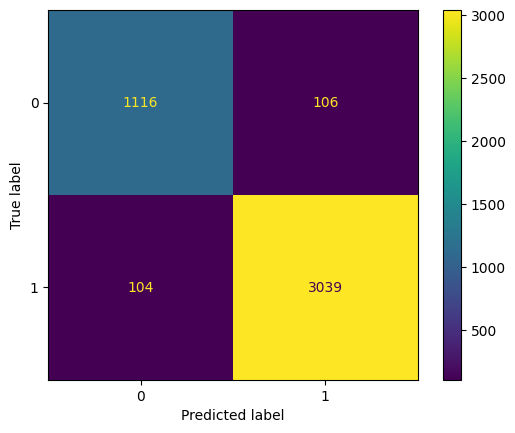

In [24]:
cnn33_ptb_sgd_128 = CNN33(2)
[cnn33_ptb_sgd_128_train_losses, cnn33_ptb_sgd_128_test_losses, cnn33_ptb_sgd_128_test_loader] = train_nn(cnn33_ptb_sgd_128, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "sgd", 100, 128, "cnn")
test_nn(cnn33_ptb_sgd_128, crossEntropy, cnn33_ptb_sgd_128_test_loader)

##### Plotting

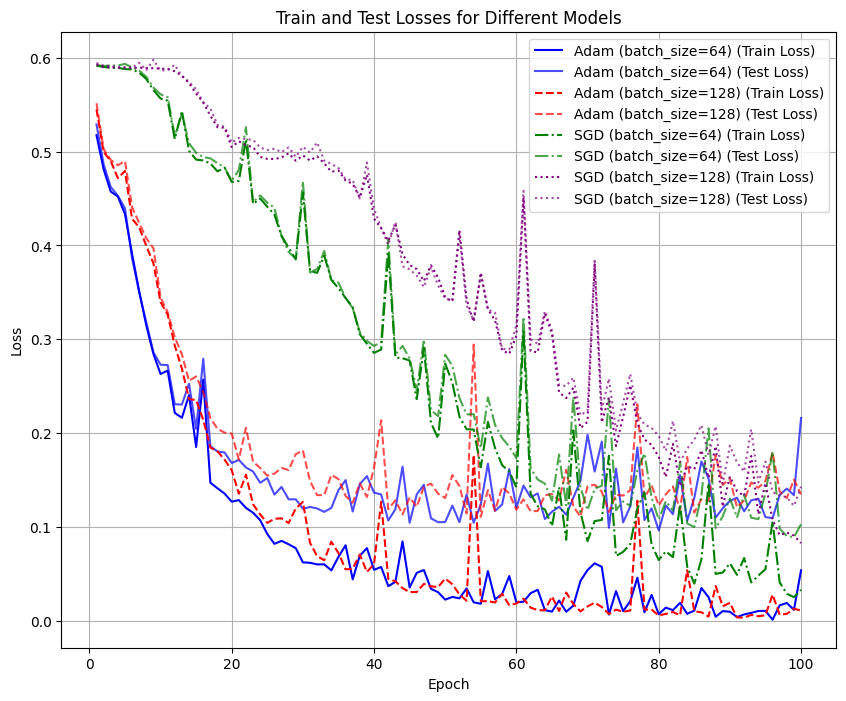

In [25]:
cnn33_ptb_train_losses = [cnn33_ptb_adam_64_train_losses, cnn33_ptb_adam_128_train_losses, cnn33_ptb_sgd_64_train_losses, cnn33_ptb_sgd_128_train_losses]
cnn33_ptb_test_losses = [cnn33_ptb_adam_64_test_losses, cnn33_ptb_adam_128_test_losses, cnn33_ptb_sgd_64_test_losses, cnn33_ptb_sgd_128_test_losses]
plot_losses(100, cnn33_ptb_train_losses, cnn33_ptb_test_losses)

##### 4 layers

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.36020312635228036, Train Accuracy: 0.8343642611683849
Test Loss: 0.3618450324604477, Test Accuracy: 0.836426116838488
------------------
Epoch 20/100
Train Loss: 0.17761365652550012, Train Accuracy: 0.9291114383897889
Test Loss: 0.217019097312637, Test Accuracy: 0.9156930126002291
------------------
Epoch 30/100
Train Loss: 0.06950779996113851, Train Accuracy: 0.9755522827687776
Test Loss: 0.14318151218627673, Test Accuracy: 0.9544100801832761
------------------
Epoch 40/100
Train Loss: 0.061885913030710074, Train Accuracy: 0.9799705449189985
Test Loss: 0.15241850791094097, Test Accuracy: 0.9525773195876288
------------------
Epoch 50/100
Train Loss: 0.023999961293884552, Train Accuracy: 0.9920471281296024
Test Loss: 0.15850908111483938, Test Accuracy: 0.9670103092783505
------------------
Epoch 60/100
Train Loss: 0.024535554756585042, Train Accuracy: 0.9919489445262641
Test Loss: 0.16126628868632775, Test Accuracy: 0.96815578465063
------------------
Epoch 7

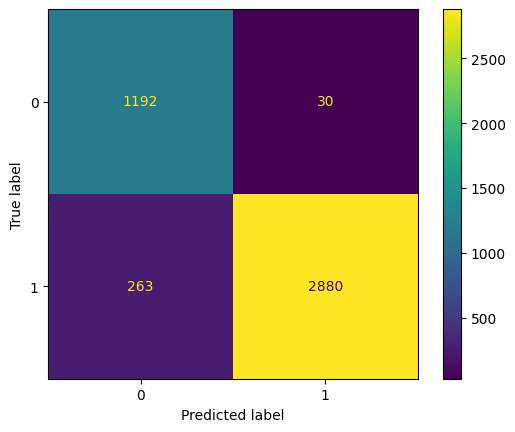

In [26]:
cnn44_ptb_adam_64 = CNN44(2)
[cnn44_ptb_adam_64_train_losses, cnn44_ptb_adam_64_test_losses, cnn44_ptb_adam_64_test_loader] = train_nn(cnn44_ptb_adam_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 64, "cnn")
test_nn(cnn44_ptb_adam_64, crossEntropy, cnn44_ptb_adam_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.40957325994968413, Train Accuracy: 0.8016691212567502
Test Loss: 0.4097100656479597, Test Accuracy: 0.8016691212567502
------------------
Epoch 20/100
Train Loss: 0.26458260118961335, Train Accuracy: 0.8972017673048601
Test Loss: 0.2641985401511192, Test Accuracy: 0.8972017673048601
------------------
Epoch 30/100
Train Loss: 0.1584787313826382, Train Accuracy: 0.9480608738340697
Test Loss: 0.15897178379818797, Test Accuracy: 0.9480608738340697
------------------
Epoch 40/100
Train Loss: 0.10415864624083042, Train Accuracy: 0.9644575355915562
Test Loss: 0.10443343133665621, Test Accuracy: 0.9644575355915562
------------------
Epoch 50/100
Train Loss: 0.057941080536693335, Train Accuracy: 0.9804614629356897
Test Loss: 0.05786423089448363, Test Accuracy: 0.9804614629356897
------------------
Epoch 60/100
Train Loss: 0.04794079780112952, Train Accuracy: 0.9824251350024545
Test Loss: 0.04786764326272532, Test Accuracy: 0.9824251350024545
------------------
Epoch 

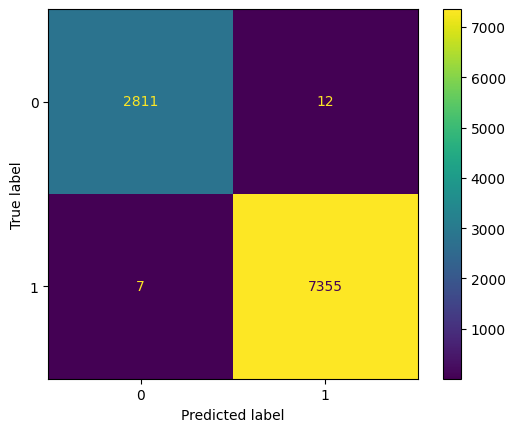

In [27]:
cnn44_ptb_adam_128 = CNN44(2)
[cnn44_ptb_adam_128_train_losses, cnn44_ptb_adam_128_test_losses, cnn44_ptb_adam_128_test_loader] = train_nn(cnn44_ptb_adam_128, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "adam", 100, 128, "cnn")
test_nn(cnn44_ptb_adam_128, crossEntropy, cnn44_ptb_adam_128_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5917796723544597, Train Accuracy: 0.7228276877761414
Test Loss: 0.5907372882589698, Test Accuracy: 0.7228276877761414
------------------
Epoch 20/100
Train Loss: 0.5901496039703489, Train Accuracy: 0.7228276877761414
Test Loss: 0.5895517537370324, Test Accuracy: 0.7228276877761414
------------------
Epoch 30/100
Train Loss: 0.5930005939677357, Train Accuracy: 0.7228276877761414
Test Loss: 0.5925120890140534, Test Accuracy: 0.7228276877761414
------------------
Epoch 40/100
Train Loss: 0.5899677820503711, Train Accuracy: 0.7228276877761414
Test Loss: 0.5904979433864355, Test Accuracy: 0.7228276877761414
------------------
Epoch 50/100
Train Loss: 0.5905575346201658, Train Accuracy: 0.7228276877761414
Test Loss: 0.5905575189739466, Test Accuracy: 0.7228276877761414
------------------
Epoch 60/100
Train Loss: 0.5912140384316444, Train Accuracy: 0.7228276877761414
Test Loss: 0.5894514510408044, Test Accuracy: 0.7228276877761414
------------------
Epoch 70/100
Tra

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Metrics
Accuracy: 0.723
Precision: [0.         0.72282769]
Recall: [0. 1.]
F1: [0.        0.8391178]


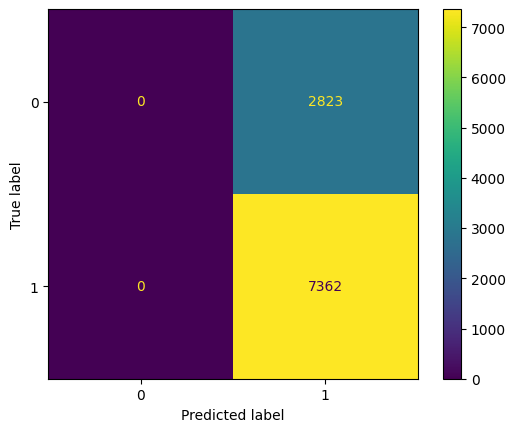

In [28]:
cnn44_ptb_sgd_64 = CNN44(2)
[cnn44_ptb_sgd_64_train_losses, cnn44_ptb_sgd_64_test_losses, cnn44_ptb_sgd_64_test_loader] = train_nn(cnn44_ptb_sgd_64, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "sgd", 100, 64, "cnn")
test_nn(cnn44_ptb_sgd_64, crossEntropy, cnn44_ptb_sgd_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5901118006557227, Train Accuracy: 0.7228276877761414
Test Loss: 0.5900404881685972, Test Accuracy: 0.7228276877761414
------------------
Epoch 20/100
Train Loss: 0.5898942723870277, Train Accuracy: 0.7228276877761414
Test Loss: 0.5905241675674915, Test Accuracy: 0.7228276877761414
------------------
Epoch 30/100
Train Loss: 0.5899260744452477, Train Accuracy: 0.7228276877761414
Test Loss: 0.5907446332275867, Test Accuracy: 0.7228276877761414
------------------
Epoch 40/100
Train Loss: 0.5903495285660029, Train Accuracy: 0.7228276877761414
Test Loss: 0.5898380652070045, Test Accuracy: 0.7228276877761414
------------------
Epoch 50/100
Train Loss: 0.5906395696103572, Train Accuracy: 0.7228276877761414
Test Loss: 0.5907066449522972, Test Accuracy: 0.7228276877761414
------------------
Epoch 60/100
Train Loss: 0.5904960952699184, Train Accuracy: 0.7228276877761414
Test Loss: 0.5905640207231044, Test Accuracy: 0.7228276877761414
------------------
Epoch 70/100
Tra

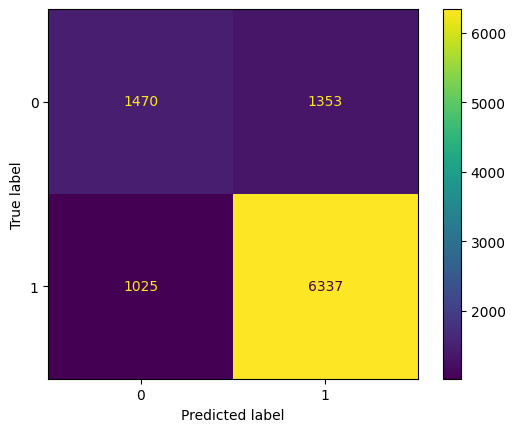

In [29]:
cnn44_ptb_sgd_128 = CNN44(2)
[cnn44_ptb_sgd_128_train_losses, cnn44_ptb_sgd_128_test_losses, cnn44_ptb_sgd_128_test_loader] = train_nn(cnn44_ptb_sgd_128, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "sgd", 100, 128, "cnn")
test_nn(cnn44_ptb_sgd_128, crossEntropy, cnn44_ptb_sgd_128_test_loader)

##### Plotting

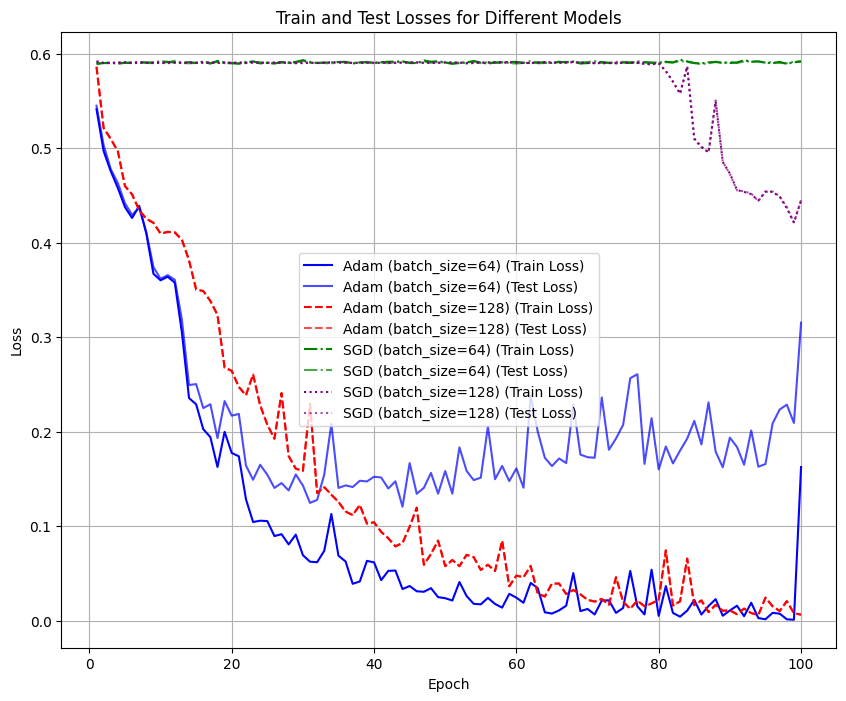

In [30]:
cnn44_ptb_train_losses = [cnn44_ptb_adam_64_train_losses, cnn44_ptb_adam_128_train_losses, cnn44_ptb_sgd_64_train_losses, cnn44_ptb_sgd_128_train_losses]
cnn44_ptb_test_losses = [cnn44_ptb_adam_64_test_losses, cnn44_ptb_adam_128_test_losses, cnn44_ptb_sgd_64_test_losses, cnn44_ptb_sgd_128_test_losses]
plot_losses(100, cnn44_ptb_train_losses, cnn44_ptb_test_losses)

### LSTM

#### Architecture

In [ ]:
class LSTM(nn.Module):
    def __init__(self, output_size, input_size=149, hidden_size=32, num_layers=2):
        super(LSTM, self).__init__()
        # 187 (initial) * 80 // 100 (feature selection) = 149
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 512)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 64)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        x = x.unsqueeze(1)  # Add a batch dimension of size 1
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout1(self.relu(self.fc1(out[:, -1, :])))
        out = self.dropout2(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

class BiLSTM(nn.Module):
    def __init__(self, output_size, input_size=149, hidden_size=64, num_layers=2):
        super(BiLSTM, self).__init__()
        # 187 (initial) * 80 // 100 (feature selection) = 149
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_size * 2, 81)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(81, 27)
        self.dropout2 = nn.Dropout(0.25)
        self.fc3 = nn.Linear(27, 9)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(9, output_size)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        
        x = x.unsqueeze(1)  # Add a batch dimension of size 1
        out, _ = self.lstm(x, (h0, c0))
        out = torch.cat((out[:, -1, :self.hidden_size], out[:, 0, self.hidden_size:]), dim=1)
        
        out = self.dropout1(self.relu(self.fc1(out)))
        out = self.dropout2(self.relu(self.fc2(out)))
        out = self.dropout3(self.relu(self.fc3(out)))
        out = self.fc4(out)
        return out

#### MITBIH dataset

##### LSTM

Epoch 10/100
Train Loss: 0.08704190583749777, Train Accuracy: 0.9753292291526275
Test Loss: 0.10974210084744515, Test Accuracy: 0.9711296879996345
------------------
Epoch 20/100
Train Loss: 0.058129117950119165, Train Accuracy: 0.9816568250088518
Test Loss: 0.08852559609105132, Test Accuracy: 0.9767027545566671
------------------
Epoch 30/100
Train Loss: 0.04880933482987348, Train Accuracy: 0.9842495402784599
Test Loss: 0.08804060308481282, Test Accuracy: 0.9784843086199808
------------------
Epoch 40/100
Train Loss: 0.036342280744925314, Train Accuracy: 0.987972999211906
Test Loss: 0.08839597768035212, Test Accuracy: 0.9790324791010004
------------------
Epoch 50/100
Train Loss: 0.02968518241637552, Train Accuracy: 0.9901773782737313
Test Loss: 0.08906842346347967, Test Accuracy: 0.9794436069617651
------------------
Epoch 60/100
Train Loss: 0.02459356169725875, Train Accuracy: 0.9915137116946307
Test Loss: 0.09821574145801767, Test Accuracy: 0.9807226714174775
------------------
Epo

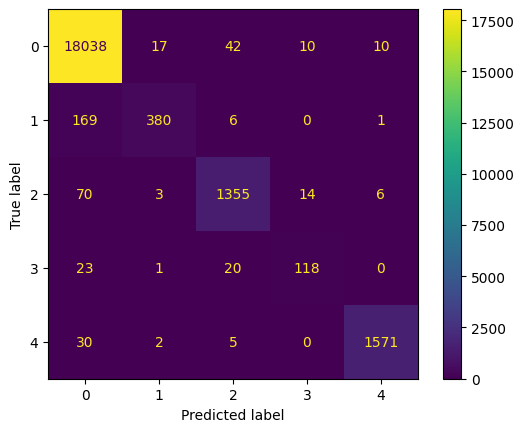

In [ ]:
lstm_mitbih_adam_64 = LSTM(5)
[lstm_mitbih_adam_64_train_losses, lstm_mitbih_adam_64_test_losses, lstm_mitbih_adam_64_test_loader] = train_nn(lstm_mitbih_adam_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 64)
test_nn(lstm_mitbih_adam_64, crossEntropy, lstm_mitbih_adam_64_test_loader)

Epoch 10/100
Train Loss: 0.09722862898705215, Train Accuracy: 0.9746553516155928
Test Loss: 0.11249379056700787, Test Accuracy: 0.9701247087844319
------------------
Epoch 20/100
Train Loss: 0.06786794993333028, Train Accuracy: 0.9796694573572579
Test Loss: 0.09936585718614244, Test Accuracy: 0.9744187108857522
------------------
Epoch 30/100
Train Loss: 0.05686962389288195, Train Accuracy: 0.9819537879912739
Test Loss: 0.08807251003549196, Test Accuracy: 0.9763829884427391
------------------
Epoch 40/100
Train Loss: 0.044063711726534976, Train Accuracy: 0.9856429819652096
Test Loss: 0.08798340244386561, Test Accuracy: 0.9783472659997259
------------------
Epoch 50/100
Train Loss: 0.03526749694668926, Train Accuracy: 0.9877674094548445
Test Loss: 0.09054549942101044, Test Accuracy: 0.9783929468731443
------------------
Epoch 60/100
Train Loss: 0.030659958164812658, Train Accuracy: 0.9891380078352541
Test Loss: 0.09156246552769051, Test Accuracy: 0.9810881184048239
------------------
Ep

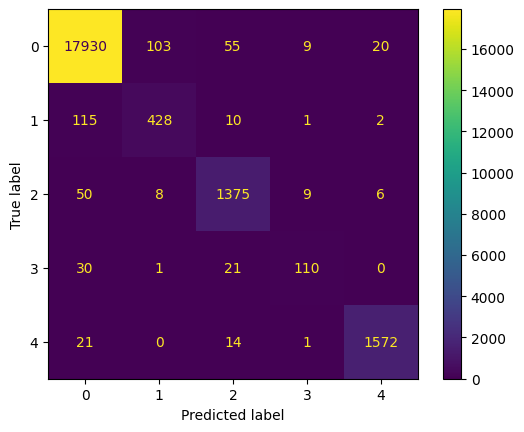

In [ ]:
lstm_mitbih_adam_128 = LSTM(5)
[lstm_mitbih_adam_128_train_losses, lstm_mitbih_adam_128_test_losses, lstm_mitbih_adam_128_test_loader] = train_nn(lstm_mitbih_adam_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 128)
test_nn(lstm_mitbih_adam_128, crossEntropy, lstm_mitbih_adam_128_test_loader)

Epoch 10/100
Train Loss: 0.1930159070631768, Train Accuracy: 0.9548844699781847
Test Loss: 0.19850477742699163, Test Accuracy: 0.9524005298981316
------------------
Epoch 20/100
Train Loss: 0.11839975040491706, Train Accuracy: 0.9691615364407844
Test Loss: 0.13159447296932558, Test Accuracy: 0.9657850258096935
------------------
Epoch 30/100
Train Loss: 0.08902279499624335, Train Accuracy: 0.9751350610487362
Test Loss: 0.10559104646911774, Test Accuracy: 0.9707185601388698
------------------
Epoch 40/100
Train Loss: 0.07513723353618229, Train Accuracy: 0.9775678731739632
Test Loss: 0.09712782494707506, Test Accuracy: 0.9731853273034581
------------------
Epoch 50/100
Train Loss: 0.06501879920578209, Train Accuracy: 0.9806745628362249
Test Loss: 0.09192638451222646, Test Accuracy: 0.9749668813667718
------------------
Epoch 60/100
Train Loss: 0.051872896300526314, Train Accuracy: 0.9838040958048268
Test Loss: 0.08235662384909026, Test Accuracy: 0.9780274998857978
------------------
Epoc

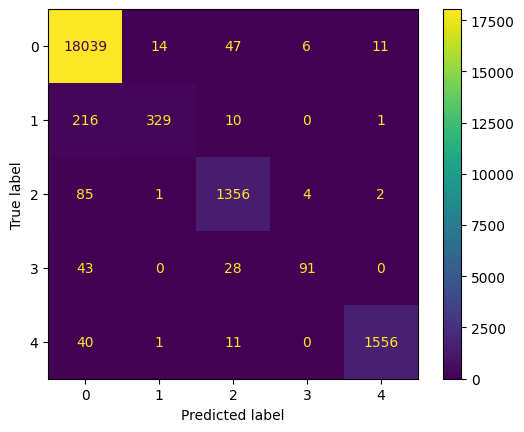

In [ ]:
lstm_mitbih_sgd_64 = LSTM(5)
[lstm_mitbih_sgd_64_train_losses, lstm_mitbih_sgd_64_test_losses, lstm_mitbih_sgd_64_test_loader] = train_nn(lstm_mitbih_sgd_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 64)
test_nn(lstm_mitbih_sgd_64, crossEntropy, lstm_mitbih_sgd_64_test_loader)

Epoch 10/100
Train Loss: 0.32320249807225526, Train Accuracy: 0.9167932566559683
Test Loss: 0.32805541010443556, Test Accuracy: 0.916038554657165
------------------
Epoch 20/100
Train Loss: 0.1576654807647459, Train Accuracy: 0.960652404829075
Test Loss: 0.16315692278751454, Test Accuracy: 0.9584760860627656
------------------
Epoch 30/100
Train Loss: 0.11847596185071135, Train Accuracy: 0.969538450995397
Test Loss: 0.1293051055968241, Test Accuracy: 0.9662418345438765
------------------
Epoch 40/100
Train Loss: 0.16624406182689824, Train Accuracy: 0.9560380569483627
Test Loss: 0.1756742616714693, Test Accuracy: 0.9539993604677721
------------------
Epoch 50/100
Train Loss: 0.10470671814587647, Train Accuracy: 0.9723481776752367
Test Loss: 0.11643367794580585, Test Accuracy: 0.9689826869489745
------------------
Epoch 60/100
Train Loss: 0.09658996708772696, Train Accuracy: 0.9730106335591013
Test Loss: 0.11155886282240106, Test Accuracy: 0.9694851765565757
------------------
Epoch 70/1

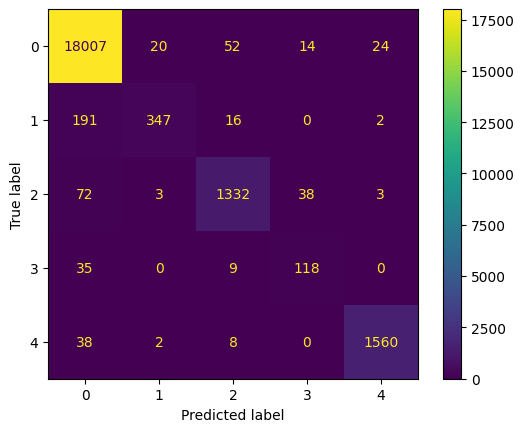

In [ ]:
lstm_mitbih_sgd_128 = LSTM(5)
[lstm_mitbih_sgd_128_train_losses, lstm_mitbih_sgd_128_test_losses, lstm_mitbih_sgd_128_test_loader] = train_nn(lstm_mitbih_sgd_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 128)
test_nn(lstm_mitbih_sgd_128, crossEntropy, lstm_mitbih_sgd_128_test_loader)

##### Plotting

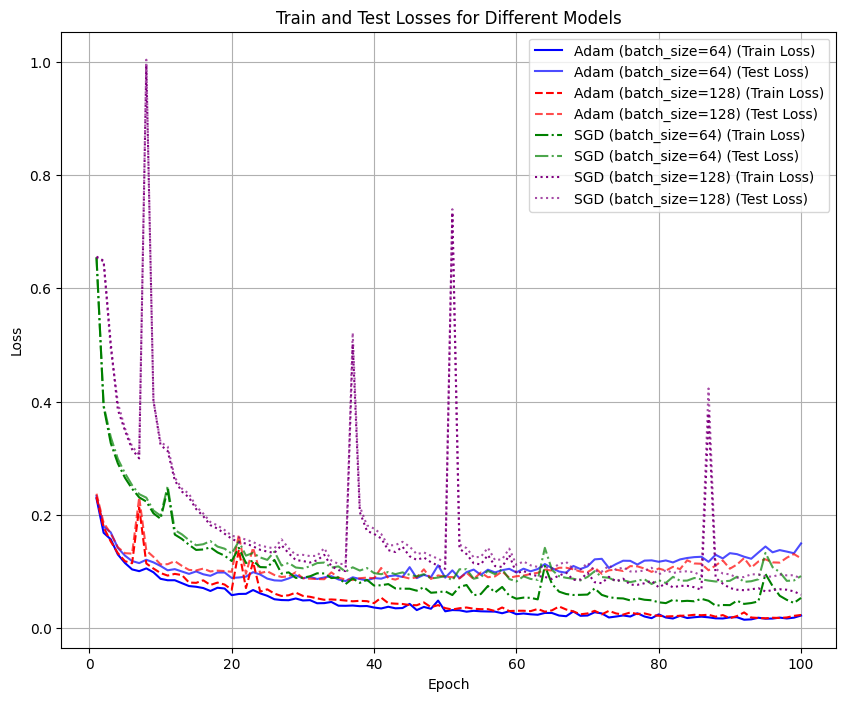

In [ ]:
lstm_mitbih_train_losses = [lstm_mitbih_adam_64_train_losses, lstm_mitbih_adam_128_train_losses, lstm_mitbih_sgd_64_train_losses, lstm_mitbih_sgd_128_train_losses]
lstm_mitbih_test_losses = [lstm_mitbih_adam_64_test_losses, lstm_mitbih_adam_128_test_losses, lstm_mitbih_sgd_64_test_losses, lstm_mitbih_sgd_128_test_losses]
plot_losses(100, lstm_mitbih_train_losses, lstm_mitbih_test_losses)

##### BiLSTM

Metrics
Accuracy: 0.981
Precision: [0.98669149 0.88817204 0.95348837 0.76436782 0.99237611]
Recall: [0.99442513 0.74280576 0.93439227 0.82098765 0.97139303]
F1: [0.99054322 0.80901077 0.94384374 0.79166667 0.98177247]


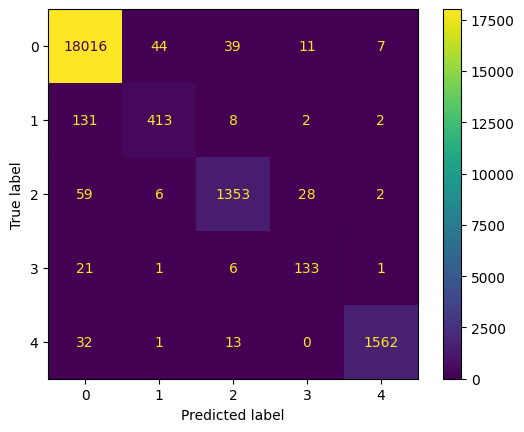

In [ ]:
bilstm_mitbih_adam_64 = BiLSTM(5)
[bilstm_mitbih_adam_64_train_losses, bilstm_mitbih_adam_64_test_losses, bilstm_mitbih_adam_64_test_loader] = train_nn(bilstm_mitbih_adam_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 64)
test_nn(bilstm_mitbih_adam_64, crossEntropy, bilstm_mitbih_adam_64_test_loader)

Epoch 10/100
Train Loss: 0.1493004031683298, Train Accuracy: 0.9499388941555401
Test Loss: 0.1626739473566738, Test Accuracy: 0.9481522086702298
------------------
Epoch 20/100
Train Loss: 0.10075198181218258, Train Accuracy: 0.9721425879181753
Test Loss: 0.12870128442003523, Test Accuracy: 0.9689826869489745
------------------
Epoch 30/100
Train Loss: 0.07171089025418154, Train Accuracy: 0.9802405400157619
Test Loss: 0.10885735266560385, Test Accuracy: 0.9756977753414645
------------------
Epoch 40/100
Train Loss: 0.058131538200987015, Train Accuracy: 0.983552819435085
Test Loss: 0.11370028895434252, Test Accuracy: 0.9753780092275365
------------------
Epoch 50/100
Train Loss: 0.043241251378307706, Train Accuracy: 0.987550398044613
Test Loss: 0.11421799708731732, Test Accuracy: 0.9779818190123796
------------------
Epoch 60/100
Train Loss: 0.0487382557598303, Train Accuracy: 0.9860198965198222
Test Loss: 0.17833494925722587, Test Accuracy: 0.9776620528984514
------------------
Epoch 7

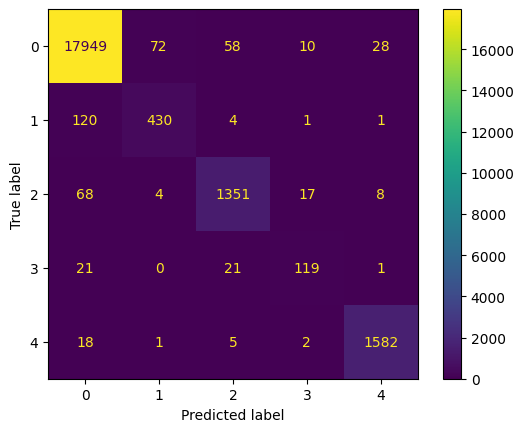

In [ ]:
bilstm_mitbih_adam_128 = BiLSTM(5)
[bilstm_mitbih_adam_128_train_losses, bilstm_mitbih_adam_128_test_losses, bilstm_mitbih_adam_128_test_loader] = train_nn(bilstm_mitbih_adam_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "adam", 100, 128)
test_nn(bilstm_mitbih_adam_128, crossEntropy, bilstm_mitbih_adam_128_test_loader)

Epoch 10/100
Train Loss: 0.29586629742869414, Train Accuracy: 0.9320068986785147
Test Loss: 0.30688908029315076, Test Accuracy: 0.9311589237586223
------------------
Epoch 20/100
Train Loss: 0.22550483776216984, Train Accuracy: 0.9439996345070986
Test Loss: 0.23884514570453425, Test Accuracy: 0.9429445891005436
------------------
Epoch 30/100
Train Loss: 0.1782259385695394, Train Accuracy: 0.9569860541614793
Test Loss: 0.1902998279584653, Test Accuracy: 0.9554154675437394
------------------
Epoch 40/100
Train Loss: 0.15189290865493832, Train Accuracy: 0.9618402567587633
Test Loss: 0.16260396175998815, Test Accuracy: 0.95916129916404
------------------
Epoch 50/100
Train Loss: 0.11219469237381455, Train Accuracy: 0.973387548113714
Test Loss: 0.12449894262798153, Test Accuracy: 0.9706728792654515
------------------
Epoch 60/100
Train Loss: 0.09827277220246824, Train Accuracy: 0.9760487933023426
Test Loss: 0.11618471155947742, Test Accuracy: 0.9719062628477456
------------------
Epoch 70/

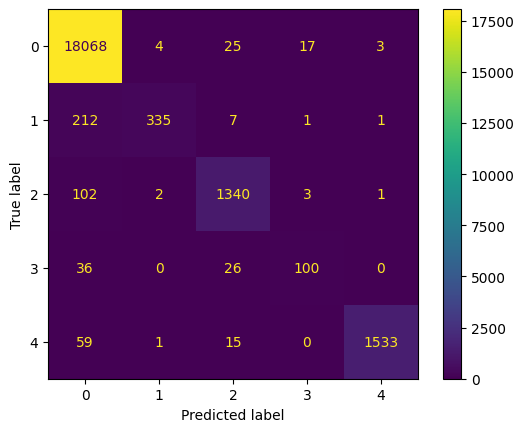

In [ ]:
bilstm_mitbih_sgd_64 = BiLSTM(5)
[bilstm_mitbih_sgd_64_train_losses, bilstm_mitbih_sgd_64_test_losses, bilstm_mitbih_sgd_64_test_loader] = train_nn(bilstm_mitbih_sgd_64, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 64)
test_nn(bilstm_mitbih_sgd_64, crossEntropy, bilstm_mitbih_sgd_64_test_loader)

Epoch 10/100
Train Loss: 0.6564534814905947, Train Accuracy: 0.8277272052356858
Test Loss: 0.6549499422138514, Test Accuracy: 0.8276003837193368
------------------
Epoch 20/100
Train Loss: 0.272705932070304, Train Accuracy: 0.9354562379358788
Test Loss: 0.28744259706243525, Test Accuracy: 0.9345393083915764
------------------
Epoch 30/100
Train Loss: 0.22967555787495889, Train Accuracy: 0.9441366943451395
Test Loss: 0.24204036493807338, Test Accuracy: 0.9429445891005436
------------------
Epoch 40/100
Train Loss: 0.20856484502662706, Train Accuracy: 0.9476088769088438
Test Loss: 0.22313471765495663, Test Accuracy: 0.9460965693664063
------------------
Epoch 50/100
Train Loss: 0.15460424945030335, Train Accuracy: 0.9641474306991193
Test Loss: 0.17283617187464653, Test Accuracy: 0.9626330455438308
------------------
Epoch 60/100
Train Loss: 0.13655484114250127, Train Accuracy: 0.9674368668121024
Test Loss: 0.15045194218455013, Test Accuracy: 0.9653738979489288
------------------
Epoch 70

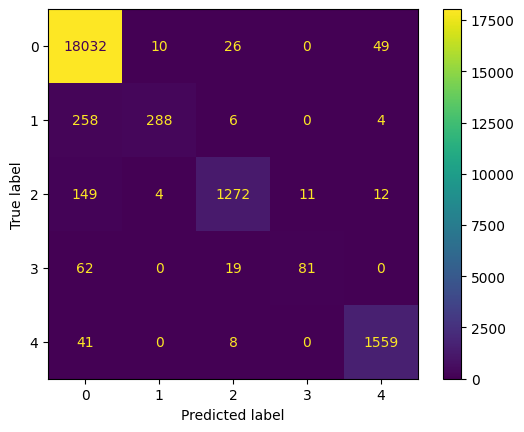

In [ ]:
bilstm_mitbih_sgd_128 = BiLSTM(5)
[bilstm_mitbih_sgd_128_train_losses, bilstm_mitbih_sgd_128_test_losses, bilstm_mitbih_sgd_128_test_loader] = train_nn(bilstm_mitbih_sgd_128, X_mitbih_train, y_mitbih_train, X_mitbih_test, y_mitbih_test, crossEntropy, "sgd", 100, 128)
test_nn(bilstm_mitbih_sgd_128, crossEntropy, bilstm_mitbih_sgd_128_test_loader)

##### Plotting

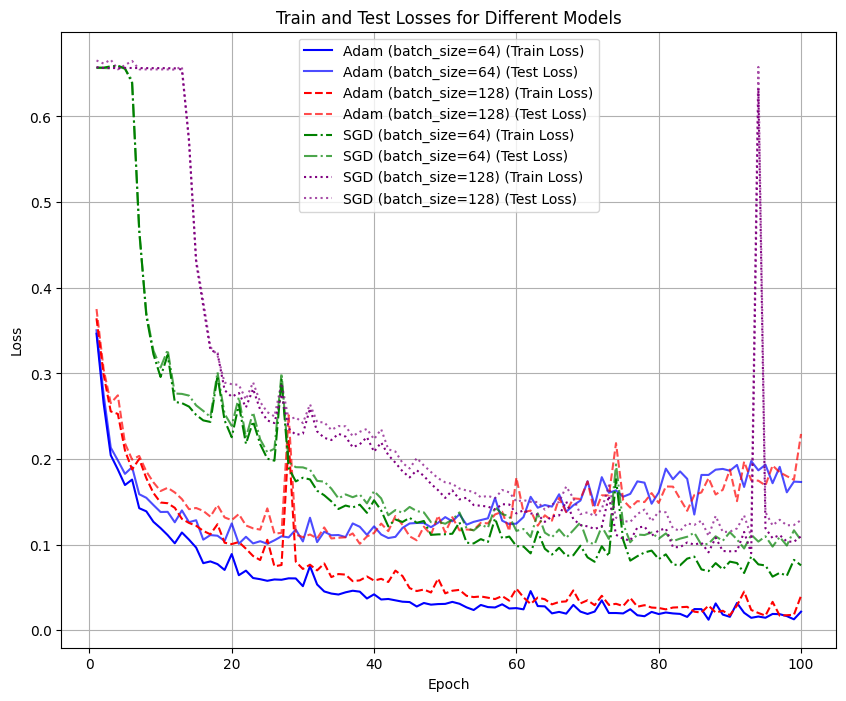

In [ ]:
bilstm_mitbih_train_losses = [bilstm_mitbih_adam_64_train_losses, bilstm_mitbih_adam_128_train_losses, bilstm_mitbih_sgd_64_train_losses, bilstm_mitbih_sgd_128_train_losses]
bilstm_mitbih_test_losses = [bilstm_mitbih_adam_64_test_losses, bilstm_mitbih_adam_128_test_losses, bilstm_mitbih_sgd_64_test_losses, bilstm_mitbih_sgd_128_test_losses]
plot_losses(100, bilstm_mitbih_train_losses, bilstm_mitbih_test_losses)

#### PTB dataset

##### LSTM

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.2500530937919393, Train Accuracy: 0.8956308296514482
Test Loss: 0.2623500893081444, Test Accuracy: 0.8918671248568156
------------------
Epoch 20/100
Train Loss: 0.16795076443813742, Train Accuracy: 0.937260677466863
Test Loss: 0.1929880657057831, Test Accuracy: 0.9255441008018328
------------------
Epoch 30/100
Train Loss: 0.11577038653194904, Train Accuracy: 0.9513009327442317
Test Loss: 0.1689231049647366, Test Accuracy: 0.9379152348224513
------------------
Epoch 40/100
Train Loss: 0.1326986100175418, Train Accuracy: 0.943740795287187
Test Loss: 0.2071458175238492, Test Accuracy: 0.9248568155784651
------------------
Epoch 50/100
Train Loss: 0.05725922620331403, Train Accuracy: 0.9771232204221895
Test Loss: 0.15418479212330302, Test Accuracy: 0.9564719358533792
------------------
Epoch 60/100
Train Loss: 0.04919145811290946, Train Accuracy: 0.9810505645557192
Test Loss: 0.16899688043834074, Test Accuracy: 0.9585337915234823
------------------
Epoch 70/100

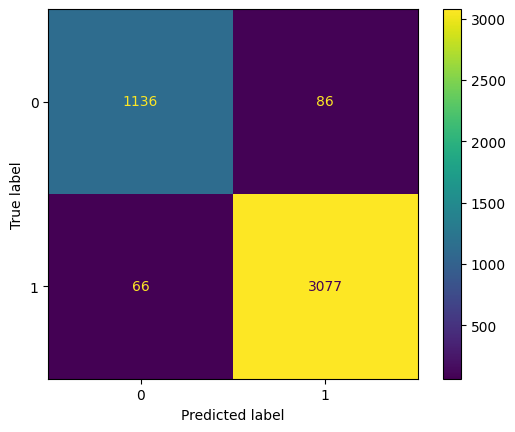

In [ ]:
lstm_ptb_adam_64 = LSTM(2)
[lstm_ptb_adam_64_train_losses, lstm_ptb_adam_64_test_losses, lstm_ptb_adam_64_test_loader] = train_nn(lstm_ptb_adam_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 64)
test_nn(lstm_ptb_adam_64, crossEntropy, lstm_ptb_adam_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.24338289648294448, Train Accuracy: 0.9015218458517428
Test Loss: 0.2619419459785734, Test Accuracy: 0.8994272623138603
------------------
Epoch 20/100
Train Loss: 0.21578200086951255, Train Accuracy: 0.9122238586156112
Test Loss: 0.24360525182315282, Test Accuracy: 0.9049255441008018
------------------
Epoch 30/100
Train Loss: 0.12855960917659104, Train Accuracy: 0.9501227295041728
Test Loss: 0.16484314682228224, Test Accuracy: 0.9367697594501718
------------------
Epoch 40/100
Train Loss: 0.09050452318042516, Train Accuracy: 0.9656357388316151
Test Loss: 0.14739325961896352, Test Accuracy: 0.9507445589919816
------------------
Epoch 50/100
Train Loss: 0.07808353414293379, Train Accuracy: 0.9705449189985272
Test Loss: 0.14855198450386525, Test Accuracy: 0.9486827033218785
------------------
Epoch 60/100
Train Loss: 0.05714940438047052, Train Accuracy: 0.976926853215513
Test Loss: 0.1483774914273194, Test Accuracy: 0.9553264604810997
------------------
Epoch 7

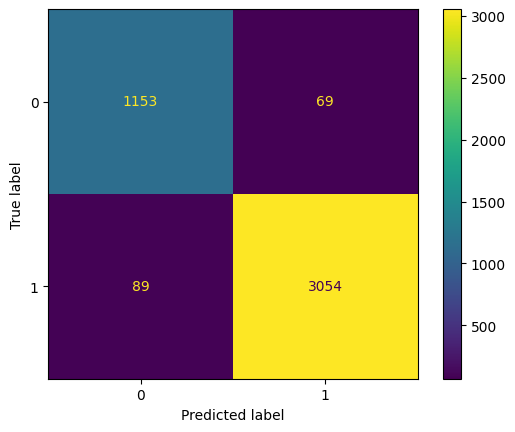

In [ ]:
lstm_ptb_adam_128 = LSTM(2)
[lstm_ptb_adam_128_train_losses, lstm_ptb_adam_128_test_losses, lstm_ptb_adam_128_test_loader] = train_nn(lstm_ptb_adam_128, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 128)
test_nn(lstm_ptb_adam_128, crossEntropy, lstm_ptb_adam_128_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5891648236662149, Train Accuracy: 0.7228276877761414
Test Loss: 0.5917601680410081, Test Accuracy: 0.7200458190148912
------------------
Epoch 20/100
Train Loss: 0.35595140270888803, Train Accuracy: 0.819440353460972
Test Loss: 0.36195958351743396, Test Accuracy: 0.8151202749140893
------------------
Epoch 30/100
Train Loss: 0.3176305813714862, Train Accuracy: 0.8413352970054001
Test Loss: 0.3314927241940429, Test Accuracy: 0.8400916380297824
------------------
Epoch 40/100
Train Loss: 0.2801139229908586, Train Accuracy: 0.8628375061364753
Test Loss: 0.2934954572415006, Test Accuracy: 0.8597938144329897
------------------
Epoch 50/100
Train Loss: 0.2276350733358413, Train Accuracy: 0.901620029455081
Test Loss: 0.24653906601926553, Test Accuracy: 0.8920962199312715
------------------
Epoch 60/100
Train Loss: 0.18513438443187624, Train Accuracy: 0.9299950908198331
Test Loss: 0.22662231369294983, Test Accuracy: 0.9106529209621993
------------------
Epoch 70/100


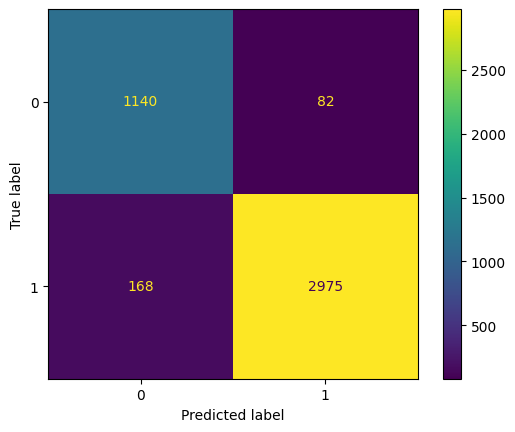

In [ ]:
lstm_ptb_sgd_64 = LSTM(2)
[lstm_ptb_sgd_64_train_losses, lstm_ptb_sgd_64_test_losses, lstm_ptb_sgd_64_test_loader] = train_nn(lstm_ptb_sgd_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "sgd", 100, 64)
test_nn(lstm_ptb_sgd_64, crossEntropy, lstm_ptb_sgd_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5885160058736801, Train Accuracy: 0.7228276877761414
Test Loss: 0.5901065724236625, Test Accuracy: 0.7200458190148912
------------------
Epoch 20/100
Train Loss: 0.4125749830156565, Train Accuracy: 0.7883161512027491
Test Loss: 0.41146158490862167, Test Accuracy: 0.7951890034364261
------------------
Epoch 30/100
Train Loss: 0.33822920322418215, Train Accuracy: 0.8409425625920471
Test Loss: 0.3522352499621255, Test Accuracy: 0.836426116838488
------------------
Epoch 40/100
Train Loss: 0.3203232742846012, Train Accuracy: 0.8441826215022091
Test Loss: 0.33587808183261325, Test Accuracy: 0.8407789232531501
------------------
Epoch 50/100
Train Loss: 0.27940219882875683, Train Accuracy: 0.8682376043200786
Test Loss: 0.29781827330589294, Test Accuracy: 0.8604810996563574
------------------
Epoch 60/100
Train Loss: 0.2758278055116534, Train Accuracy: 0.8660775650466372
Test Loss: 0.2974644852536065, Test Accuracy: 0.8540664375715922
------------------
Epoch 70/100

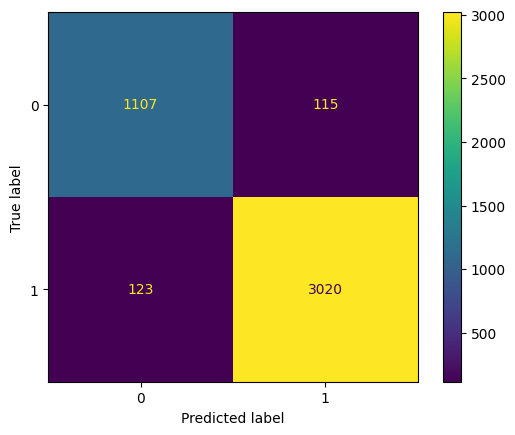

In [ ]:
lstm_ptb_sgd_128 = LSTM(2)
[lstm_ptb_sgd_128_train_losses, lstm_ptb_sgd_128_test_losses, lstm_ptb_sgd_128_test_loader] = train_nn(lstm_ptb_sgd_128, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "sgd", 100, 128)
test_nn(lstm_ptb_sgd_128, crossEntropy, lstm_ptb_sgd_128_test_loader)

##### Plotting

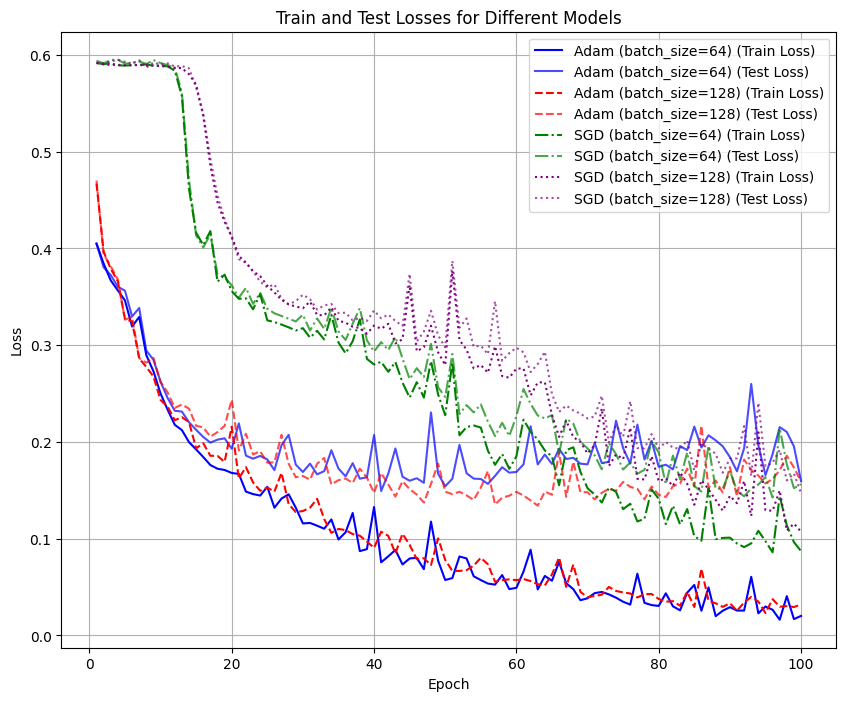

In [ ]:
lstm_ptb_train_losses = [lstm_ptb_adam_64_train_losses, lstm_ptb_adam_128_train_losses, lstm_ptb_sgd_64_train_losses, lstm_ptb_sgd_128_train_losses]
lstm_ptb_test_losses = [lstm_ptb_adam_64_test_losses, lstm_ptb_adam_128_test_losses, lstm_ptb_sgd_64_test_losses, lstm_ptb_sgd_128_test_losses]
plot_losses(100, lstm_ptb_train_losses, lstm_ptb_test_losses)

##### BiLSTM

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.23493008478544652, Train Accuracy: 0.9021109474717722
Test Loss: 0.249975663272367, Test Accuracy: 0.89553264604811
------------------
Epoch 20/100
Train Loss: 0.14956706739030778, Train Accuracy: 0.9403043691703485
Test Loss: 0.18628356535581575, Test Accuracy: 0.9317296678121421
------------------
Epoch 30/100
Train Loss: 0.09641819958342239, Train Accuracy: 0.9617083946980854
Test Loss: 0.1542366979022821, Test Accuracy: 0.947537227949599
------------------
Epoch 40/100
Train Loss: 0.06557203466654755, Train Accuracy: 0.9768286696121747
Test Loss: 0.1331362456245267, Test Accuracy: 0.9596792668957618
------------------
Epoch 50/100
Train Loss: 0.040388243044071716, Train Accuracy: 0.9855670103092784
Test Loss: 0.16239279599698342, Test Accuracy: 0.9601374570446736
------------------
Epoch 60/100
Train Loss: 0.06111965978561784, Train Accuracy: 0.9754540991654393
Test Loss: 0.21488011125610143, Test Accuracy: 0.9525773195876288
------------------
Epoch 70/1

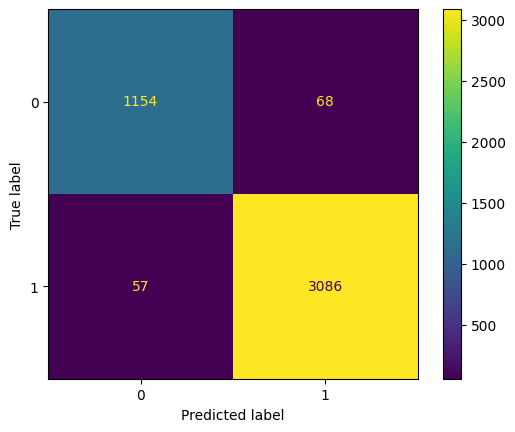

In [ ]:
bilstm_ptb_adam_64 = BiLSTM(2)
[bilstm_ptb_adam_64_train_losses, bilstm_ptb_adam_64_test_losses, bilstm_ptb_adam_64_test_loader] = train_nn(bilstm_ptb_adam_64, X_ptb_train, y_ptb_train, X_ptb_test, y_ptb_test, crossEntropy, "adam", 100, 64)
test_nn(bilstm_ptb_adam_64, crossEntropy, bilstm_ptb_adam_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.24642023369669913, Train Accuracy: 0.9059401080019637
Test Loss: 0.24672888312488794, Test Accuracy: 0.9059401080019637
------------------
Epoch 20/100
Train Loss: 0.15995311746373772, Train Accuracy: 0.9362788414334806
Test Loss: 0.15987650426104666, Test Accuracy: 0.9362788414334806
------------------
Epoch 30/100
Train Loss: 0.11098096431232989, Train Accuracy: 0.9585665193912617
Test Loss: 0.11108540277928114, Test Accuracy: 0.9585665193912617
------------------
Epoch 40/100
Train Loss: 0.0779275540728122, Train Accuracy: 0.9710358370152185
Test Loss: 0.07737325513735413, Test Accuracy: 0.9710358370152185
------------------
Epoch 50/100
Train Loss: 0.06249600246082991, Train Accuracy: 0.9775159548355424
Test Loss: 0.06228648945689201, Test Accuracy: 0.9775159548355424
------------------
Epoch 60/100
Train Loss: 0.035615400096867235, Train Accuracy: 0.9881197839960727
Test Loss: 0.03569470969960094, Test Accuracy: 0.9881197839960727
------------------
Epoc

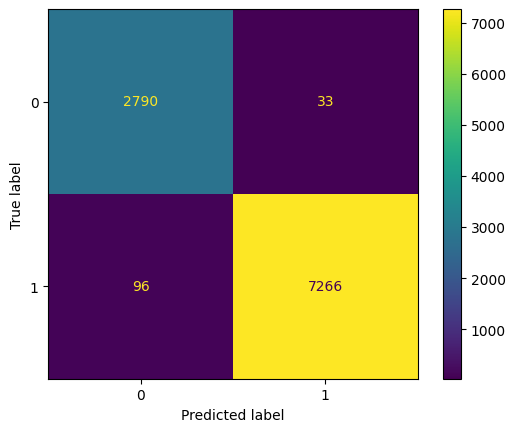

In [ ]:
bilstm_ptb_adam_128 = BiLSTM(2)
[bilstm_ptb_adam_128_train_losses, bilstm_ptb_adam_128_test_losses, bilstm_ptb_adam_128_test_loader] = train_nn(bilstm_ptb_adam_128, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "adam", 100, 128)
test_nn(bilstm_ptb_adam_128, crossEntropy, bilstm_ptb_adam_128_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5913954135030508, Train Accuracy: 0.7228276877761414
Test Loss: 0.5903273271396756, Test Accuracy: 0.7228276877761414
------------------
Epoch 20/100
Train Loss: 0.5890877587720752, Train Accuracy: 0.7228276877761414
Test Loss: 0.5890868011862039, Test Accuracy: 0.7228276877761414
------------------
Epoch 30/100
Train Loss: 0.3768714305013418, Train Accuracy: 0.8141384388807069
Test Loss: 0.3779847651720047, Test Accuracy: 0.8141384388807069
------------------
Epoch 40/100
Train Loss: 0.33768691271543505, Train Accuracy: 0.8278841433480608
Test Loss: 0.33937684213742614, Test Accuracy: 0.8278841433480608
------------------
Epoch 50/100
Train Loss: 0.30516808619722724, Train Accuracy: 0.8469317623956799
Test Loss: 0.3050348650664091, Test Accuracy: 0.8469317623956799
------------------
Epoch 60/100
Train Loss: 0.29851601189002397, Train Accuracy: 0.8502700049091801
Test Loss: 0.29984526047483084, Test Accuracy: 0.8502700049091801
------------------
Epoch 70/10

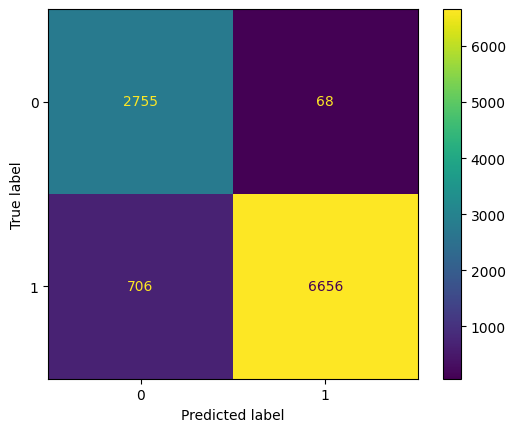

In [ ]:
bilstm_ptb_sgd_64 = BiLSTM(2)
[bilstm_ptb_sgd_64_train_losses, bilstm_ptb_sgd_64_test_losses, bilstm_ptb_sgd_64_test_loader] = train_nn(bilstm_ptb_sgd_64, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "sgd", 100, 64)
test_nn(bilstm_ptb_sgd_64, crossEntropy, bilstm_ptb_sgd_64_test_loader)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [186] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Epoch 10/100
Train Loss: 0.5903291165828705, Train Accuracy: 0.7228276877761414
Test Loss: 0.590187719464302, Test Accuracy: 0.7228276877761414
------------------
Epoch 20/100
Train Loss: 0.5901491142809391, Train Accuracy: 0.7228276877761414
Test Loss: 0.590597628429532, Test Accuracy: 0.7228276877761414
------------------
Epoch 30/100
Train Loss: 0.5888071395456791, Train Accuracy: 0.7228276877761414
Test Loss: 0.5888788975775242, Test Accuracy: 0.7228276877761414
------------------
Epoch 40/100
Train Loss: 0.3988189220428467, Train Accuracy: 0.7813451153657339
Test Loss: 0.3976510215550661, Test Accuracy: 0.7813451153657339
------------------
Epoch 50/100
Train Loss: 0.36918300576508045, Train Accuracy: 0.8106038291605302
Test Loss: 0.3698583010584116, Test Accuracy: 0.8106038291605302
------------------
Epoch 60/100
Train Loss: 0.3313505191355944, Train Accuracy: 0.8414334806087383
Test Loss: 0.3306671742349863, Test Accuracy: 0.8414334806087383
------------------
Epoch 70/100
Trai

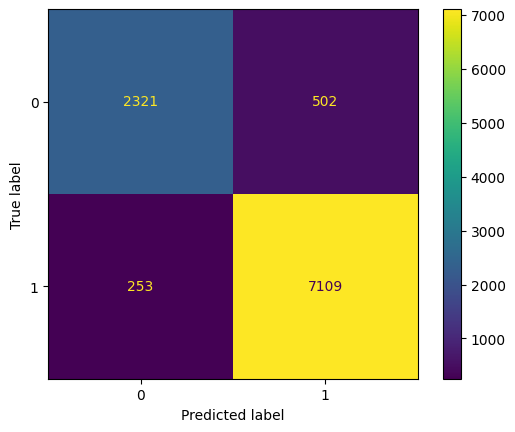

In [ ]:
bilstm_ptb_sgd_128 = BiLSTM(2)
[bilstm_ptb_sgd_128_train_losses, bilstm_ptb_sgd_128_test_losses, bilstm_ptb_sgd_128_test_loader] = train_nn(bilstm_ptb_sgd_128, X_ptb_train, y_ptb_train, X_ptb_train, y_ptb_train, crossEntropy, "sgd", 100, 128)
test_nn(bilstm_ptb_sgd_128, crossEntropy, bilstm_ptb_sgd_128_test_loader)

##### Plotting

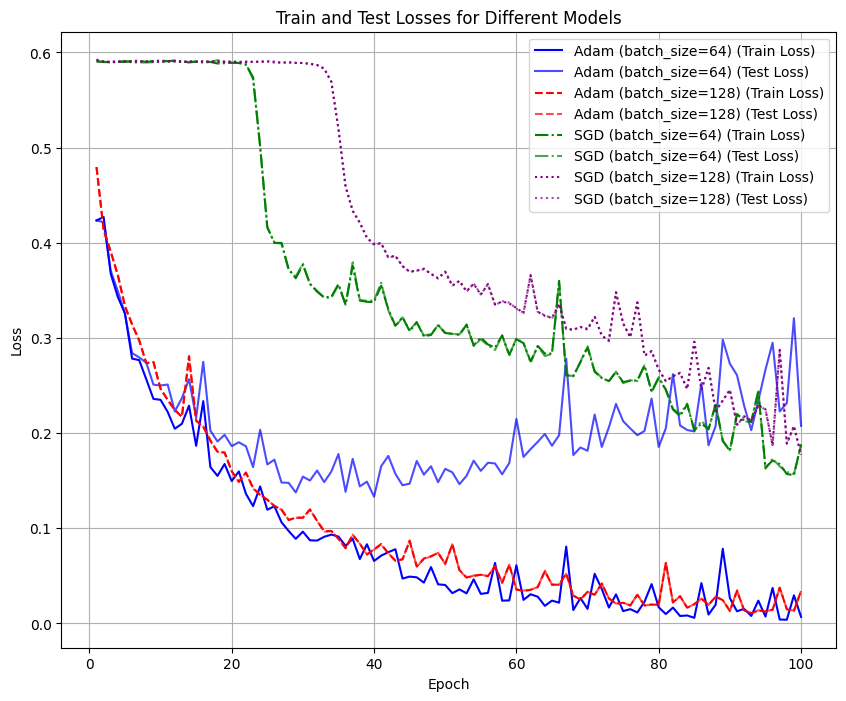

In [ ]:
bilstm_ptb_train_losses = [bilstm_ptb_adam_64_train_losses, bilstm_ptb_adam_128_train_losses, bilstm_ptb_sgd_64_train_losses, bilstm_ptb_sgd_128_train_losses]
bilstm_ptb_test_losses = [bilstm_ptb_adam_64_test_losses, bilstm_ptb_adam_128_test_losses, bilstm_ptb_sgd_64_test_losses, bilstm_ptb_sgd_128_test_losses]
plot_losses(100, bilstm_ptb_train_losses, bilstm_ptb_test_losses)